<a href="https://colab.research.google.com/github/EllieCoulliette0/EllieCoulliette0.github.io/blob/main/Notebook_Combined_Single_City_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Bird Biodiversity Pipeline — Single-City, Single-Config Notebook
## eBird → AVONET traits → environmental layers → effort-safe response variables

This notebook combines four previously separate notebooks (1: eBird pipeline,
2: AVONET trait join, 13: environmental layers + GIS assembly, 13b: effort
adjustment + single-variable analysis) into one continuous run. **Change the
city by editing exactly one cell** (Part 0, below) — every file path, output
name, and downstream reference is derived from it.

**What running this notebook top to bottom produces:**
1. Cleaned, filtered eBird checklist data with diversity metrics (was Notebook 1)
2. Community-weighted mean AVONET traits per checklist (was Notebook 2)
3. Five tract-level environmental layers (UHI, SVI, canopy, VIIRS, HOLC) plus
   plumage brightness, all merged into one checklist-level file (was Notebook 13)
4. Effort-adjusted diversity, a minimum-checklist floor, and a reusable
   single-variable analysis template, ready for a poster (was Notebook 13b)

**What's different from running the four notebooks separately:**
- One config cell instead of four (each notebook previously had its own,
  and they'd drifted out of sync with each other more than once).
- A handful of debugging/exploration cells from the original notebooks were
  cut (Drive folder listings, an ad-hoc AVONET name search) since they don't
  add anything once the paths are all correct by construction.
- Two silent bugs got fixed in the process: the AVONET file path had a
  hardcoded bypass that ignored the config variable entirely, and the eBird
  diversity/CWM output filenames were still hardcoded with "fulton" in them
  regardless of which city you're running.
- Internal "## Section N" numbering inside each part was left as in the
  original notebooks rather than renumbered end-to-end — the `## PART`
  headers below are what to navigate by.

**Prerequisites:**
- Request your eBird data first (see the box immediately below) — approval
  takes up to 7 days, so start this before anything else.
- AVONET.csv, the Hsu et al. UHI file, and (optionally) Delhey et al.'s
  `mmc2.xlsx` should sit in a shared `raw_data` folder (not per-city) —
  Part 0 assumes this layout.
- A CDC SVI CSV for your state, downloaded manually (see Part 3).
- A Google Cloud project with Earth Engine enabled (see Part 3) for the
  canopy and light-pollution layers.

---
## Section 0: How to Request eBird Data

> **Submit this on Day 1 of the project. Approval takes up to 7 days.**

### Step 1 — Create an eBird account
Go to [ebird.org](https://ebird.org) and click **Create account**.
Use your Agnes Scott email address and verify before proceeding.

### Step 2 — Go to the data request page
Navigate to [ebird.org/data/download](https://ebird.org/data/download).
Click **eBird Basic Dataset (EBD)**.

### Step 3 — Fill out the request form
Copy and paste this project description:

> *"I am an undergraduate researcher at Agnes Scott College studying urban bird
> biodiversity in relation to urban heat islands, tree canopy cover, and social
> vulnerability. This project is part of a summer research program supervised by
> Dr. Jennifer Kovacs. I will use the data to replicate and extend an analysis of
> bird community composition across urban neighborhoods, examining whether ecological
> and human heat vulnerability are coupled or decoupled across cities. Data will be
> used for a peer-reviewed publication and student research presentations."*

### Step 4 — Choose your filters

| Filter | Value |
|--------|-------|
| Location | **County level** (see eBird county codes below) |
| Date range | January 2024 – February 2026 (or extend to 2020 for longer time series) |

**eBird county codes** (format: `US-[STATE]-[FIPS]`):

| City | County | Code |
|------|--------|------|
| Chicago, IL | Cook County | `US-IL-031` |
| Baltimore, MD | Baltimore City | `US-MD-510` |
| Memphis, TN | Shelby County | `US-TN-157` |
| Houston, TX | Harris County | `US-TX-201` |
| Detroit, MI | Wayne County | `US-MI-163` |
| Charlotte, NC | Mecklenburg County | `US-NC-119` |
| Richmond, VA | Richmond City | `US-VA-760` |
| New Orleans, LA | Orleans Parish | `US-LA-071` |
| DeKalb County, GA (Atlanta extension) | DeKalb | `US-GA-089` |
| Cobb County, GA (Atlanta extension) | Cobb | `US-GA-067` |

To find any county FIPS code: [Census ANSI lookup](https://www.census.gov/library/reference/code-lists/ansi.html)

### Step 5–6 — Submit and download
After approval (2–7 days) you will receive a download link by email.
The file is a large tab-delimited `.txt`. Save it to your Drive in `ebird_data/`.

**While you wait:** complete Sections 2–6 below — all other data sources are immediately
available with no approval needed.

---
# PART 0: Master Configuration and Setup

**This is the only part you should need to edit for a new city.** Every file
path used anywhere below is derived from the variables in the next cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# MASTER CONFIGURATION -- the only cell you should need to edit per city
# ══════════════════════════════════════════════════════════════════════
CITY_NAME   = "Memphis"   # Human-readable name, used in labels/titles
CITY_CODE   = "memphis"   # Short lowercase code, used in filenames
STATE_FIPS  = "47"        # 2-digit state FIPS code
COUNTY_FIPS = "157"       # 3-digit county FIPS code
STATE_ABBR  = "TN"        # 2-letter state abbreviation

# Raw eBird export filename -- DOES need checking per city, since eBird
# names the file after your specific data request.
EBIRD_RAW_FILENAME = "ebd_US-TN-157_202401_202602_relJun-2026.txt"

# CDC SVI file -- download manually per state (see Part 3, Section 5) and
# name it here. State-level CSVs from svi.cdc.gov are typically named by
# state, e.g. "Illinois.csv".
SVI_STATE_FILENAME = "Tennessee.csv"

MIN_CHECKLISTS_PER_TRACT = 5   # floor below which a tract is excluded from single-variable analysis

# Earth Engine project ID -- this is NOT auto-derived. You must have already
# created a Google Cloud project with Earth Engine enabled under this exact
# ID (see Part 3, Section 7 for setup steps). The f-string below is just a
# suggested naming convention to keep it associated with this city/run.
PROJECT_ID = f'{CITY_CODE}2026-ebird'

# ---- Folder structure (derived -- shouldn't need to change) ------------
DRIVE_ROOT     = "/content/drive/MyDrive/MainFolderMemphis"
RAW_DIR        = f"{DRIVE_ROOT}/{CITY_NAME}/Raw_dataMemp/"     # city-specific raw inputs (eBird export, SVI)
OUTPUT_DIR     = f"{DRIVE_ROOT}/{CITY_NAME}/OutputMemp/"       # everything this notebook produces
SHARED_RAW_DIR = f"{DRIVE_ROOT}/{CITY_NAME}/Raw_dataMemp/"                 # files shared across ALL cities (AVONET, UHI, brightness)

# ---- Input files ---------------------------------------------------------
DATA_FILE               = RAW_DIR + EBIRD_RAW_FILENAME
AVONET_FILE             = SHARED_RAW_DIR + "AVONET.csv"
UHI_FILE                = SHARED_RAW_DIR + "Census_UHI_US_Urbanized_recalculated.csv"
BRIGHTNESS_SOURCE_FILE  = SHARED_RAW_DIR + "mmc2.xlsx"          # Delhey et al. (2021), optional
SVI_LOCAL_FILE          = RAW_DIR + SVI_STATE_FILENAME

# ---- Files this notebook produces (all derived from CITY_CODE) ----------
EBIRD_DIVERSITY_FILE = OUTPUT_DIR + f"data_{CITY_CODE}_Diversity_indices_only.csv"
EBIRD_SPECIES_FILE   = OUTPUT_DIR + f"data_{CITY_CODE}_species_level.csv"
Q_MATRIX_FILE        = OUTPUT_DIR + f"Q_matrix_{CITY_CODE}.csv"
CWM_TRAITS_FILE      = OUTPUT_DIR + f"heat_traits_cwm_{CITY_CODE}.csv"
OUTPUT_FILE          = OUTPUT_DIR + f"heat_traits_{CITY_CODE}.csv"           # final assembled checklist-level dataset
TRACTS_OUTPUT_PATH   = OUTPUT_DIR + f"{CITY_CODE}_census_tracts.geojson"
SINGLE_VAR_OUTPUT_FILE = OUTPUT_DIR + f"single_variable_tract_data_{CITY_CODE}.csv"

# ---- Aliases: several of the original notebooks used their own local
# names for these same files. Defining both here means the pasted code
# below (Parts 1-4) works unmodified. ----------------------------------
SPECIES_FILE   = EBIRD_SPECIES_FILE     # Part 2's (was Notebook 2) name for this file
CWM_FILE       = CWM_TRAITS_FILE        # Part 2's name for this file
CHECKLIST_FILE = OUTPUT_FILE            # Part 4's (was Notebook 13b) name for this file
TRACTS_FILE    = TRACTS_OUTPUT_PATH     # Part 4's name for this file

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)

COUNTY_GEOID = f"{STATE_FIPS}{COUNTY_FIPS}"
print(f"City          : {CITY_NAME}")
print(f"County GEOID  : {COUNTY_GEOID}")
print(f"Raw data dir  : {RAW_DIR}")
print(f"Shared raw dir: {SHARED_RAW_DIR}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Final output  : {OUTPUT_FILE}")


City          : Memphis
County GEOID  : 47157
Raw data dir  : /content/drive/MyDrive/MainFolderMemphis/Memphis/Raw_dataMemp/
Shared raw dir: /content/drive/MyDrive/MainFolderMemphis/Memphis/Raw_dataMemp/
Output dir    : /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/
Final output  : /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/heat_traits_memphis.csv


In [ ]:
# ── Master package installs and imports (covers Parts 1-4; Earth Engine
# is installed separately in Part 3, Section 7, since it needs its own
# auth flow) ──────────────────────────────────────────────────────────
# Colab: uncomment the line below if you get an import error
!pip install geopandas requests --quiet

import os
import re
import json
import zipfile
import tempfile
from io import BytesIO

import numpy as np
import pandas as pd
import geopandas as gpd
import requests

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from scipy.stats import entropy
from scipy import stats

from shapely.geometry import Point, mapping

import warnings
warnings.filterwarnings('ignore')

print("All packages loaded successfully.")


All packages loaded successfully.


In [ ]:
# ============================================================
# IMPORT -- run this instead of Parts 1-4 to pick up where the
# export left off. Requires Part 0 (master config) to have run
# first, so CITY_CODE/OUTPUT_DIR are defined.
# ============================================================
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

GDF_OUTPUT_PATH = OUTPUT_DIR + f'{CITY_CODE}_full_model_data.geojson'
gdf = gpd.read_file(GDF_OUTPUT_PATH)

print(f"Loaded {len(gdf)} tracts from {GDF_OUTPUT_PATH}")
print("Columns available:", list(gdf.columns))




Loaded 122 tracts from /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/memphis_full_model_data.geojson
Columns available: ['GEOID', 'diversity_effort_adj', 'diversity_raw', 'n_checklists', 'mean_mass', 'mean_brightness', 'heat_intensity', 'canopy_pct', 'total_vuln', 'light_radiance', 'holc_grade_dominant', 'geometry']


---
# PART 1: eBird Data Pipeline

Loads the raw eBird checklist export, applies quality filters, calculates
Shannon diversity and species richness per checklist, removes rare vagrants
with a 5% detection-frequency threshold, adds calendar variables, and
exports the two files Part 2 and Part 3 need.

**Uses from Part 0:** `DATA_FILE`, `OUTPUT_DIR`, `EBIRD_DIVERSITY_FILE`, `EBIRD_SPECIES_FILE`

## Section 2: Load and Inspect the Raw eBird Data

The eBird Basic Dataset is a tab-delimited text file. Each row is one species observation within one checklist. A single observer walking a park for 30 minutes might record 25 species, producing 25 rows in this file — all sharing the same `SAMPLING.EVENT.IDENTIFIER`.

In [ ]:
import os

print(f"Attempting to read file from: {DATA_FILE}")

if not os.path.exists(DATA_FILE):
    print(f"Error: File not found at the specified path: {DATA_FILE}")
    # You might want to re-check your Google Drive mount or the file's location.
    # For now, we will exit to prevent further errors.
else:
    print(f"File found at {DATA_FILE}. Proceeding to read with pandas.")
    # low_memory=False suppresses dtype inference warnings on large mixed-type files
    raw = pd.read_csv(DATA_FILE, sep='\t', low_memory=False)

    print(f'Loaded {len(raw):,} rows across {raw.shape[1]} columns')
    print('Available columns:', raw.columns.tolist())

    # Corrected column names based on user feedback and common eBird export formats
    print(f'Unique checklists: {raw["SAMPLING EVENT IDENTIFIER"].nunique():,}')
    print(f'Unique hotspots:   {raw["LOCALITY ID"].nunique():,}')
    print(f'Date range:        {raw["OBSERVATION DATE"].min()} to {raw["OBSERVATION DATE"].max()}')

Attempting to read file from: /content/drive/MyDrive/MainFolderMemphis/Memphis/Raw_dataMemp/ebd_US-TN-157_202401_202602_relJun-2026.txt
File found at /content/drive/MyDrive/MainFolderMemphis/Memphis/Raw_dataMemp/ebd_US-TN-157_202401_202602_relJun-2026.txt. Proceeding to read with pandas.
Loaded 497,645 rows across 53 columns
Available columns: ['GLOBAL UNIQUE IDENTIFIER', 'LAST EDITED DATE', 'TAXONOMIC ORDER', 'CATEGORY', 'TAXON CONCEPT ID', 'COMMON NAME', 'SCIENTIFIC NAME', 'SUBSPECIES COMMON NAME', 'SUBSPECIES SCIENTIFIC NAME', 'EXOTIC CODE', 'OBSERVATION COUNT', 'BREEDING CODE', 'BREEDING CATEGORY', 'BEHAVIOR CODE', 'AGE/SEX', 'COUNTRY', 'COUNTRY CODE', 'STATE', 'STATE CODE', 'COUNTY', 'COUNTY CODE', 'IBA CODE', 'BCR CODE', 'USFWS CODE', 'ATLAS BLOCK', 'LOCALITY', 'LOCALITY ID', 'LOCALITY TYPE', 'LATITUDE', 'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED', 'OBSERVER ID', 'OBSERVER ORCID ID', 'SAMPLING EVENT IDENTIFIER', 'OBSERVATION TYPE', 'PROTOCOL NAME', 'PROTOCOL CODE

In [ ]:
# Preview a few rows and the key columns we will use
key_cols = [
    'SAMPLING EVENT IDENTIFIER', 'LOCALITY ID', 'OBSERVATION DATE',
    'COMMON NAME', 'SCIENTIFIC NAME', 'OBSERVATION COUNT', 'CATEGORY',
    'ALL SPECIES REPORTED', 'PROTOCOL NAME', 'DURATION MINUTES',
    'EFFORT DISTANCE KM', 'GROUP IDENTIFIER'
]
raw[key_cols].head(8)

,SAMPLING EVENT IDENTIFIER,LOCALITY ID,OBSERVATION DATE,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,CATEGORY,ALL SPECIES REPORTED,PROTOCOL NAME,DURATION MINUTES,EFFORT DISTANCE KM,GROUP IDENTIFIER
0,S158567397,L12335509,2024-01-10,American Crow,Corvus brachyrhynchos,4,species,1,Stationary,33.0,NaN,NaN
1,S159308429,L13764719,2024-01-19,American Crow,Corvus brachyrhynchos,2,species,1,Stationary,11.0,NaN,G11554051
2,S159757994,L17806705,2024-01-25,American Crow,Corvus brachyrhynchos,4,species,1,Stationary,2.0,NaN,NaN
3,S158249662,L1803063,2024-01-06,American Crow,Corvus brachyrhynchos,3,species,0,Traveling,27.0,0.418,NaN
4,S158088641,L28637551,2024-01-04,American Crow,Corvus brachyrhynchos,2,species,0,Incidental,NaN,NaN,NaN
5,S157709808,L28122663,2024-01-01,American Crow,Corvus brachyrhynchos,2,species,1,Traveling,33.0,0.657,NaN
6,S159840244,L6662262,2024-01-26,American Crow,Corvus brachyrhynchos,3,species,1,Stationary,15.0,NaN,NaN
7,S159660383,L8406527,2024-01-23,American Crow,Corvus brachyrhynchos,2,species,1,Stationary,60.0,NaN,G11581872


In [ ]:
# Check the mix of record categories
# We will keep 'species' and 'issf' (identifiable subspecies forms);
# 'slash', 'hybrid', 'domestic', and 'spuh' are ambiguous and excluded
print('Record categories in the dataset:')
print(raw['CATEGORY'].value_counts())
print()
print('Observation protocols:')
print(raw['PROTOCOL NAME'].value_counts().head(10))

Record categories in the dataset:
CATEGORY
species     486870
issf          5319
domestic      3781
spuh          1049
slash          540
form            58
hybrid          28
Name: count, dtype: int64

Observation protocols:
PROTOCOL NAME
Traveling                      364547
Stationary                     119853
Incidental                      12669
Banding                           513
Historical                         60
Nocturnal Flight Call Count         2
Area                                1
Name: count, dtype: int64


## Section 3: Filter to High-Quality Checklists

Not every eBird checklist is suitable for community-level analysis. We apply four filters:

1. **Complete checklists only** — the observer reported every species they detected, not just
   target species. Incomplete checklists cannot tell us about species absence.

2. **Standard protocols** — Stationary, Traveling, and Area counts. Incidental observations
   (chance sightings without a defined effort) are excluded.

3. **No 'X' counts** — some records use 'X' instead of a number ("birds present but not
   counted"). Shannon diversity requires actual counts; we remove entire checklists with
   any 'X' record so we do not bias the calculation.

4. **Effort caps** — duration between 5 and 240 minutes; distance ≤ 10 km. Very short lists
   are unreliable; very long ones cover too much heterogeneous habitat.


In [ ]:
# ── STEP 3a: Count 'X' records per checklist ─────────────────────────────────
# Do this BEFORE filtering by category so we catch X counts in any record type.
# Checklists with any X will be removed in step 3d.

x_counts = (
    raw.groupby('SAMPLING EVENT IDENTIFIER')['OBSERVATION COUNT']
    .apply(lambda s: (s == 'X').sum())
    .reset_index(name='number_X')
)
print(f'Checklists with at least one X count: {(x_counts["number_X"] > 0).sum():,}')


Checklists with at least one X count: 938


In [ ]:
# ── STEP 3b: Extract sampling event metadata ──────────────────────────────────
# One row per checklist. These columns are the same for every species row within
# a checklist, so drop_duplicates() gives us one clean metadata row per checklist.

event_cols = [
    'SAMPLING EVENT IDENTIFIER', 'LOCALITY', 'LOCALITY ID',
    'OBSERVATION DATE', 'PROTOCOL NAME', 'ALL SPECIES REPORTED',
    'EFFORT DISTANCE KM', 'EFFORT AREA HA', 'DURATION MINUTES',
    'GROUP IDENTIFIER', 'LATITUDE', 'LONGITUDE'
]
event_meta = raw[event_cols].drop_duplicates()
print(f'Unique checklists in metadata: {len(event_meta):,}')

Unique checklists in metadata: 33,373


In [ ]:
# ── STEP 3c: Filter to species-level records and convert counts ───────────────
# Keep only 'species' and 'issf' (identifiable subspecies) records.
#
# Some subspecies (issf) may appear multiple times for the same species common name
# within a checklist (different subspecies forms counted separately). We sum counts
# so each species appears once per checklist — matching the R pipeline.
#
# pd.to_numeric with errors='coerce' silently converts 'X' to NaN.
# These checklists are removed below by the number_X == 0 filter.

species_records = raw[raw['CATEGORY'].isin(['species', 'issf'])].copy()

species_records['OBSERVATION COUNT'] = pd.to_numeric(
    species_records['OBSERVATION COUNT'], errors='coerce'
)

# Sum counts for the same species within a checklist
species_records = (
    species_records
    .groupby(
        ['SAMPLING EVENT IDENTIFIER', 'COMMON NAME', 'SCIENTIFIC NAME'],
        as_index=False
    )['OBSERVATION COUNT'].sum()
)

print(f'Species-level records: {len(species_records):,}')
print(f'Unique species/issf:   {species_records["COMMON NAME"].nunique():,}')

Species-level records: 492,024
Unique species/issf:   299


In [ ]:
# ── STEP 3d: Join metadata and apply quality filters ──────────────────────────

df = (
    species_records
    .merge(event_meta, on='SAMPLING EVENT IDENTIFIER', how='inner')
    .merge(x_counts,  on='SAMPLING EVENT IDENTIFIER', how='inner')
)

n_start = df['SAMPLING EVENT IDENTIFIER'].nunique()

# Filter 1: complete checklists only
df = df[df['ALL SPECIES REPORTED'] == 1]
print(f'After complete-checklist filter: {df["SAMPLING EVENT IDENTIFIER"].nunique():,} checklists')

# Filter 2: standard counting protocols
df = df[df['PROTOCOL NAME'].isin(['Stationary', 'Traveling', 'Area'])]
print(f'After protocol filter:           {df["SAMPLING EVENT IDENTIFIER"].nunique():,} checklists')

# Filter 3: no X counts
df = df[df['number_X'] == 0]
print(f'After X-count filter:            {df["SAMPLING EVENT IDENTIFIER"].nunique():,} checklists')

After complete-checklist filter: 27,656 checklists
After protocol filter:           27,637 checklists
After X-count filter:            27,013 checklists


In [ ]:
# ── STEP 3e: Apply effort caps ────────────────────────────────────────────────

df['DURATION MINUTES']  = pd.to_numeric(df['DURATION MINUTES'],  errors='coerce')
df['EFFORT DISTANCE KM'] = pd.to_numeric(df['EFFORT DISTANCE KM'], errors='coerce')

# Duration: 5–240 minutes (5 min minimum for a meaningful community sample;
# 240 min maximum to avoid multi-habitat transects)
df = df[
    (df['DURATION MINUTES'] >= 5) &
    (df['DURATION MINUTES'] <= 240)
]

# Distance: stationary counts have NaN distance — keep them.
# Only remove traveling counts that exceed 10 km.
df = df[
    df['EFFORT DISTANCE KM'].isna() |
    (df['EFFORT DISTANCE KM'] <= 10)
]

print(f'After effort caps: {df["SAMPLING EVENT IDENTIFIER"].nunique():,} checklists')
print(f'Species records remaining: {len(df):,}')

After effort caps: 24,378 checklists
Species records remaining: 421,728


## Section 4: Remove Duplicated Group Checklists

When a group of birders goes out together, each observer submits their own checklist in
eBird. These observations of the same birds at the same time and place get a shared
`GROUP.IDENTIFIER`. Counting all of them would artificially inflate our sample size
(pseudoreplication). We randomly keep **one checklist per group**.

Solo observers have an empty or NaN `GROUP.IDENTIFIER`. Group checklists start with 'G'.


In [ ]:
# Identify group vs solo checklists
is_group = df['GROUP IDENTIFIER'].str.startswith('G', na=False)

group_df = df[is_group].copy()
solo_df  = df[~is_group].copy()

n_groups = group_df['GROUP IDENTIFIER'].nunique()
n_group_checklists = group_df['SAMPLING EVENT IDENTIFIER'].nunique()
print(f'Group observations: {n_groups:,} groups containing {n_group_checklists:,} checklists')
print(f'Solo checklists:    {solo_df["SAMPLING EVENT IDENTIFIER"].nunique():,}')

# Randomly keep one checklist ID per group (random_state=42 for reproducibility)
keep_ids = (
    group_df[['GROUP IDENTIFIER', 'SAMPLING EVENT IDENTIFIER']]
    .drop_duplicates()
    .groupby('GROUP IDENTIFIER')
    .sample(n=1, random_state=42)
    ['SAMPLING EVENT IDENTIFIER']
    .tolist()
)

# Combine solo checklists with one-per-group checklists
df = pd.concat(
    [solo_df, group_df[group_df['SAMPLING EVENT IDENTIFIER'].isin(keep_ids)]],
    ignore_index=True
)

print(f'\nAfter deduplication: {df["SAMPLING EVENT IDENTIFIER"].nunique():,} checklists')

Group observations: 3,408 groups containing 8,132 checklists
Solo checklists:    16,246

After deduplication: 19,654 checklists


## Section 5: Calculate Shannon Diversity and Species Richness

We calculate three metrics per checklist:

- **Species Richness** — how many distinct species were recorded
- **Shannon H'** — a diversity index that accounts for both richness and evenness.
  A checklist with 10 species all equally abundant gets a higher H' than one where
  a single dominant species makes up 90% of the count.
  Formula: H' = −∑(pᵢ × ln pᵢ), where pᵢ is the proportion of count belonging to species i
- **Species Abundance** — total bird count

> **Note:** These values are calculated here as a preview. After the 5% detection
> frequency filter in Section 6, we recalculate them on the filtered species list.
> The recalculated values are what we save to the output files.


In [ ]:
def shannon_h(counts):
    """
    Shannon H' diversity index using natural log.
    Matches R's vegan::diversity(x, index='shannon').
    scipy.stats.entropy uses natural log by default and treats zeros correctly.
    """
    counts = counts.dropna()
    counts = counts[counts > 0]
    if len(counts) == 0:
        return np.nan
    return float(entropy(counts.values))


# Calculate per-checklist metrics (pre-5%-filter preview)
pre_metrics = (
    df.groupby('SAMPLING EVENT IDENTIFIER')
    .apply(lambda g: pd.Series({
        'Species_Richness_pre':  g['COMMON NAME'].nunique(),
        'Species_Diversity_pre': shannon_h(g['OBSERVATION COUNT']),
        'Species_Abundance':     g['OBSERVATION COUNT'].sum()
    }))
    .reset_index()
)

print('Pre-filter summary statistics:')
print(pre_metrics[['Species_Richness_pre', 'Species_Diversity_pre', 'Species_Abundance']].describe().round(2))

Pre-filter summary statistics:
       Species_Richness_pre  Species_Diversity_pre  Species_Abundance
count              19654.00               19654.00           19654.00
mean                  16.77                   2.09             132.22
std                   11.50                   0.72             451.40
min                    1.00                   0.00               1.00
25%                    9.00                   1.65              21.00
50%                   14.00                   2.15              46.00
75%                   22.00                   2.59             108.00
max                  108.00                   4.21           15349.00


## Section 6: Apply 5% Detection Frequency Filter

A checklist from a park near a lake might occasionally include a Herring Gull that
wandered in — a vagrant that is not part of that park's regular bird community. Including
such rare visitors would inflate apparent species richness and distort community-level
trait analyses.

The fix: for each hotspot (locality), keep only species detected on **≥5% of checklists
at that location**. A species common countywide but rare at a specific hotspot is removed
at that hotspot only — the filter operates per-locality, not globally.

> **Important:** After filtering, we recalculate Species_Richness and Species_Diversity.
> Removing species from some checklists changes those values. Always recalculate after
> any species-level filter.


In [ ]:
# Step 1: Total number of unique checklists per hotspot
total_per_locality = (
    df.groupby('LOCALITY ID')['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .reset_index(name='total_checklists')
)

# Step 2: Number of checklists each species was detected on, per hotspot
species_freq = (
    df.groupby(['LOCALITY ID', 'COMMON NAME'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .reset_index(name='species_count')
)

# Step 3: Calculate percentage and apply threshold
species_freq = species_freq.merge(total_per_locality, on='LOCALITY ID')
species_freq['pct_checklists'] = (
    species_freq['species_count'] / species_freq['total_checklists'] * 100
)

keep_locality_species = species_freq[
    species_freq['pct_checklists'] >= 5.0
][['LOCALITY ID', 'COMMON NAME']]

# Step 4: Filter the species-level data
df_95 = df.merge(keep_locality_species, on=['LOCALITY ID', 'COMMON NAME'], how='inner')

n_before = df['COMMON NAME'].nunique()
n_after  = df_95['COMMON NAME'].nunique()
print(f'Unique species before 5% filter: {n_before}')
print(f'Unique species after 5% filter:  {n_after}  ({n_before - n_after} removed as rare vagrants)')
print(f'Species records after filter:    {len(df_95):,}')

Unique species before 5% filter: 295
Unique species after 5% filter:  255  (40 removed as rare vagrants)
Species records after filter:    312,850


In [ ]:
# ── Recalculate diversity on the filtered species list ────────────────────────
# IMPORTANT: These are the values that go into the output files.
# Do NOT use the pre-filter values from Section 5.

final_metrics = (
    df_95.groupby('SAMPLING EVENT IDENTIFIER')
    .apply(lambda g: pd.Series({
        'Species_Richness':  g['COMMON NAME'].nunique(),
        'Species_Diversity': shannon_h(g['OBSERVATION COUNT'])
    }))
    .reset_index()
)

print('Post-filter summary statistics:')
print(final_metrics[['Species_Richness', 'Species_Diversity']].describe().round(3))

Post-filter summary statistics:
       Species_Richness  Species_Diversity
count         19621.000          19621.000
mean             15.945              2.062
std              10.665              0.712
min               1.000              0.000
25%               8.000              1.621
50%              14.000              2.120
75%              21.000              2.562
max              89.000              4.044


## Section 7: Add Temporal Variables

Downstream models need temporal context — bird communities differ dramatically between
winter (resident species only) and spring migration (hundreds of species passing through).
We add:

- `month` — calendar month (1–12)
- `day_of_year` — day number within the year (1–366); useful for smooth seasonal curves
- `YEAR` — calendar year
- `season` — W (Winter: Dec–Feb), Sp (Spring: Mar–May), Su (Summer: Jun–Aug), F (Fall: Sep–Nov)


In [ ]:
df_95 = df_95.copy()  # avoid pandas SettingWithCopyWarning

df_95['OBSERVATION DATE'] = pd.to_datetime(df_95['OBSERVATION DATE'])
df_95['month']       = df_95['OBSERVATION DATE'].dt.month
df_95['day_of_year'] = df_95['OBSERVATION DATE'].dt.dayofyear
df_95['YEAR']        = df_95['OBSERVATION DATE'].dt.year

# Meteorological season assignments — matches the R pipeline
season_map = {
     1: 'W',  2: 'W',
     3: 'Sp', 4: 'Sp',  5: 'Sp',
     6: 'Su', 7: 'Su',  8: 'Su',
     9: 'F', 10: 'F',  11: 'F',
    12: 'W'
}
df_95['season'] = df_95['month'].map(season_map)

print('Checklists per season:')
season_counts = (
    df_95.drop_duplicates('SAMPLING EVENT IDENTIFIER')['season']
    .value_counts()
    .reindex(['W', 'Sp', 'Su', 'F'])
)
for s, n in season_counts.items():
    label = {'W': 'Winter', 'Sp': 'Spring', 'Su': 'Summer', 'F': 'Fall'}[s]
    print(f'  {label:6s} ({s}): {n:,}')

Checklists per season:
  Winter (W): 6,581
  Spring (Sp): 5,798
  Summer (Su): 3,334
  Fall   (F): 3,908


## Section 8: Export Output Files

We export two CSV files:

1. **`EBIRD_DIVERSITY_FILE`** — one row per checklist with diversity metrics. Feeds into Part 3's spatial join.
2. **`EBIRD_SPECIES_FILE`** — one row per species × checklist. Feeds into Part 2's AVONET trait join.

In [ ]:
# ── Export 1: Diversity indices — one row per checklist ─────────────

# NOTE: effort fields (duration, distance) are added here so downstream
# notebooks can control for search effort. Previously these were used only
# to FILTER checklists in Section 3e and then silently dropped, which meant
# no notebook after this one could ever adjust for effort -- a raw scatter
# of any environmental variable vs. diversity/richness downstream would be
# partly just "which tracts got the longest checklists."
checklist_meta = (
    df_95[
        ['SAMPLING EVENT IDENTIFIER', 'LOCALITY ID', 'LATITUDE', 'LONGITUDE',
         'OBSERVATION DATE', 'month', 'day_of_year', 'YEAR', 'season',
         'DURATION MINUTES', 'EFFORT DISTANCE KM', 'PROTOCOL NAME']
    ]
    .drop_duplicates('SAMPLING EVENT IDENTIFIER')
)

diversity_df = checklist_meta.merge(final_metrics, on='SAMPLING EVENT IDENTIFIER', how='left')

# Ensure column order matches the original R output, with effort fields appended
diversity_cols = [
    'SAMPLING EVENT IDENTIFIER', 'LOCALITY ID', 'LATITUDE', 'LONGITUDE',
    'OBSERVATION DATE', 'month', 'day_of_year', 'YEAR', 'season',
    'Species_Diversity', 'Species_Richness',
    'DURATION MINUTES', 'EFFORT DISTANCE KM', 'PROTOCOL NAME'
]
diversity_df = diversity_df[diversity_cols]

# Format date as YYYY-MM-DD string (not datetime)
diversity_df['OBSERVATION DATE'] = diversity_df['OBSERVATION DATE'].dt.strftime('%Y-%m-%d')

# NOTE: was hardcoded to 'data_fulton_co_Diversity_indices_only.csv'
# regardless of city -- now uses the master config's derived filename.
out_path_1 = EBIRD_DIVERSITY_FILE

diversity_df.to_csv(out_path_1, index=False)
print(f'Exported: {out_path_1}')
print(f'  Rows: {len(diversity_df):,}  |  Columns: {diversity_df.shape[1]}')
diversity_df.head(3)


Exported: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/data_memphis_Diversity_indices_only.csv
  Rows: 19,621  |  Columns: 14


,SAMPLING EVENT IDENTIFIER,LOCALITY ID,LATITUDE,LONGITUDE,OBSERVATION DATE,month,day_of_year,YEAR,season,Species_Diversity,Species_Richness,DURATION MINUTES,EFFORT DISTANCE KM,PROTOCOL NAME
0,S157688618,L16565422,35.142418,-89.848840,2024-01-01,1,1,2024,W,1.982832,11.0,54.0,3.247,Traveling
1,S157692492,L25718838,35.256405,-89.857175,2024-01-01,1,1,2024,W,2.846324,21.0,12.0,NaN,Stationary
2,S157692951,L25718838,35.256405,-89.857175,2024-01-01,1,1,2024,W,3.091042,22.0,15.0,NaN,Stationary


In [ ]:
# ── Export 2: Species-level data — one row per species × checklist ────────────
# This file is needed by Notebook 2 (AVONET trait join) to build the
# community-weighted mean trait values per checklist.

species_export_cols = [
    'SAMPLING EVENT IDENTIFIER', 'LOCALITY ID', 'LATITUDE', 'LONGITUDE',
    'OBSERVATION DATE', 'OBSERVATION COUNT', 'COMMON NAME', 'SCIENTIFIC NAME',
    'month', 'day_of_year', 'YEAR', 'season'
]
species_df = df_95[species_export_cols].copy()
species_df['OBSERVATION DATE'] = species_df['OBSERVATION DATE'].dt.strftime('%Y-%m-%d')

out_path_2 = EBIRD_SPECIES_FILE  # was hardcoded 'data_fulton_species_level.csv'
species_df.to_csv(out_path_2, index=False)
print(f'Exported: {out_path_2}')
print(f'  Rows: {len(species_df):,}  |  Columns: {species_df.shape[1]}')
print(f'  Unique checklists: {species_df["SAMPLING EVENT IDENTIFIER"].nunique():,}')
print(f'  Unique species:    {species_df["COMMON NAME"].nunique():,}')
species_df.head(3)

Exported: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/data_memphis_species_level.csv
  Rows: 312,850  |  Columns: 12
  Unique checklists: 19,621
  Unique species:    255


,SAMPLING EVENT IDENTIFIER,LOCALITY ID,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVATION COUNT,COMMON NAME,SCIENTIFIC NAME,month,day_of_year,YEAR,season
0,S157688618,L16565422,35.142418,-89.84884,2024-01-01,1.0,American Crow,Corvus brachyrhynchos,1,1,2024,W
1,S157688618,L16565422,35.142418,-89.84884,2024-01-01,1.0,Carolina Wren,Thryothorus ludovicianus,1,1,2024,W
2,S157688618,L16565422,35.142418,-89.84884,2024-01-01,1.0,Cooper's Hawk,Astur cooperii,1,1,2024,W


In [ ]:
# ── Summary report ────────────────────────────────────────────────────────────
print('=' * 50)
print('PIPELINE SUMMARY')
print('=' * 50)
print(f'Raw records loaded:              {len(raw):>10,}')
print(f'Checklists after all filters:    {diversity_df["SAMPLING EVENT IDENTIFIER"].nunique():>10,}')
print(f'Unique hotspots:                 {diversity_df["LOCALITY ID"].nunique():>10,}')
print(f'Unique species (post 5% filter): {species_df["COMMON NAME"].nunique():>10,}')
print(f'Median species richness (H\'): {diversity_df["Species_Richness"].median():>9.0f}')
print(f'Median Shannon H\':              {diversity_df["Species_Diversity"].median():>10.3f}')
print('=' * 50)

PIPELINE SUMMARY
Raw records loaded:                 497,645
Checklists after all filters:        19,621
Unique hotspots:                      1,440
Unique species (post 5% filter):        255
Median species richness (H'):        14
Median Shannon H':                   2.120


## Section 9: Exploratory Plots

Quick visualisations to sanity-check the output before moving to Notebook 2.


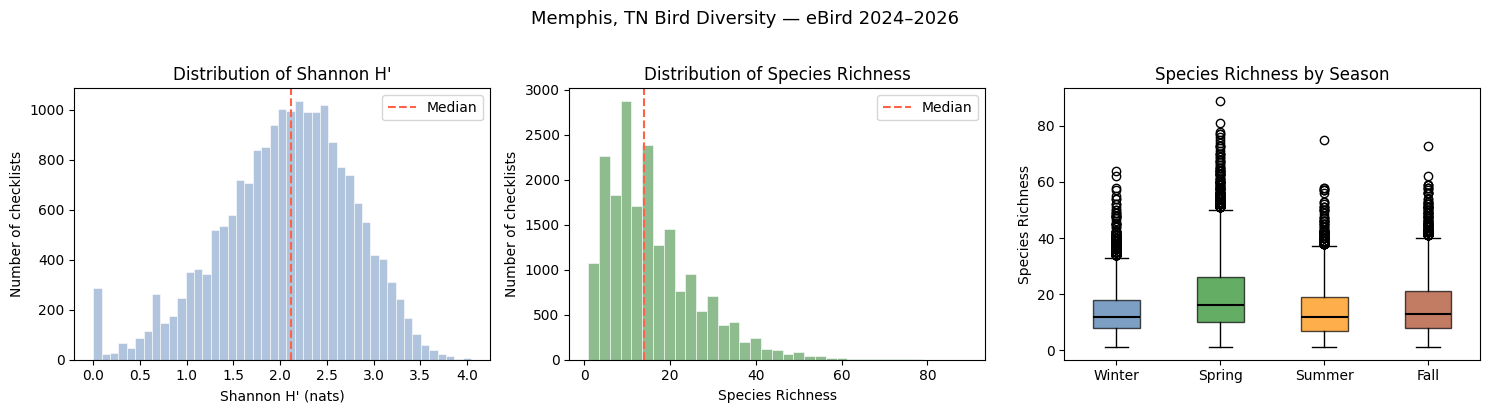

Plot saved to /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/fig0_pipeline_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Memphis, TN Bird Diversity — eBird 2024–2026', fontsize=13, y=1.02)

# ── Plot 1: Distribution of Shannon H' ───────────────────────────────────────
axes[0].hist(
    diversity_df['Species_Diversity'].dropna(),
    bins=45, color='lightsteelblue', edgecolor='white', linewidth=0.4
)
axes[0].axvline(
    diversity_df['Species_Diversity'].median(),
    color='tomato', linestyle='--', linewidth=1.5, label='Median'
)
axes[0].set_xlabel("Shannon H' (nats)")
axes[0].set_ylabel('Number of checklists')
axes[0].set_title("Distribution of Shannon H'")
axes[0].legend()

# ── Plot 2: Distribution of Species Richness ─────────────────────────────────
axes[1].hist(
    diversity_df['Species_Richness'].dropna(),
    bins=35, color='darkseagreen', edgecolor='white', linewidth=0.4
)
axes[1].axvline(
    diversity_df['Species_Richness'].median(),
    color='tomato', linestyle='--', linewidth=1.5, label='Median'
)
axes[1].set_xlabel('Species Richness')
axes[1].set_ylabel('Number of checklists')
axes[1].set_title('Distribution of Species Richness')
axes[1].legend()

# ── Plot 3: Species Richness by Season ───────────────────────────────────────
season_order  = ['W', 'Sp', 'Su', 'F']
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']
season_colors = ['#4477AA', '#228B22', '#FF8C00', '#AA4422']

season_data = [
    diversity_df[diversity_df['season'] == s]['Species_Richness'].dropna().values
    for s in season_order
]
bp = axes[2].boxplot(
    season_data, labels=season_labels, patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5)
)
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('Species Richness')
axes[2].set_title('Species Richness by Season')

plt.tight_layout()
plot_path = OUTPUT_DIR + 'fig0_pipeline_overview.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')


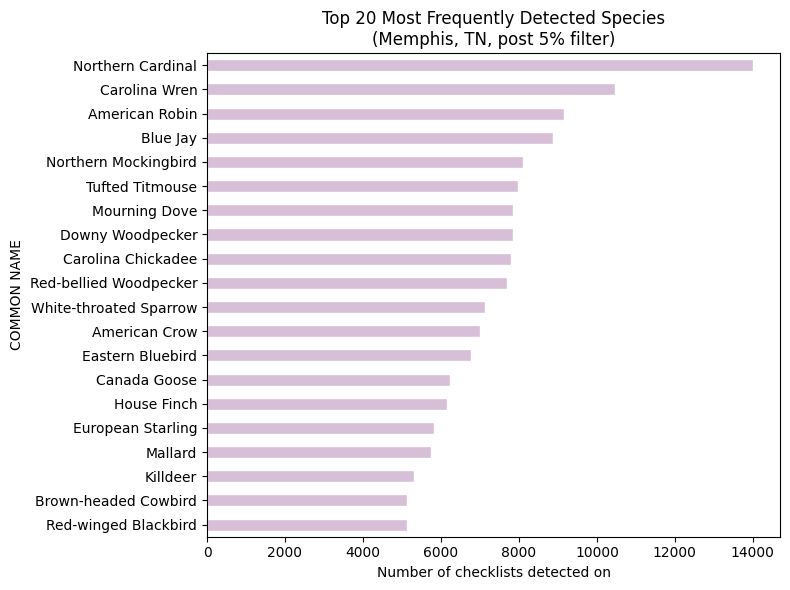

In [ ]:
# ── Bonus: Top 20 most frequently detected species countywide ─────────────────
top_species = (
    df_95.groupby('COMMON NAME')['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
top_species.plot(kind='barh', ax=ax, color='thistle', edgecolor='white')
ax.set_xlabel('Number of checklists detected on')
ax.set_title('Top 20 Most Frequently Detected Species\n(Memphis, TN, post 5% filter)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig0b_top_species.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 2: AVONET Trait Join

Joins morphological trait data from AVONET (Tobias et al. 2022) to the bird
species detected, handles taxonomy mismatches between eBird and AVONET, and
calculates community-weighted mean (CWM) traits per checklist — the body
mass response variable used in Part 4 comes from here.

**What CWM means:** for each checklist, the abundance-weighted average trait
value across all species detected. A checklist dominated by large generalists
(crows, starlings) will have a higher CWM body mass than one full of small
insectivores.

**Uses from Part 0:** `SPECIES_FILE`, `AVONET_FILE`, `Q_MATRIX_FILE`, `CWM_FILE`

**AVONET source:** Tobias et al. (2022) *Nature Ecology & Evolution* 6:540–552.
Download at https://figshare.com/s/b990722d72a26b5bfead (sheet `AVONET1_BirdLife`).

## Section 2: Load the Species List from Notebook 1

We load the species-level data produced by the eBird pipeline. Each row is one species
detected on one checklist. We need the unique set of species names for the trait join,
and the full dataset (with observation counts) for calculating CWM traits.


In [ ]:
species_df = pd.read_csv(SPECIES_FILE)

print(f'Species-level records loaded: {len(species_df):,}')
print(f'Unique checklists:            {species_df["SAMPLING EVENT IDENTIFIER"].nunique():,}')
print(f'Unique species:               {species_df["COMMON NAME"].nunique():,}')
print()
species_df.head(3)

Species-level records loaded: 312,850
Unique checklists:            19,621
Unique species:               255



,SAMPLING EVENT IDENTIFIER,LOCALITY ID,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVATION COUNT,COMMON NAME,SCIENTIFIC NAME,month,day_of_year,YEAR,season
0,S157688618,L16565422,35.142418,-89.84884,2024-01-01,1.0,American Crow,Corvus brachyrhynchos,1,1,2024,W
1,S157688618,L16565422,35.142418,-89.84884,2024-01-01,1.0,Carolina Wren,Thryothorus ludovicianus,1,1,2024,W
2,S157688618,L16565422,35.142418,-89.84884,2024-01-01,1.0,Cooper's Hawk,Astur cooperii,1,1,2024,W


In [ ]:
# Build the unique species list with both eBird names
ebird_species = (
    species_df[['COMMON NAME', 'SCIENTIFIC NAME']]
    .drop_duplicates()
    .sort_values('COMMON NAME')
    .reset_index(drop=True)
)
print(f'Unique species in dataset: {len(ebird_species)}')
ebird_species.head(10)

Unique species in dataset: 255


,COMMON NAME,SCIENTIFIC NAME
0,Acadian Flycatcher,Empidonax virescens
1,Alder Flycatcher,Empidonax alnorum
2,American Avocet,Recurvirostra americana
3,American Barn Owl,Tyto furcata
4,American Bittern,Botaurus lentiginosus
5,American Coot,Fulica americana
6,American Crow,Corvus brachyrhynchos
7,American Golden-Plover,Pluvialis dominica
8,American Goldfinch,Spinus tristis
9,American Herring Gull,Larus smithsonianus


## Section 3: Load AVONET Trait Data

AVONET contains morphological measurements and ecological classifications for all
~11,000 bird species. We extract the columns relevant to urban ecology:

**Continuous morphological traits** (used as community-weighted means):
- `Beak.Length_Culmen`, `Beak.Length_Nares`, `Beak.Width`, `Beak.Depth` — beak shape
- `Tarsus.Length` — leg length (relates to foraging stratum)
- `Wing.Length`, `Kipps.Distance`, `Hand-Wing.Index` — wing shape (relates to flight style)
- `Tail.Length` — tail length
- `Mass` — body mass in grams

**Categorical ecological traits** (used as community mode per checklist):
- `Habitat` — primary habitat type
- `Habitat.Density` — habitat structure preference (1=dense, 2=medium, 3=open)
- `Migration` — 1=resident, 2=partial migrant, 3=full migrant
- `Trophic.Niche` — feeding guild (Invertivore, Granivore, Omnivore, etc.)
- `Primary.Lifestyle` — foraging stratum (Insessorial, Terrestrial, Aerial, etc.)


In [ ]:
# Columns to extract from AVONET
CONTINUOUS_TRAITS = [
    'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth',
    'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1',
    'Hand-Wing.Index', 'Tail.Length', 'Mass'
]

CATEGORICAL_TRAITS = [
    'Habitat', 'Habitat.Density', 'Migration', 'Trophic.Level',
    'Trophic.Niche', 'Primary.Lifestyle'
]

AVONET_COLS = ['Species2'] + CONTINUOUS_TRAITS + CATEGORICAL_TRAITS

# Load AVONET — Option A: pre-extracted CSV
if AVONET_FILE.endswith('.csv'):
    # NOTE: this used to hardcode a literal path here, ignoring AVONET_FILE
    # entirely -- meant the config variable had no effect. Fixed to actually
    # use it, now pointed at the shared (not per-city) raw_data folder.
    avonet = pd.read_csv(AVONET_FILE, usecols=AVONET_COLS)

# Load AVONET — Option B: original Excel file
else:
    avonet = pd.read_excel(
        AVONET_FILE, sheet_name=AVONET_SHEET, usecols=AVONET_COLS, engine='openpyxl'
    )

print(f'AVONET species loaded: {len(avonet):,}')
print(f'Columns: {list(avonet.columns)}')
avonet.head(3)


AVONET species loaded: 10,661
Columns: ['Species2', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Hand-Wing.Index', 'Tail.Length', 'Mass', 'Habitat', 'Habitat.Density', 'Migration', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle']


,Species2,Beak.Length_Culmen,Beak.Length_Nares,Beak.Width,Beak.Depth,Tarsus.Length,Wing.Length,Kipps.Distance,Secondary1,Hand-Wing.Index,Tail.Length,Mass,Habitat,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle
0,Accipiter albogularis,27.7,17.8,10.6,14.7,62.0,235.2,81.8,159.5,33.9,169.0,248.8,Forest,1,2.0,Carnivore,Vertivore,Insessorial
1,Accipiter badius,20.6,12.1,8.8,11.6,43.0,186.7,62.5,127.4,32.9,140.6,131.2,Shrubland,2,3.0,Carnivore,Vertivore,Insessorial
2,Accipiter bicolor,25.0,13.7,8.6,12.7,58.1,229.6,56.6,174.8,24.6,186.3,287.5,Woodland,2,2.0,Carnivore,Vertivore,Generalist


## Section 4: Handle Taxonomy Mismatches

eBird uses the **Clements checklist** taxonomy; AVONET uses the **BirdLife International**
taxonomy. These sometimes treat the same bird as one species or two, or use different
scientific names for the same species. Most names match directly, but a small number of
mismatches require a manual crosswalk.

The crosswalk dictionary below maps eBird scientific names (left) to AVONET scientific
names (right) for known southeastern US problem taxa. Add entries if your coverage report
in Section 8 shows additional unmatched species.


In [ ]:
# Manual taxonomy crosswalk: eBird (Clements) → AVONET (BirdLife)
# Keys are SCIENTIFIC.NAME values from the eBird data;
# values are the matching Species2 entry in AVONET.
#
# Common mismatches for southeastern US birds:
#   - Yellow-rumped Warbler: Clements splits into coronata/auduboni;
#     BirdLife lumps as Setophaga coronata (same name, usually matches)
#   - Palm Warbler: eBird records two ssps under Setophaga palmarum
#   - Double-crested Cormorant: Nannopterum auritum (Clements) vs
#     Phalacrocorax auritus (older BirdLife name)
#   - Eurasian Collared-Dove: Streptopelia decaocto matches in both

TAXONOMY_CROSSWALK = {
    # eBird scientific name       : AVONET scientific name (corrected/added based on unmatched list)
    'Nannopterum auritum'         : 'Phalacrocorax auritus',    # Double-crested Cormorant (eBird name not in AVONET, maps to Phalacrocorax auritus, which is also not in this AVONET subset)
    'Mareca strepera'             : 'Mareca strepera',          # Gadwall (now maps to itself, as Mareca strepera is in AVONET)
    'Spatula discors'             : 'Spatula discors',          # Blue-winged Teal - corrected from 'Anas discors' (mapping kept)
    'Spatula clypeata'            : 'Spatula clypeata',         # Northern Shoveler - corrected from 'Anas clypeata' (mapping kept)
    'Mareca americana'            : 'Mareca americana',         # American Wigeon (now maps to itself, as Mareca americana is in AVONET)
    'Leiothlypis peregrina'       : 'Leiothlypis peregrina',    # Tennessee Warbler (now maps to itself, as Leiothlypis peregrina is in AVONET)
    'Leiothlypis celata'          : 'Leiothlypis celata',       # Orange-crowned Warbler (now maps to itself, as Leiothlypis celata is in AVONET)
    'Leiothlypis ruficapilla'     : 'Leiothlypis ruficapilla',  # Nashville Warbler (now maps to itself, as Leiothlypis ruficapilla is in AVONET)
    'Oreothlypis gutturalis'      : 'Vermivora gutturalis',     # Flame-throated Warbler (from original crosswalk, not in unmatched list, keeping as is)
    'Setophaga tigrina'           : 'Setophaga tigrina',        # Cape May Warbler - corrected from 'Dendroica tigrina' (mapping kept)
    'Setophaga caerulescens'      : 'Setophaga caerulescens',   # Black-throated Blue Warbler - corrected from 'Dendroica caerulescens' (mapping kept)
    'Astur cooperii'              : 'Accipiter cooperii',       # Cooper's Hawk - added (mapping kept)
    'Leuconotopicus villosus'     : 'Leuconotopicus villosus',  # Hairy Woodpecker (maps to itself, but 'Leuconotopicus villosus' not found in this AVONET subset)
    'Setophaga aestiva'           : 'Setophaga petechia',       # Northern Yellow Warbler - added (mapping kept)
}
# Note: most of the above are precautionary — many already match.
# Add new entries here if the coverage report below shows unmatched species.

print(f'Crosswalk entries defined: {len(TAXONOMY_CROSSWALK)}')


Crosswalk entries defined: 14


In [ ]:
# Apply crosswalk: replace eBird scientific names with AVONET names where needed
ebird_species['avonet_name'] = ebird_species['SCIENTIFIC NAME'].replace(TAXONOMY_CROSSWALK)

# Check initial match rate before crosswalk
avonet_names = set(avonet['Species2'])
direct_match = ebird_species['SCIENTIFIC NAME'].isin(avonet_names).sum()
after_crosswalk = ebird_species['avonet_name'].isin(avonet_names).sum()

print(f'Species matched directly (before crosswalk): {direct_match} / {len(ebird_species)}')
print(f'Species matched after crosswalk:             {after_crosswalk} / {len(ebird_species)}')
print(f'Unmatched species:                           {len(ebird_species) - after_crosswalk}')

Species matched directly (before crosswalk): 249 / 255
Species matched after crosswalk:             250 / 255
Unmatched species:                           5


In [ ]:
# List any remaining unmatched species for manual review
unmatched = ebird_species[~ebird_species['avonet_name'].isin(avonet_names)]
if len(unmatched) > 0:
    print('Unmatched species (add these to TAXONOMY_CROSSWALK if needed):')
    print(unmatched[['COMMON NAME', 'SCIENTIFIC NAME', 'avonet_name']].to_string(index=False))
else:
    print('All species matched successfully.')

Unmatched species (add these to TAXONOMY_CROSSWALK if needed):
             COMMON NAME         SCIENTIFIC NAME             avonet_name
       American Barn Owl            Tyto furcata            Tyto furcata
   American Herring Gull     Larus smithsonianus     Larus smithsonianus
Double-crested Cormorant     Nannopterum auritum   Phalacrocorax auritus
        Hairy Woodpecker Leuconotopicus villosus Leuconotopicus villosus
    Western Cattle-Egret              Ardea ibis              Ardea ibis


## Section 5: Join AVONET Traits to Species List → Q Matrix

The **Q matrix** (in the language of functional ecology) is a species × trait table.
Each row is one species; each column is one trait. This is the standard input format
for community-weighted mean calculations and multivariate trait analyses.


In [ ]:
# Join AVONET traits to the species name crosswalk table
Q_matrix = (
    ebird_species
    .merge(
        avonet.rename(columns={'Species2': 'avonet_name'}),
        on='avonet_name',
        how='left'
    )
    .drop(columns='avonet_name')
)

print(f'Q matrix shape: {Q_matrix.shape[0]} species × {Q_matrix.shape[1] - 2} traits')
print(f'Species with trait data: {Q_matrix["Beak.Width"].notna().sum()} / {len(Q_matrix)}')
Q_matrix.head(5)


Q matrix shape: 255 species × 17 traits
Species with trait data: 250 / 255


,COMMON NAME,SCIENTIFIC NAME,Beak.Length_Culmen,Beak.Length_Nares,Beak.Width,Beak.Depth,Tarsus.Length,Wing.Length,Kipps.Distance,Secondary1,Hand-Wing.Index,Tail.Length,Mass,Habitat,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle
0,Acadian Flycatcher,Empidonax virescens,13.3,9.1,6.1,4.0,17.1,71.0,19.9,52.1,27.5,58.8,12.6,Forest,2.0,3.0,Carnivore,Invertivore,Insessorial
1,Alder Flycatcher,Empidonax alnorum,15.2,8.5,5.8,4.0,17.3,68.4,12.4,52.2,19.2,56.1,12.7,Shrubland,1.0,3.0,Carnivore,Invertivore,Insessorial
2,American Avocet,Recurvirostra americana,91.2,73.9,6.6,5.2,92.0,218.2,104.4,113.8,47.8,81.8,304.5,Wetland,3.0,2.0,Carnivore,Aquatic predator,Terrestrial
3,American Barn Owl,Tyto furcata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,American Bittern,Botaurus lentiginosus,82.4,58.6,10.7,15.2,89.7,270.8,84.7,180.1,32.0,88.6,706.0,Wetland,1.0,3.0,Carnivore,Aquatic predator,Terrestrial


In [ ]:
# Check for missing values in key traits
trait_coverage = (
    Q_matrix[CONTINUOUS_TRAITS + CATEGORICAL_TRAITS]
    .notna()
    .mean()
    .mul(100)
    .round(1)
    .rename('coverage_%')
)
print('Trait coverage (% of species with data):')
print(trait_coverage.to_string())


Trait coverage (% of species with data):
Beak.Length_Culmen    98.0
Beak.Length_Nares     98.0
Beak.Width            98.0
Beak.Depth            98.0
Tarsus.Length         98.0
Wing.Length           98.0
Kipps.Distance        98.0
Secondary1            98.0
Hand-Wing.Index       98.0
Tail.Length           98.0
Mass                  98.0
Habitat               98.0
Habitat.Density       98.0
Migration             98.0
Trophic.Level         98.0
Trophic.Niche         98.0
Primary.Lifestyle     98.0


In [ ]:
# Export Q matrix to CSV
Q_matrix.to_csv(Q_MATRIX_FILE, index=False)
print(f'Q matrix exported to: {Q_MATRIX_FILE}')
print(f'  {len(Q_matrix)} species × {Q_matrix.shape[1]} columns')


Q matrix exported to: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/Q_matrix_memphis.csv
  255 species × 19 columns


## Section 6: Calculate Community-Weighted Mean (CWM) Traits per Checklist

For each checklist, we compute:

**CWM for continuous traits** — abundance-weighted mean of each trait across all species
detected. Species seen more often get more weight.

    CWM_trait = Σ(trait_i × count_i) / Σ(count_i)  for species i in checklist

**Mode for categorical traits** — the most common category among species detected.
(Unweighted: all species count equally regardless of abundance.)

Column naming convention (to match the downstream R analysis script):
- Continuous: `{trait}_wmean`  (e.g., `Mass_wmean`)
- Categorical: `{trait}_mode_w` (e.g., `Trophic.Niche_mode_w`)

> **Body mass note:** The Blandtown neighborhood (Bellwood Quarry reservoir) has checklists
> dominated by Canada Geese and Great Blue Herons. These inflate `Mass_wmean` dramatically.
> The R analysis uses an aquatic-excluded sensitivity model for body mass. Flag outliers
> when interpreting mass-related results.


In [ ]:
# CWM continuous traits to calculate (subset that the analysis script uses)
CWM_CONTINUOUS = [
    'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width',
    'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Mass'
]

# CWM categorical traits to calculate (mode per checklist)
CWM_CATEGORICAL = ['Trophic.Niche', 'Migration', 'Habitat', 'Habitat.Density']


In [ ]:
# Join trait data to the species-level checklist data
# Use 'COMMON NAME' as the join key (unique after the Q matrix is built)
species_traits = species_df.merge(
    Q_matrix[['COMMON NAME'] + CWM_CONTINUOUS + CWM_CATEGORICAL],
    on='COMMON NAME',
    how='left'
)

pct_matched = species_traits['Beak.Width'].notna().mean() * 100
print(f'Species-level records with trait data: {pct_matched:.1f}%')

Species-level records with trait data: 99.5%


In [ ]:
# ── CWM continuous traits: abundance-weighted mean ────────────────────────────

def weighted_mean_series(group, trait_col, weight_col='OBSERVATION COUNT'): # Corrected column name
    """Abundance-weighted mean of a trait for species in one checklist."""
    mask = group[trait_col].notna() & group[weight_col].notna() & (group[weight_col] > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(group.loc[mask, trait_col], weights=group.loc[mask, weight_col])


print('Calculating continuous CWM traits...')
cwm_rows = []

for checklist_id, group in species_traits.groupby('SAMPLING EVENT IDENTIFIER'): # Corrected column name
    row = {'SAMPLING EVENT IDENTIFIER': checklist_id} # Corrected column name
    for trait in CWM_CONTINUOUS:
        row[trait + '_wmean'] = weighted_mean_series(group, trait)
    cwm_rows.append(row)

cwm_continuous = pd.DataFrame(cwm_rows)
print(f'Done. Shape: {cwm_continuous.shape}')

Calculating continuous CWM traits...
Done. Shape: (19621, 8)


In [ ]:
# ── CWM categorical traits: mode (most common category per checklist) ─────────

def mode_first(series):
    """Return the first mode (handles ties by taking the first value alphabetically)."""
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    mode_vals = series.mode()
    return mode_vals.iloc[0]


print('Calculating categorical CWM traits (mode)...')
cwm_categorical = (
    species_traits
    .groupby('SAMPLING EVENT IDENTIFIER')[CWM_CATEGORICAL]
    .agg(mode_first)
    .reset_index()
)

# Rename to match the downstream R column naming convention
cwm_categorical.rename(
    columns={col: col + '_mode_w' for col in CWM_CATEGORICAL},
    inplace=True
)
print(f'Done. Shape: {cwm_categorical.shape}')

Calculating categorical CWM traits (mode)...
Done. Shape: (19621, 5)


In [ ]:
# Merge continuous and categorical CWM tables
cwm = cwm_continuous.merge(cwm_categorical, on='SAMPLING EVENT IDENTIFIER', how='outer')
print(f'CWM table: {cwm.shape[0]:,} checklists × {cwm.shape[1]} columns')
cwm.head(3)

CWM table: 19,621 checklists × 12 columns


,SAMPLING EVENT IDENTIFIER,Beak.Length_Culmen_wmean,Beak.Length_Nares_wmean,Beak.Width_wmean,Tarsus.Length_wmean,Wing.Length_wmean,Tail.Length_wmean,Mass_wmean,Trophic.Niche_mode_w,Migration_mode_w,Habitat_mode_w,Habitat.Density_mode_w
0,S157688618,22.309375,13.365625,7.571875,39.134375,190.246875,112.975000,263.731250,Vertivore,3.0,Grassland,2.0
1,S157692492,19.085185,12.203704,5.818519,25.744444,105.681481,77.733333,71.881481,Invertivore,1.0,Woodland,2.0
2,S157692951,20.981818,13.227273,6.486364,29.818182,117.368182,90.681818,319.240909,Omnivore,1.0,Forest,2.0


## Section 7: Export Q Matrix and CWM CSV


In [ ]:
# Export CWM traits — Notebook 3 will merge this with the GIS join output
cwm.to_csv(CWM_FILE, index=False)
print(f'CWM traits exported to: {CWM_FILE}')
print(f'  Rows: {len(cwm):,}  |  Columns: {cwm.shape[1]}')
print()
print('CWM column names:')
print([c for c in cwm.columns if c != 'SAMPLING EVENT IDENTIFIER'])

CWM traits exported to: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/heat_traits_cwm_memphis.csv
  Rows: 19,621  |  Columns: 12

CWM column names:
['Beak.Length_Culmen_wmean', 'Beak.Length_Nares_wmean', 'Beak.Width_wmean', 'Tarsus.Length_wmean', 'Wing.Length_wmean', 'Tail.Length_wmean', 'Mass_wmean', 'Trophic.Niche_mode_w', 'Migration_mode_w', 'Habitat_mode_w', 'Habitat.Density_mode_w']


## Section 8: Coverage Report

How many of the  species have trait data? How many records were lost to
taxonomy mismatches? This section helps you decide whether to extend the crosswalk.


In [ ]:
print('=' * 55)
print('AVONET TRAIT JOIN COVERAGE REPORT')
print('=' * 55)

n_species = len(ebird_species)
n_matched = Q_matrix['Beak.Width'].notna().sum()
n_unmatched = n_species - n_matched

print(f'Total species in eBird dataset:    {n_species}')
print(f'Species matched to AVONET:         {n_matched} ({n_matched/n_species*100:.1f}%)')
print(f'Species without trait data:        {n_unmatched}')
print()

# How many checklist records involve unmatched species?
unmatched_names = Q_matrix[Q_matrix['Beak.Width'].isna()]['COMMON NAME'].tolist()
n_records_unmatched = species_df['COMMON NAME'].isin(unmatched_names).sum()
pct_records = n_records_unmatched / len(species_df) * 100
print(f'Checklist records involving unmatched species: {n_records_unmatched:,} ({pct_records:.1f}%)')
print()

if n_unmatched > 0:
    unmatched_species = Q_matrix[Q_matrix['Beak.Width'].isna()][['COMMON NAME', 'SCIENTIFIC NAME']]
    print('Unmatched species (extend TAXONOMY_CROSSWALK in Section 4):')
    print(unmatched_species.to_string(index=False))
else:
    print('All species matched. No crosswalk extensions needed.')

print('=' * 55)

AVONET TRAIT JOIN COVERAGE REPORT
Total species in eBird dataset:    255
Species matched to AVONET:         250 (98.0%)
Species without trait data:        5

Checklist records involving unmatched species: 1,469 (0.5%)

Unmatched species (extend TAXONOMY_CROSSWALK in Section 4):
             COMMON NAME         SCIENTIFIC NAME
       American Barn Owl            Tyto furcata
   American Herring Gull     Larus smithsonianus
Double-crested Cormorant     Nannopterum auritum
        Hairy Woodpecker Leuconotopicus villosus
    Western Cattle-Egret              Ardea ibis


In [ ]:
# Summary statistics of CWM traits across checklists
cwm_trait_cols = [c for c in cwm.columns if c != 'SAMPLING.EVENT.IDENTIFIER']
cwm_continuous_cols = [c for c in cwm_trait_cols if '_wmean' in c]
print('CWM continuous trait summary:')
print(cwm[cwm_continuous_cols].describe().round(2))


CWM continuous trait summary:
       Beak.Length_Culmen_wmean  Beak.Length_Nares_wmean  Beak.Width_wmean  \
count                  19617.00                 19617.00          19617.00   
mean                      27.26                    17.47              8.09   
std                       12.22                     8.16              3.41   
min                        6.30                     3.50              1.40   
25%                       18.80                    12.20              5.87   
50%                       23.28                    14.85              6.77   
75%                       32.92                    20.94              9.11   
max                      152.20                   135.64             24.46   

       Tarsus.Length_wmean  Wing.Length_wmean  Tail.Length_wmean  Mass_wmean  
count             19617.00           19617.00           19617.00    19617.00  
mean                 32.25             150.30              87.74      352.51  
std                  13.00    

In [ ]:
# Distribution of categorical modes across checklists
cwm_cat_cols = [c for c in cwm_trait_cols if '_mode_w' in c]
print('CWM categorical trait distributions:\n')
for col in cwm_cat_cols:
    print(f'{col}:')
    print(cwm[col].value_counts().to_string())
    print()


CWM categorical trait distributions:

Trophic.Niche_mode_w:
Trophic.Niche_mode_w
Invertivore              9424
Omnivore                 6845
Aquatic predator         1646
Granivore                1353
Herbivore aquatic         176
Vertivore                  83
Herbivore terrestrial      45
Nectarivore                30
Scavenger                   9
Frugivore                   6

Migration_mode_w:
Migration_mode_w
3.0    9741
1.0    7620
2.0    2256

Habitat_mode_w:
Habitat_mode_w
Forest            8601
Wetland           4095
Woodland          3294
Human Modified    1587
Shrubland         1307
Grassland          695
Coastal             30
Riverine             7
Marine               1

Habitat.Density_mode_w:
Habitat.Density_mode_w
2.0    12728
3.0     5734
1.0     1155



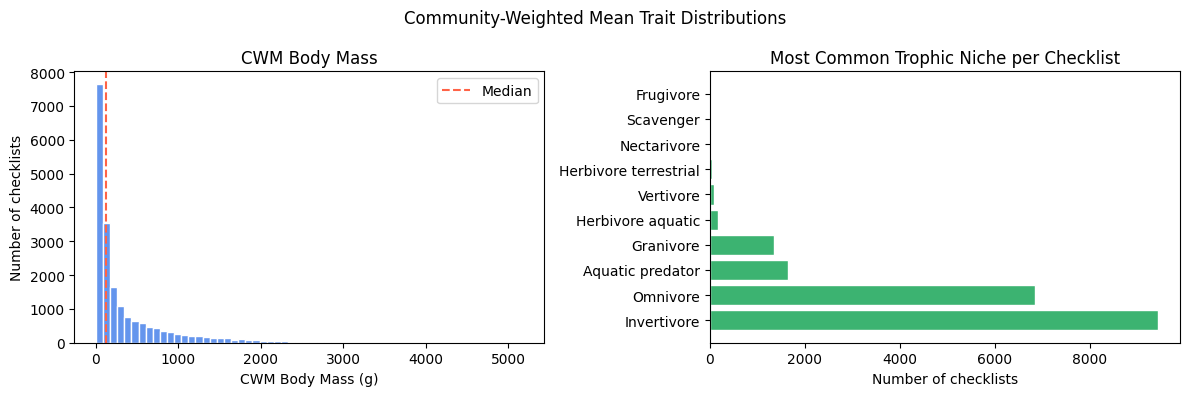


Checklists with CWM mass > 500g (potential waterbird influence): 4455
  → These will need sensitivity checking in the statistical models (see Notebook 4).


In [ ]:
# Quick plot: distribution of CWM body mass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Community-Weighted Mean Trait Distributions', fontsize=12)

axes[0].hist(cwm['Mass_wmean'].dropna(), bins=60, color='cornflowerblue', edgecolor='white', lw=0.4)
axes[0].set_xlabel('CWM Body Mass (g)')
axes[0].set_ylabel('Number of checklists')
axes[0].set_title('CWM Body Mass')
axes[0].axvline(cwm['Mass_wmean'].median(), color='tomato', ls='--', lw=1.5, label='Median')
axes[0].legend()

trophic_order = cwm['Trophic.Niche_mode_w'].value_counts()
axes[1].barh(trophic_order.index, trophic_order.values, color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('Number of checklists')
axes[1].set_title('Most Common Trophic Niche per Checklist')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_cwm_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag potential waterbird outliers in body mass
n_outliers = (cwm['Mass_wmean'] > 500).sum()
print(f'\nChecklists with CWM mass > 500g (potential waterbird influence): {n_outliers}')
print('  → These will need sensitivity checking in the statistical models (see Notebook 4).')


---
# PART 3: Environmental Layers + GIS Assembly

Downloads census tracts, five environmental/social layers (UHI, SVI, canopy,
VIIRS light pollution, HOLC redlining grade), computes plumage brightness,
spatially joins eBird checklists to tracts, and merges everything into one
final checklist-level dataset.

**Uses from Part 0:** `STATE_FIPS`, `COUNTY_FIPS`, `CITY_NAME`, `CITY_CODE`,
`OUTPUT_DIR`, `EBIRD_DIVERSITY_FILE`, `EBIRD_SPECIES_FILE`, `CWM_TRAITS_FILE`,
`UHI_FILE`, `SVI_LOCAL_FILE`, `BRIGHTNESS_SOURCE_FILE`, `OUTPUT_FILE`, `PROJECT_ID`

---
## A note on temporal alignment (read this before Sections 6–7)

Your eBird checklists cover **January 2024 – February 2026**. None of the five
environmental/social layers below were collected on exactly that schedule —
some update annually, some are frozen historical snapshots. The rule this
notebook follows: **use the most recent year actually available for each
dataset, and say so explicitly** rather than letting the mismatch pass
silently. A quick summary (updated at data-load time, see Section 9):

| Dataset | Update cycle | Best available for 2024–2026 | Why |
|---|---|---|---|
| UHI (Hsu et al. 2021) | one-time, fixed | 2013–2017 composite | Paper was never re-run; this is the only version that exists. |
| SVI (CDC) | every 2 years | 2022 (confirm against svi.cdc.gov before you run) | 2024 release may or may not be out yet — check the site. |
| Canopy cover (NLCD/USFS TCC) | annual | 2023 in the confirmed EE asset (`v2023-5`); USFS extended their source data through 2025 as of mid-2026 | Check the EE Data Catalog for a newer collection ID before running — this one may have moved. |
| Light pollution (VIIRS) | annual, ~1–2 yr lag | 2022 (`ANNUAL_V22`, most recent in EE as of this notebook) | NOAA's annual composite always trails by a year or more; there is no 2024/2025 layer yet. |
| HOLC redlining maps | one-time, historical | 1935–1940 (never updated, on purpose) | This is deliberate — HOLC tests a *legacy* effect of 1930s policy on today's patterns. It should **not** be year-matched to eBird. |

Two of these (UHI, HOLC) are meant to stay fixed — that's the point of
including them. The other three (SVI, canopy, VIIRS) are meant to track your
study window as closely as the source data allows, so double-check their
"best available" year against the current data catalog before each new run —
these products get updated periodically and the number here may already be
out of date by the time you're reading this.

---
## Section 4: Download Census Tract Boundaries

**Source:** US Census Bureau TIGER/Line shapefiles — free, no account needed.

We use **census tracts** (not NPUs as in the Fulton County analysis) because tracts
are nationally consistent and always available. All spatial analysis in this notebook
uses the 11-digit GEOID as the unique tract identifier.

The `neighborhood` column in the output CSV will contain the GEOID, allowing analysis
Notebooks 4–12 to run without modification.

In [ ]:
def download_census_tracts(state_fips, county_fips, year=2021):
    """Download and filter census tract shapefile for one county."""
    url = (f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/"
           f"tl_{year}_{state_fips}_tract.zip")
    print(f"Downloading census tracts for state {state_fips}...")
    response = requests.get(url, timeout=120)
    response.raise_for_status()

    out_dir = f"tracts_{state_fips}/"
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(BytesIO(response.content)) as z:
        z.extractall(out_dir)

    tracts = gpd.read_file(f"{out_dir}tl_{year}_{state_fips}_tract.shp")
    county_tracts = tracts[tracts['COUNTYFP'] == county_fips].copy()
    county_tracts = county_tracts.to_crs('EPSG:4326')

    print(f"Downloaded {len(county_tracts)} census tracts for county {county_fips}")
    return county_tracts

tracts = download_census_tracts(STATE_FIPS, COUNTY_FIPS)
print("Sample GEOIDs:", tracts['GEOID'].head().tolist())
print("CRS:", tracts.crs)

# Save tracts to the same output folder as OUTPUT_FILE so Notebook 13b (or a
# fresh session of this notebook) can load them back without re-downloading
# from Census TIGER every time.
TRACTS_OUTPUT_PATH = os.path.join(os.path.dirname(OUTPUT_FILE) or '.', f'{CITY_CODE}_census_tracts.geojson')
tracts.to_file(TRACTS_OUTPUT_PATH, driver='GeoJSON')
print(f"Saved tracts to: {TRACTS_OUTPUT_PATH}")

Downloaded 249 census tracts for county 157
Sample GEOIDs: ['47157009700', '47157009800', '47157021420', '47157021430', '47157021754']
CRS: EPSG:4326
Saved tracts to: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/memphis_census_tracts.geojson


---
### Quick-look maps: check every layer as you load it

Students look at the visuals, not the printed missing-data counts — so every
data source below gets mapped immediately after it loads, not saved for a
final results section. Each map answers the same question at a glance:
*does this look like a real city, or did something fail silently?* (a blank
patch of tracts, an obviously wrong color pattern, or "No data" covering
half the map means stop and debug before moving on — don't wait until
Section 12 to find out the SVI merge failed).

In [ ]:
def plot_tract_choropleth(tracts, data_df, value_col, title, cmap='viridis',
                           categorical=False, legend_label=None):
    """Merge a per-tract dataframe onto tract geometry and map it immediately.

    Run this right after loading each data source (not at the end of the
    notebook) so a bad merge, a wrong GEOID format, or an empty result is
    obvious as soon as it happens, instead of surfacing as a mystery NaN
    three sections later.
    """
    merged = tracts[['GEOID', 'geometry']].merge(
        data_df[['GEOID', value_col]], on='GEOID', how='left'
    )
    n_missing = merged[value_col].isna().sum()

    fig, ax = plt.subplots(figsize=(8, 8))
    plot_kwargs = dict(
        column=value_col, ax=ax, cmap=cmap, edgecolor='white', linewidth=0.2,
        missing_kwds={'color': 'lightgrey', 'label': 'No data'}, legend=True,
    )
    if categorical:
        merged.plot(categorical=True, **plot_kwargs)
    else:
        merged.plot(legend_kwds={'label': legend_label or value_col, 'shrink': 0.6},
                     **plot_kwargs)

    ax.set_title(f"{title}\n({n_missing} of {len(merged)} tracts missing data)", fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return merged


---
## Section 5: Download and Process CDC Social Vulnerability Index (SVI)

**Source:** CDC/ATSDR Social Vulnerability Index — census tract level, nationally
consistent, free download. We use the 2022 version.

**Download:**
1. Go to [svi.cdc.gov/dataDownloads/data-download.html](https://svi.cdc.gov/dataDownloads/data-download.html)
2. Select Year: **2022**, Geography: **Census Tracts**, File Type: **CSV**
3. Select your state → Download
4. Save as `SVI2022_{STATE_ABBR}_tract.csv`

The code below also tries a direct URL to the national CSV as a fallback
(`SVI2022_US.csv`). If direct download fails, use the interactive tool above.

**Key variable:** `RPL_THEMES` (overall SVI percentile rank, 0–1; higher = more
vulnerable). This replaces `Tot_Vul` from the Fulton County dataset and maps to
`total_vuln` in the output. Missing values in SVI are coded as −999 and are
replaced with NaN.

**Not available in SVI (compared to Fulton):** `ac_prevalence` and `rel_mort_rate`.
See Section 11 for how to handle these in analysis Notebooks 4–12.

In [ ]:
def download_svi(state_abbr, state_fips, county_fips, year=2022):
    """Download CDC SVI at census tract level and filter to one county."""
    county_fips_5 = f"{state_fips}{county_fips}"

    # Try state-level CSV first (smaller), then national fallback
    urls_to_try = [
        (f"https://svi.cdc.gov/Documents/Data/{year}_SVI_data/CSV/"
         f"States_Counties/{state_abbr}.csv"),
        (f"https://svi.cdc.gov/Documents/Data/{year}_SVI_data/CSV/"
         f"SVI{year}_US.csv"),
    ]
    svi = None
    for url in urls_to_try:
        try:
            print(f"Trying: {url}")
            svi = pd.read_csv(url, dtype={'FIPS': str})
            print("Download succeeded.")
            break
        except Exception as e:
            print(f"  Failed ({e})")

    if svi is None:
        raise RuntimeError(
            "CDC SVI direct download failed.\n"
            "Download manually from: https://svi.cdc.gov/dataDownloads/data-download.html\n"
            "Select Year=2022, Geography=Census Tracts, File Type=CSV, then your state.\n"
            "Save the file and call pd.read_csv('your_file.csv', dtype={'FIPS': str})."
        )

    # Filter to our county (FIPS = 5-digit state+county code prefix)
    svi_county = svi[svi['FIPS'].str.startswith(county_fips_5)].copy()

    svi_county = svi_county.rename(columns={
        'FIPS':       'GEOID',
        'RPL_THEMES': 'total_vuln',
        'EP_POV150':  'pct_poverty',
        'EP_MINRTY':  'pct_minority',
        'EP_UNEMP':   'pct_unemployed',
        'EP_NOHSDP':  'pct_no_hs_diploma',
        'EP_AGE65':   'pct_age65plus',
        'LOCATION':   'tract_name',
    })
    # SVI uses -999 for missing — replace with NaN
    svi_county = svi_county.replace(-999, np.nan)

    keep_cols = ['GEOID', 'total_vuln', 'pct_poverty', 'pct_minority',
                 'pct_unemployed', 'pct_no_hs_diploma', 'pct_age65plus', 'tract_name']
    svi_county = svi_county[[c for c in keep_cols if c in svi_county.columns]]
    print(f"SVI loaded for {len(svi_county)} tracts")
    return svi_county

# Commenting out the automatic download as user provided local file.
# svi = download_svi(STATE_ABBR, STATE_FIPS, COUNTY_FIPS)

# --- Data vintage note ---
# CDC SVI is released roughly every 2 years. As of when this notebook was
# written, 2022 is the most recent release -- confirm this against
# https://www.atsdr.cdc.gov/place-health/php/svi/index.html before running;
# a 2024 release may exist by the time you're reading this, in which case
# update SVI_YEAR and re-download rather than reusing the 2022 file.
SVI_YEAR = 2022  # <-- update this if you re-download a newer release

# --- Load SVI from local file (as provided by user) ----
local_svi_file = SVI_LOCAL_FILE  # was hardcoded to Chicago's specific path

print(f"Loading local SVI file: {local_svi_file}")
svi_raw = pd.read_csv(local_svi_file, dtype={'FIPS': str})

# Replicate the processing logic from download_svi function
county_fips_5 = f"{STATE_FIPS}{COUNTY_FIPS}"

# Filter to our county (FIPS = 5-digit state+county code prefix)
svi = svi_raw[svi_raw['FIPS'].str.startswith(county_fips_5)].copy()

svi = svi.rename(columns={
    'FIPS':       'GEOID',
    'RPL_THEMES': 'total_vuln',
    'EP_POV150':  'pct_poverty',
    'EP_MINRTY':  'pct_minority',
    'EP_UNEMP':   'pct_unemployed',
    'EP_NOHSDP':  'pct_no_hs_diploma',
    'EP_AGE65':   'pct_age65plus',
    'LOCATION':   'tract_name',
})
# SVI uses -999 for missing — replace with NaN
svi = svi.replace(-999, np.nan)

keep_cols = ['GEOID', 'total_vuln', 'pct_poverty', 'pct_minority',
             'pct_unemployed', 'pct_no_hs_diploma', 'pct_age65plus', 'tract_name']
svi = svi[[c for c in keep_cols if c in svi.columns]]
print(f"SVI loaded for {len(svi)} tracts from local file.")

# Verify that GEOID formats match the tracts shapefile (both should be 11-digit strings)
print("SVI GEOID sample   :", svi['GEOID'].head().tolist())
print("Tracts GEOID sample:", tracts['GEOID'].head().tolist())

Loading local SVI file: /content/drive/MyDrive/MainFolderMemphis/Memphis/Raw_dataMemp/Tennessee.csv
SVI loaded for 249 tracts from local file.
SVI GEOID sample   : ['47157000100', '47157000200', '47157000300', '47157000400', '47157000600']
Tracts GEOID sample: ['47157009700', '47157009800', '47157021420', '47157021430', '47157021754']


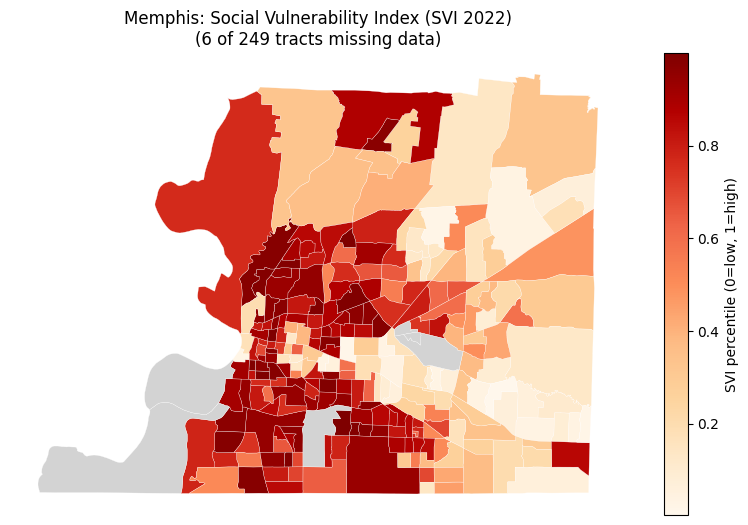

,GEOID,geometry,total_vuln
0,47157009700,"POLYGON ((-89.92323 35.07884, -89.92322 35.078...",0.9678
1,47157009800,"POLYGON ((-89.90615 35.14876, -89.90614 35.149...",0.9821
2,47157021420,"POLYGON ((-89.82395 35.10223, -89.82389 35.104...",0.0733
3,47157021430,"POLYGON ((-89.84557 35.09932, -89.84547 35.099...",0.1998
4,47157021754,"POLYGON ((-89.84873 35.01807, -89.84871 35.019...",0.6953
...,...,...,...
244,47157010120,"POLYGON ((-90.03517 35.18975, -90.03517 35.189...",0.9320
245,47157003400,"POLYGON ((-90.01328 35.1325, -90.01314 35.1326...",0.3101
246,47157000100,"POLYGON ((-90.06468 35.1702, -90.06467 35.1711...",0.1956
247,47157000300,"POLYGON ((-90.03673 35.16405, -90.0364 35.1663...",0.9577


In [ ]:
plot_tract_choropleth(
    tracts, svi, 'total_vuln',
    f'{CITY_NAME}: Social Vulnerability Index (SVI {SVI_YEAR})',
    cmap='OrRd', legend_label='SVI percentile (0=low, 1=high)'
)


## Resources

### Setting up a Google Cloud Project for Earth Engine (for Students)

To use Google Earth Engine (GEE) data in this notebook without encountering `PERMISSION_DENIED` or `Project not found or deleted` errors, you need to use your own Google Cloud Project and ensure the correct permissions are granted. Follow these steps:

1.  **Create a Google Cloud Project:**
    *   Go to the [Google Cloud Console](https://console.cloud.google.com/projectcreate).
    *   Click 'CREATE PROJECT', give it a meaningful name (e.g., 'My-Earth-Engine-Project').
    *   **IMPORTANT:** After creation, you will see a 'Project info' card on the project dashboard. **Copy the exact Project ID from there.** This is usually a unique, lowercase string (e.g., `my-earth-engine-project-123456`) and is what you will use in your Colab notebook.

2.  **Enable the Earth Engine API for your project:**
    *   In the Google Cloud Console, navigate to 'APIs & Services' -> 'Library'.
    *   Search for 'Earth Engine API' and select it.
    *   Click 'ENABLE' to enable the API for your newly created project.

3.  **Link your project to Earth Engine:**
    *   Go to the [Earth Engine Sign Up page](https://earthengine.google.com/signup/).
    *   Follow the prompts. When asked to select a Cloud Project, choose the one you just created from the dropdown menu.
    *   Complete the sign-up process. It might take a few minutes for the linking to become fully active.

4.  **Grant IAM Permissions:**
    *   In the Google Cloud Console, navigate to your Earth Engine project.
    *   Go to 'IAM & Admin' -> 'IAM'.
    *   Click '+ GRANT ACCESS'.
    *   In the 'New principals' field, enter the email address of the Google account you are using for Colab.
    *   **Select the following roles:**
        *   **'Earth Engine Resource User'**: This is essential for accessing Earth Engine resources.
        *   **'Service Usage Consumer'**: This allows the project to consume services like the Earth Engine API.
        *   **'Project Viewer'**: This may be necessary to ensure basic visibility of the project.
    *   Click 'SAVE'.

    *   **IMPORTANT**: Permission changes can take a few minutes (sometimes up to 15-30 minutes) to propagate. If you still encounter errors, wait a bit and try again.

Once you have successfully created and linked your Google Cloud Project, and granted the necessary permissions, please ensure the `PROJECT_ID` variable in your Colab notebook *exactly* matches the Project ID you copied from the Google Cloud Console, then re-run the `ee.Authenticate()` and `ee.Initialize()` cells.

---
## Section 6: Urban Heat Island (UHI) Data — Hsu et al. (2021)

**Source:** Hsu et al. (2021) *Nature Communications* — "Disproportionate exposure to urban heat island intensity across major US cities" ([DOI: 10.1038/s41467-021-22799-5](https://doi.org/10.1038/s41467-021-22799-5))

**No Earth Engine needed here.** The paper's supplementary data is a single CSV covering all 169 of the largest US urbanized areas, already computed at the census-tract level — so we just load it and filter/merge on GEOID. No asset uploads, no zonal stats to run ourselves.

Point `UHI_FILE` at the supplementary CSV (e.g. `Census_UHI_US_Urbanized_recalculated.csv`).

In [ ]:
# --- Data vintage note ---
# Hsu et al. (2021) UHI values are derived from Landsat thermal imagery
# averaged over 2013-2017. This is a ONE-TIME calculation -- there is no
# newer version to swap in. For a 2024-2026 eBird window this is a ~7-11
# year lag; treat UHI as a stable structural feature of the urban landscape
# (heat islands don't relocate quickly) rather than a same-year measurement.

UHI_FILE = '/content/drive/MyDrive/MainFolderMemphis/Memphis/Raw_dataMemp/Census_UHI_US_Urbanized_recalculated.csv'   # Hsu et al. (2021) supplementary table
UHI_GEOID_COL = 'Census_geoid'
UHI_VALUE_COL = 'UHI_annual_day'   # daytime surface UHI; swap for UHI_annual_night / UHI_summer_day / etc. as needed

def load_hsu_uhi(filepath, geoid_col, value_col, city_name=None):
    """Load Hsu et al. (2021) UHI data and standardize to census tract GEOID."""
    uhi_raw = pd.read_csv(filepath, dtype={geoid_col: str})
    uhi_raw[geoid_col] = uhi_raw[geoid_col].str.zfill(11)  # restore dropped leading zeros

    if city_name:
        uhi_raw = uhi_raw[uhi_raw['Urban_name'].str.contains(city_name, case=False, na=False)]

    return uhi_raw.rename(columns={
        geoid_col: 'GEOID',
        value_col:  'heat_intensity',
    })[['GEOID', 'heat_intensity']]

uhi = load_hsu_uhi(UHI_FILE, UHI_GEOID_COL, UHI_VALUE_COL, city_name=CITY_NAME)
print(f"UHI values loaded for {len(uhi)} tracts in {CITY_NAME}")


UHI values loaded for 269 tracts in Memphis


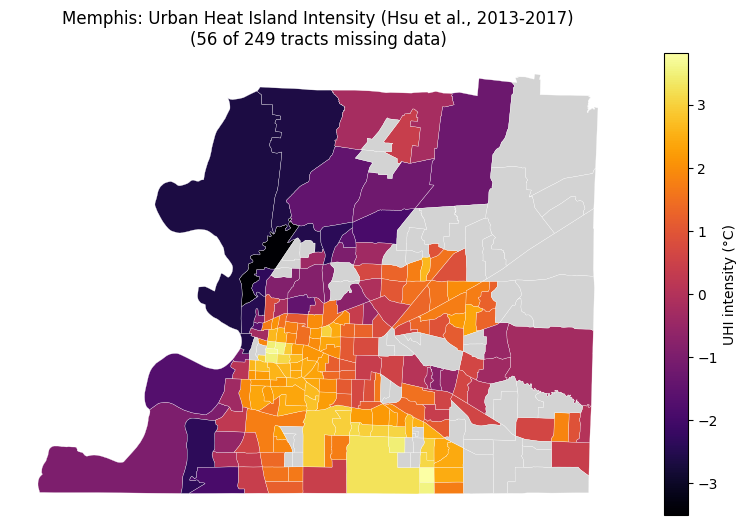

,GEOID,geometry,heat_intensity
0,47157009700,"POLYGON ((-89.92323 35.07884, -89.92322 35.078...",1.162437
1,47157009800,"POLYGON ((-89.90615 35.14876, -89.90614 35.149...",0.800470
2,47157021420,"POLYGON ((-89.82395 35.10223, -89.82389 35.104...",-0.509745
3,47157021430,"POLYGON ((-89.84557 35.09932, -89.84547 35.099...",0.573464
4,47157021754,"POLYGON ((-89.84873 35.01807, -89.84871 35.019...",3.822010
...,...,...,...
244,47157010120,"POLYGON ((-90.03517 35.18975, -90.03517 35.189...",-0.874540
245,47157003400,"POLYGON ((-90.01328 35.1325, -90.01314 35.1326...",2.912552
246,47157000100,"POLYGON ((-90.06468 35.1702, -90.06467 35.1711...",-2.478838
247,47157000300,"POLYGON ((-90.03673 35.16405, -90.0364 35.1663...",0.810529


In [ ]:
plot_tract_choropleth(
    tracts, uhi, 'heat_intensity',
    f'{CITY_NAME}: Urban Heat Island Intensity (Hsu et al., 2013-2017)',
    cmap='inferno', legend_label='UHI intensity (°C)'
)


---
## Section 7: Earth Engine setup (for canopy cover + light pollution)

Canopy cover and light pollution aren't packaged as one tidy tract-level CSV the way UHI is, which is where Earth Engine actually earns its keep here: it computes zonal statistics straight from the raw satellite rasters, for any city, with no per-city manual download from the MRLC viewer and no gigabyte-scale files to manage in Colab.

**One-time setup, per student/team, first run only:**
1. Create a Google Cloud project at [console.cloud.google.com/projectcreate](https://console.cloud.google.com/projectcreate) (any name).
2. Enable Earth Engine for it at [console.cloud.google.com/earth-engine](https://console.cloud.google.com/earth-engine) — choose the free noncommercial/education tier.
3. Put that project's ID in `PROJECT_ID` below.

Run the cell once — the first run opens an authentication link; after that, credentials are cached.

In [ ]:
!pip install -q earthengine-api

import ee

# PROJECT_ID is already set in Part 0's master config -- update it there,
# not here, if you need to change your GCP project.

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine ready.")


Earth Engine ready.


In [ ]:
import json

def tracts_to_ee(tracts_gdf, keep_cols=('GEOID',), simplify_tolerance=0.0001):
    """Convert a tracts GeoDataFrame to an ee.FeatureCollection.

    Keeps only the columns needed and lightly simplifies geometry so the
    payload stays well under Earth Engine's inline size limit for one
    county -- no asset upload or Google Drive round-trip required.
    """
    slim = tracts_gdf[list(keep_cols) + ['geometry']].copy()
    slim['geometry'] = slim['geometry'].simplify(simplify_tolerance, preserve_topology=True)
    return ee.FeatureCollection(json.loads(slim.to_json()))


def ee_zonal_stats(tracts_fc, image, band, reducer=None, reducer_name='mean', scale=30, out_col='value'):
    """Zonal statistics for one band of an ee.Image over a FeatureCollection.

    Uses reduceRegions (a single server-side call covering every tract) instead
    of mapping reduceRegion over each feature one at a time, and returns the
    result directly as a DataFrame via getInfo() -- no export/Drive step
    needed for a single county's worth of tracts.

    `reducer_name` must match the output property name Earth Engine assigns
    for the given reducer (e.g. 'mean' for ee.Reducer.mean(), 'median' for
    ee.Reducer.median()).
    """
    if reducer is None:
        reducer = ee.Reducer.mean()
    stats_fc = image.select(band).reduceRegions(collection=tracts_fc, reducer=reducer, scale=scale)
    result = stats_fc.getInfo()
    rows = [f['properties'] for f in result['features']]
    df = pd.DataFrame(rows).rename(columns={reducer_name: out_col})
    return df[['GEOID', out_col]]

tracts_fc = tracts_to_ee(tracts)
print(f"Converted {len(tracts)} tracts to an Earth Engine FeatureCollection.")


Converted 249 tracts to an Earth Engine FeatureCollection.


### Section 7: NLCD tree canopy cover (via Earth Engine)

USFS/NLCD Tree Canopy Cover (`USGS/NLCD_RELEASES/2023_REL/TCC/v2023-5`), 30 m resolution, annual coverage 1985–2023. Nothing to download — this is the payoff of doing it through Earth Engine: the same few lines work for any US city your students pick.

In [ ]:
# --- Data vintage note ---
# 2023 is the most recent year in the EE-confirmed asset
# (USGS/NLCD_RELEASES/2023_REL/TCC/v2023-5) as of when this notebook was
# written. USFS extended their canopy cover source data through 2025 in a
# mid-2026 release -- check https://developers.google.com/earth-engine/datasets
# (search "tree canopy cover") for a newer collection ID before running;
# if one exists, update CANOPY_YEAR and the collection ID together below.
# For a 2024-2026 eBird window, 2023 is a 1-3 year lag -- reasonable, since
# tract-level canopy cover rarely shifts drastically in 1-2 years absent a
# major disturbance (development, storm damage, disease).
CANOPY_YEAR = 2023

canopy_image = (
    ee.ImageCollection('USGS/NLCD_RELEASES/2023_REL/TCC/v2023-5')
    .filter(ee.Filter.calendarRange(CANOPY_YEAR, CANOPY_YEAR, 'year'))
    .filter('study_area == "CONUS"')
    .first()
)

canopy = ee_zonal_stats(tracts_fc, canopy_image, 'NLCD_Percent_Tree_Canopy_Cover', out_col='canopy_pct')
print(f"Canopy cover extracted for {canopy['canopy_pct'].notna().sum()} of {len(canopy)} tracts")
print(f"Mean canopy: {canopy['canopy_pct'].mean():.1f}%")


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for USGS/NLCD_RELEASES/2023_REL/TCC/v2023-5! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by projects/gtac-data-publish/assets/TCC/Product_Version/2025-6

Learn more: https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2023_REL_TCC_v2023-5

  warnings.warn(warning, category=DeprecationWarning)


Canopy cover extracted for 249 of 249 tracts
Mean canopy: 30.3%


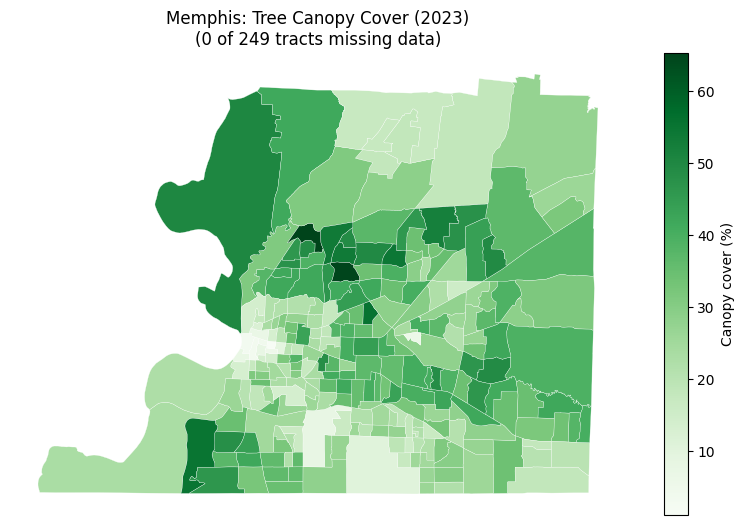

,GEOID,geometry,canopy_pct
0,47157009700,"POLYGON ((-89.92323 35.07884, -89.92322 35.078...",27.409987
1,47157009800,"POLYGON ((-89.90615 35.14876, -89.90614 35.149...",31.285108
2,47157021420,"POLYGON ((-89.82395 35.10223, -89.82389 35.104...",39.159523
3,47157021430,"POLYGON ((-89.84557 35.09932, -89.84547 35.099...",42.711208
4,47157021754,"POLYGON ((-89.84873 35.01807, -89.84871 35.019...",26.540447
...,...,...,...
244,47157010120,"POLYGON ((-90.03517 35.18975, -90.03517 35.189...",41.772830
245,47157003400,"POLYGON ((-90.01328 35.1325, -90.01314 35.1326...",20.186521
246,47157000100,"POLYGON ((-90.06468 35.1702, -90.06467 35.1711...",14.077958
247,47157000300,"POLYGON ((-90.03673 35.16405, -90.0364 35.1663...",21.842411


In [ ]:
plot_tract_choropleth(
    tracts, canopy, 'canopy_pct',
    f'{CITY_NAME}: Tree Canopy Cover ({CANOPY_YEAR})',
    cmap='Greens', legend_label='Canopy cover (%)'
)


### Bonus: light pollution (VIIRS nighttime lights, via Earth Engine)

VIIRS annual composites are exactly the kind of dataset Earth Engine is built for: the global raw imagery is far too large to download, but the zonal stat below runs server-side and only the per-tract summary comes back. `average_masked` filters out background noise and artifacts (aurora, fires, stray light). 2012–2021 lives in `ANNUAL_V21`; 2022 onward is in `ANNUAL_V22`.

In [ ]:
# --- Data vintage note ---
# This is the biggest mismatch of the five datasets. NOAA's VIIRS annual
# composite lags real time by 1-2+ years, and as of this notebook, 2022
# is the most recent year available in Earth Engine (NOAA/VIIRS/DNB/ANNUAL_V22).
# There is no 2024 or 2025 layer yet. For a 2024-2026 eBird window this is a
# 2-4 year lag. Check the EE catalog for a newer release before running --
# if NOAA has since published 2024/2025 composites, update LIGHT_YEAR and
# light_collection accordingly.
LIGHT_YEAR = 2022
light_collection = 'NOAA/VIIRS/DNB/ANNUAL_V22' if LIGHT_YEAR >= 2022 else 'NOAA/VIIRS/DNB/ANNUAL_V21'

light_image = (
    ee.ImageCollection(light_collection)
    .filter(ee.Filter.calendarRange(LIGHT_YEAR, LIGHT_YEAR, 'year'))
    .first()
)

# VIIRS pixels are ~464 m -- pass that as scale rather than the 30 m default (Landsat-scale)
light_pollution = ee_zonal_stats(tracts_fc, light_image, 'average_masked', scale=464, out_col='light_radiance')
print(f"Light pollution extracted for {light_pollution['light_radiance'].notna().sum()} of {len(light_pollution)} tracts")
print(f"Mean radiance: {light_pollution['light_radiance'].mean():.2f} nW/cm²/sr")


Light pollution extracted for 249 of 249 tracts
Mean radiance: 33.13 nW/cm²/sr


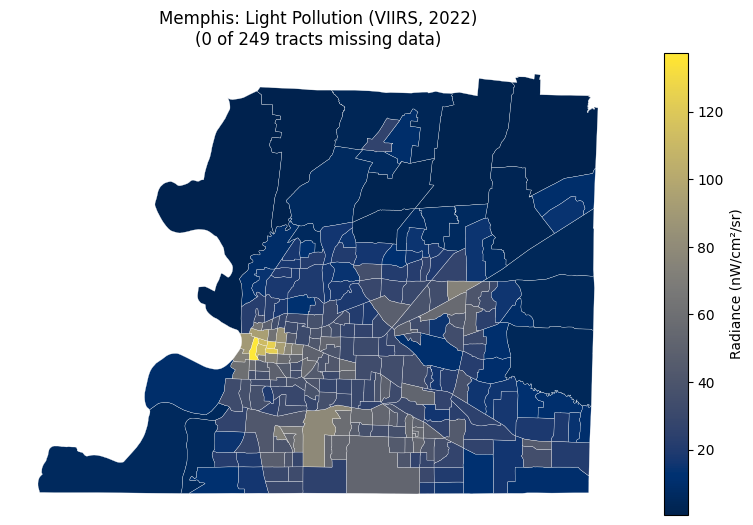

,GEOID,geometry,light_radiance
0,47157009700,"POLYGON ((-89.92323 35.07884, -89.92322 35.078...",25.459467
1,47157009800,"POLYGON ((-89.90615 35.14876, -89.90614 35.149...",27.528318
2,47157021420,"POLYGON ((-89.82395 35.10223, -89.82389 35.104...",21.988495
3,47157021430,"POLYGON ((-89.84557 35.09932, -89.84547 35.099...",26.700140
4,47157021754,"POLYGON ((-89.84873 35.01807, -89.84871 35.019...",30.458645
...,...,...,...
244,47157010120,"POLYGON ((-90.03517 35.18975, -90.03517 35.189...",18.045823
245,47157003400,"POLYGON ((-90.01328 35.1325, -90.01314 35.1326...",75.610377
246,47157000100,"POLYGON ((-90.06468 35.1702, -90.06467 35.1711...",22.409436
247,47157000300,"POLYGON ((-90.03673 35.16405, -90.0364 35.1663...",22.108190


In [ ]:
plot_tract_choropleth(
    tracts, light_pollution, 'light_radiance',
    f'{CITY_NAME}: Light Pollution (VIIRS, {LIGHT_YEAR})',
    cmap='cividis', legend_label='Radiance (nW/cm²/sr)'
)


---
## Section 8: Download and Process Mapping Inequality HOLC Data

**Source:** Mapping Inequality, University of Richmond
**Coverage check:** [dsl.richmond.edu/panorama/redlining/](https://dsl.richmond.edu/panorama/redlining/)
**HOLC grades:** A (Best), B (Still Desirable), C (Declining), D (Hazardous)

**Data file:** The code downloads the national HOLC GeoJSON from the DSL Richmond
server (`holc-ad-data.geojson`). This file uses `holc_grade` as the grade column and
`city` as the city column. If the download fails, go to:
[dsl.richmond.edu/panorama/redlining/](https://dsl.richmond.edu/panorama/redlining/) →
Downloads → "All areas (GeoJSON)" and save as `holc-ad-data.geojson`.

### Area-weighted HOLC grade assignment

HOLC polygons don't align with census tracts. One tract may overlap multiple grades.
We solve this with **area-weighted intersection**:
1. For each census tract, calculate what % of its area falls in each HOLC grade.
2. The dominant grade = the grade covering the most area.
3. Also compute a continuous numeric score (A=4, B=3, C=2, D=1) for regression.
4. Tracts with < 20% HOLC coverage are classified as "Ungraded" (post-war suburbs).

**Expected coverage:** Central-city tracts are typically 80–100% covered; suburban
tracts built after WWII will be Ungraded. Expect 30–60% of tracts to be graded in
most cities. Only graded tracts are used in Section 13's HOLC analysis.

In [ ]:
# --- Data vintage note ---
# HOLC "redlining" maps date to 1935-1940 and were never updated -- there is
# no newer version, and there shouldn't be one. Unlike the other four
# datasets, HOLC is INTENTIONALLY not matched to the 2024-2026 eBird window:
# the whole point of including it is to test whether an ~85-90 year old
# policy still predicts today's urban bird patterns (a legacy effect), not
# to describe present-day conditions.

def download_holc_data(city_name_in_url):
    """Download HOLC polygons for a city from Mapping Inequality (DSL Richmond)."""
    # Defensive imports -- don't depend on Section 1 having been run first in
    # this session (common in a classroom setting where students jump around
    # cells or restart the runtime partway through).
    import tempfile
    import os

    # NOTE on source: DSL Richmond's own "static" download URL has changed at
    # least twice and returns silent HTML error pages when it moves, which is
    # hard to debug from inside a class session. This instead pulls from DSL
    # Richmond's own GitHub org (americanpanorama), which hosts the same data
    # as a version-controlled file -- much less likely to silently 404/redirect.
    # Source repo: https://github.com/americanpanorama/mapping-inequality-census-crosswalk
    # (bonus: these polygons are already clipped to 2020 census tracts, which
    # is why area_weighted_holc() below runs faster than the earlier version --
    # it's overlaying tract-sized fragments instead of whole-city polygons.)
    url = ("https://raw.githubusercontent.com/americanpanorama/"
           "mapping-inequality-census-crosswalk/main/MIv3Areas_2020TractCrosswalk.geojson")

    holc = None
    tmp_filepath = None

    try:
        print("Downloading national HOLC/tract crosswalk GeoJSON (~70 MB, may take a minute)...")
        response = requests.get(url, timeout=300, headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()

        # A failed/redirected request often still returns HTTP 200 with an
        # HTML error page instead of GeoJSON -- catch that explicitly instead
        # of letting it fail deep inside gpd.read_file with a confusing error.
        content_start = response.content[:100].lstrip().lower()
        if content_start.startswith(b'<!doctype') or content_start.startswith(b'<html'):
            raise ValueError(
                "Server returned an HTML page instead of GeoJSON -- the "
                "download URL has likely changed again. Check "
                "https://github.com/americanpanorama/mapping-inequality-census-crosswalk "
                "for the current filename."
            )

        with tempfile.NamedTemporaryFile(suffix=".geojson", delete=False) as tmpfile:
            tmpfile.write(response.content)
            tmp_filepath = tmpfile.name

        holc = gpd.read_file(f"GeoJSON:{tmp_filepath}")
        print(f"Downloaded and processed {len(holc)} HOLC polygon fragments.")

    except requests.exceptions.RequestException as e:
        print(f"  Download error: {e}")
    except Exception as e:
        print(f"  Processing error: {e}")
    finally:
        if tmp_filepath and os.path.exists(tmp_filepath):
            os.remove(tmp_filepath)

    if holc is None:
        raise RuntimeError(
            "HOLC download or processing failed.\n"
            "As a fallback, browse the repo directly and download the file manually:\n"
            "  https://github.com/americanpanorama/mapping-inequality-census-crosswalk\n"
            "  -> MIv3Areas_2020TractCrosswalk.geojson -> Download raw file\n"
            "Then, modify the code to call: holc_polygons = gpd.read_file('MIv3Areas_2020TractCrosswalk.geojson')\n"
            "Alternative source (original, ungeocoded-to-tracts DSL Richmond data):\n"
            "  https://www.arcgis.com/home/item.html?id=d77c640241d84b6889ab290cd4cb755b"
        )

    # Normalise grade column: this crosswalk file uses 'grade'; some mirrors use 'holc_grade'
    if 'grade' in holc.columns and 'holc_grade' not in holc.columns:
        holc = holc.rename(columns={'grade': 'holc_grade'})
    if 'holc_grade' not in holc.columns:
        raise ValueError(f"Cannot find grade column. Available: {list(holc.columns)}")

    # Filter to our city
    holc_city = holc[holc['city'].str.contains(city_name_in_url,
                                                case=False, na=False)].copy()
    if len(holc_city) == 0:
        print(f"City '{city_name_in_url}' not found. Sample available cities:")
        print(sorted(holc['city'].dropna().unique())[:30])
        raise ValueError("City not found \u2014 check the exact spelling. "
                         "Try just the city name without 'City' or state.")

    holc_city = holc_city.to_crs('EPSG:4326')
    print(f"Loaded {len(holc_city)} HOLC polygon fragments for {city_name_in_url}")
    print("Grade distribution:")
    print(holc_city['holc_grade'].value_counts().sort_index())
    return holc_city


In [ ]:
def area_weighted_holc(tracts_gdf, holc_gdf):
    """Assign HOLC grade to each census tract via area-weighted intersection."""
    crs_equal_area = 'EPSG:5070'
    tracts_proj = tracts_gdf[['GEOID', 'geometry']].to_crs(crs_equal_area)
    holc_proj   = holc_gdf[['holc_grade', 'geometry']].to_crs(crs_equal_area)
    tracts_proj = tracts_proj.copy()
    tracts_proj['tract_area'] = tracts_proj.geometry.area

    print("Computing HOLC-tract intersection (may take 1-2 minutes)...")
    intersection = gpd.overlay(tracts_proj, holc_proj, how='intersection')
    intersection['intersect_area'] = intersection.geometry.area

    grade_areas = (intersection
        .groupby(['GEOID', 'holc_grade'])['intersect_area']
        .sum()
        .reset_index()
    )
    grade_pivot = (grade_areas
        .pivot(index='GEOID', columns='holc_grade', values='intersect_area')
        .fillna(0)
        .reset_index()
    )
    grade_pivot.columns.name = None

    for g in ['A', 'B', 'C', 'D']:
        if g not in grade_pivot.columns:
            grade_pivot[g] = 0.0

    grade_pivot = grade_pivot.merge(tracts_proj[['GEOID', 'tract_area']], on='GEOID')

    grade_pivot['holc_grade_dominant'] = grade_pivot[['A','B','C','D']].idxmax(axis=1)

    total_holc_area = grade_pivot[['A','B','C','D']].sum(axis=1)
    grade_scores = {'A': 4, 'B': 3, 'C': 2, 'D': 1}
    grade_pivot['holc_score_weighted'] = sum(
        grade_pivot[g] * s / total_holc_area.where(total_holc_area > 0, np.nan)
        for g, s in grade_scores.items()
    )
    grade_pivot['holc_coverage_pct'] = (
        total_holc_area / grade_pivot['tract_area'] * 100
    ).clip(0, 100)
    for g in ['A', 'B', 'C', 'D']:
        grade_pivot[f'pct_holc_{g.lower()}'] = (
            grade_pivot[g] / grade_pivot['tract_area'] * 100
        ).clip(0, 100)

    # Tracts with < 20% HOLC coverage classified as Ungraded
    grade_pivot.loc[grade_pivot['holc_coverage_pct'] < 20,
                    'holc_grade_dominant'] = 'Ungraded'

    result = grade_pivot[['GEOID', 'holc_grade_dominant', 'holc_score_weighted',
                           'holc_coverage_pct',
                           'pct_holc_a', 'pct_holc_b',
                           'pct_holc_c', 'pct_holc_d']].copy()

    print("\nHOLC grade assignment complete:")
    print(result['holc_grade_dominant'].value_counts())
    print(f"Tracts with >=20% coverage: {(result['holc_coverage_pct'] >= 20).sum()} "
          f"of {len(result)}")
    return result

holc_polygons = download_holc_data(CITY_NAME)
holc_tracts   = area_weighted_holc(tracts, holc_polygons)

Downloaded and processed 53483 HOLC polygon fragments.
Loaded 182 HOLC polygon fragments for Memphis
Grade distribution:
holc_grade
A    27
B    45
C    59
D    51
Name: count, dtype: int64
Computing HOLC-tract intersection (may take 1-2 minutes)...

HOLC grade assignment complete:
holc_grade_dominant
D           29
C           21
B           16
Ungraded     7
A            2
Name: count, dtype: int64
Tracts with >=20% coverage: 68 of 75


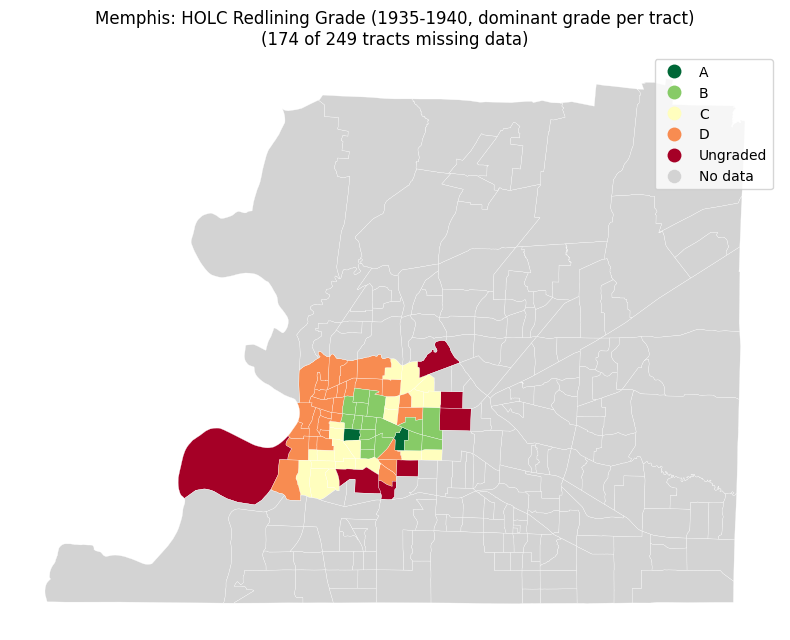

,GEOID,geometry,holc_grade_dominant
0,47157009700,"POLYGON ((-89.92323 35.07884, -89.92322 35.078...",NaN
1,47157009800,"POLYGON ((-89.90615 35.14876, -89.90614 35.149...",NaN
2,47157021420,"POLYGON ((-89.82395 35.10223, -89.82389 35.104...",NaN
3,47157021430,"POLYGON ((-89.84557 35.09932, -89.84547 35.099...",NaN
4,47157021754,"POLYGON ((-89.84873 35.01807, -89.84871 35.019...",NaN
...,...,...,...
244,47157010120,"POLYGON ((-90.03517 35.18975, -90.03517 35.189...",NaN
245,47157003400,"POLYGON ((-90.01328 35.1325, -90.01314 35.1326...",B
246,47157000100,"POLYGON ((-90.06468 35.1702, -90.06467 35.1711...",D
247,47157000300,"POLYGON ((-90.03673 35.16405, -90.0364 35.1663...",D


In [ ]:
plot_tract_choropleth(
    tracts, holc_tracts, 'holc_grade_dominant',
    f'{CITY_NAME}: HOLC Redlining Grade (1935-1940, dominant grade per tract)',
    cmap='RdYlGn_r', categorical=True
)


---
### All five layers at a glance

The five maps above are useful for catching a bad load one at a time, but
they don't answer the question you actually care about once everything is
in: **do these layers tell a coherent spatial story about this city, or do
they look unrelated to each other?** Put side by side, you should be able to
eyeball roughly where hot/low-canopy/high-vulnerability tracts overlap
before you ever run a statistic on them — if the visual story and the
eventual regression coefficients disagree, that's worth a closer look.

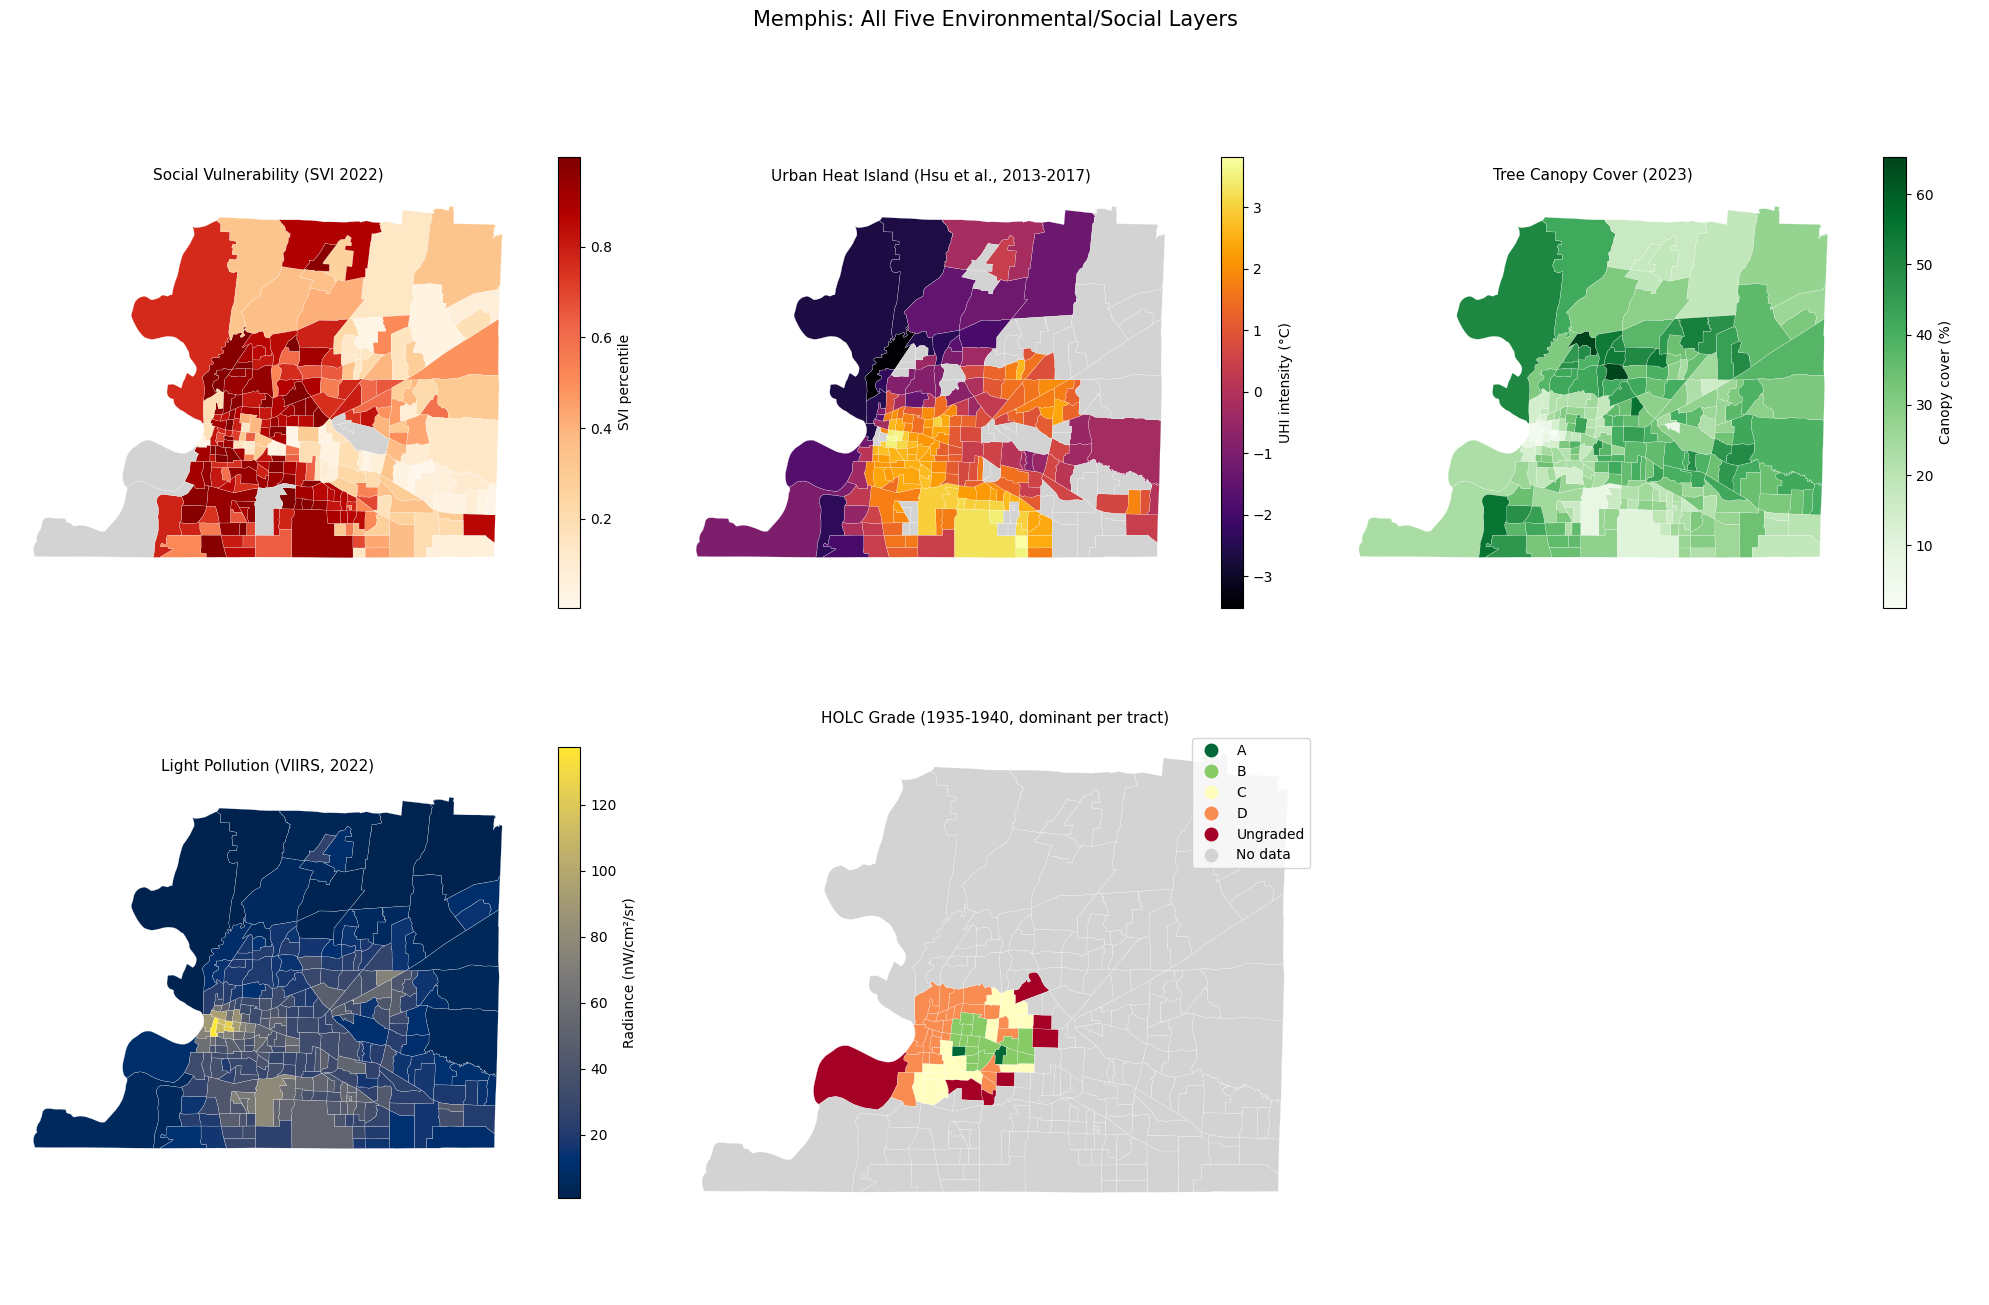

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

layers = [
    (svi,             'total_vuln',          f'Social Vulnerability (SVI {SVI_YEAR})',
     'OrRd',    False, 'SVI percentile'),
    (uhi,              'heat_intensity',      'Urban Heat Island (Hsu et al., 2013-2017)',
     'inferno', False, 'UHI intensity (°C)'),
    (canopy,           'canopy_pct',          f'Tree Canopy Cover ({CANOPY_YEAR})',
     'Greens',  False, 'Canopy cover (%)'),
    (light_pollution,  'light_radiance',      f'Light Pollution (VIIRS, {LIGHT_YEAR})',
     'cividis', False, 'Radiance (nW/cm²/sr)'),
    (holc_tracts,      'holc_grade_dominant', 'HOLC Grade (1935-1940, dominant per tract)',
     'RdYlGn_r', True, None),
]

for ax, (data_df, value_col, title, cmap, categorical, legend_label) in zip(axes, layers):
    merged = tracts[['GEOID', 'geometry']].merge(
        data_df[['GEOID', value_col]], on='GEOID', how='left'
    )
    plot_kwargs = dict(
        column=value_col, ax=ax, cmap=cmap, edgecolor='white', linewidth=0.15,
        missing_kwds={'color': 'lightgrey', 'label': 'No data'}, legend=True,
    )
    if categorical:
        merged.plot(categorical=True, **plot_kwargs)
    else:
        merged.plot(legend_kwds={'label': legend_label, 'shrink': 0.7}, **plot_kwargs)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

# Hide the unused 6th panel
axes[5].axis('off')

fig.suptitle(f'{CITY_NAME}: All Five Environmental/Social Layers', fontsize=15, y=1.00)
plt.tight_layout()
plt.show()


---
## Section 9: Spatial Join — eBird Points to Census Tracts

In [ ]:
def join_ebird_to_tracts(diversity_csv, tracts_gdf):
    """Spatially join eBird checklist centroid points to census tract polygons."""
    ebird = pd.read_csv(diversity_csv)
    geometry = [Point(xy) for xy in zip(ebird['LONGITUDE'], ebird['LATITUDE'])]
    ebird_gdf = gpd.GeoDataFrame(ebird, geometry=geometry, crs='EPSG:4326')

    joined = gpd.sjoin(
        ebird_gdf,
        tracts_gdf[['GEOID', 'geometry', 'NAMELSAD']],
        how='left',
        predicate='within'
    )
    # Points on boundaries may match multiple tracts — keep first match
    joined = joined[~joined.index.duplicated(keep='first')]
    joined = joined.rename(columns={'NAMELSAD': 'tract_name'})

    n_matched   = joined['GEOID'].notna().sum()
    n_unmatched = joined['GEOID'].isna().sum()
    print(f"Checklists matched to tracts : {n_matched:,}")
    print(f"Checklists outside boundaries: {n_unmatched:,}")
    if n_unmatched > 0.05 * len(joined):
        print("WARNING: >5% of checklists unmatched. Verify CRS alignment.")

    return joined.drop(columns='geometry')

ebird_tracts = join_ebird_to_tracts(EBIRD_DIVERSITY_FILE, tracts)

Checklists matched to tracts : 19,612
Checklists outside boundaries: 9


---
## Section 10: Assemble Final Dataset

Join all layers on `GEOID` (census tract), then attach CWM traits on
`SAMPLING.EVENT.IDENTIFIER`. The output has the same column structure as
`heat_traits_fulton.csv` so that analysis Notebooks 4–12 run unchanged.

### Plumage brightness (CWM, from Delhey et al. 2021) -- optional bonus

**Data vintage note:** like UHI and HOLC, this is a fixed, one-time
measurement (spectral photography of museum specimens) — there's no newer
version and no reason to expect one.

**Source:** Delhey et al. (2021), *Current Biology*, doi:
[10.1016/j.cub.2021.12.064](https://doi.org/10.1016/j.cub.2021.12.064),
supplementary file `mmc2.xlsx` (sheet `Data S1A`). This isn't
auto-downloadable — journal supplementary files sit behind a page you have
to click through — so download it once and drop it in your `raw_data`
folder before running this cell. If it's missing, this section skips
gracefully and everything else in the notebook still runs; brightness just
won't be in your final dataset until you add the file.

In [ ]:
def compute_cwm_brightness(species_file, brightness_source_file):
    """Community-weighted mean plumage brightness per checklist (Delhey et al. 2021).

    Unweighted mean across species detected on a checklist (matches Notebook
    12's original approach) -- not abundance-weighted, since eBird counts
    are themselves noisy estimates of true abundance.
    """
    try:
        delhey = pd.read_excel(brightness_source_file, sheet_name='Data S1A')
    except FileNotFoundError:
        print(f"{brightness_source_file} not found -- skipping plumage brightness.")
        print("Download from https://doi.org/10.1016/j.cub.2021.12.064 (Data S1A) "
              "if you want this layer; everything else in the notebook is unaffected.")
        return None

    delhey_male = (
        delhey[delhey['sex'] == 'male']
        [['scinam', 'l', 'L.dorsal', 'L.ventral']]
        .rename(columns={'scinam': 'scientific_name', 'l': 'brightness_overall',
                          'L.dorsal': 'brightness_dorsal', 'L.ventral': 'brightness_ventral'})
        .copy()
    )
    delhey_male['scientific_name'] = delhey_male['scientific_name'].str.title()

    spp = pd.read_csv(species_file, low_memory=False)
    crosswalk = (
        spp[['COMMON NAME', 'SCIENTIFIC NAME']].drop_duplicates()
        .rename(columns={'COMMON NAME': 'common_name', 'SCIENTIFIC NAME': 'scientific_name'})
    )
    crosswalk['scientific_name'] = crosswalk['scientific_name'].str.title()

    brightness_lookup = crosswalk.merge(delhey_male, on='scientific_name', how='left')
    n_matched = brightness_lookup['brightness_overall'].notna().sum()
    print(f"Species matched to brightness data: {n_matched} of {len(brightness_lookup)}")
    print("(Missing species are typically warblers and waterbirds -- not in Delhey's sample.)")

    cwm_brightness = (
        spp.merge(brightness_lookup[['common_name', 'brightness_overall',
                                      'brightness_dorsal', 'brightness_ventral']],
                  left_on='COMMON NAME', right_on='common_name', how='left')
        .groupby('SAMPLING EVENT IDENTIFIER')
        .agg(cwm_brightness_overall=('brightness_overall', 'mean'),
             cwm_brightness_dorsal=('brightness_dorsal', 'mean'),
             cwm_brightness_ventral=('brightness_ventral', 'mean'),
             n_spp_with_brightness=('brightness_overall', lambda x: x.notna().sum()))
        .reset_index()
        .rename(columns={'SAMPLING EVENT IDENTIFIER': 'SAMPLING.EVENT.IDENTIFIER'})
    )

    # Checklists matched to fewer than 3 brightness-scored species get their
    # brightness columns NaN'd (not the whole row dropped) -- this keeps the
    # checklist available for diversity/mass, just marks brightness itself as
    # unreliable for that row. Matches Notebook 12's >=3-species floor.
    low_match = cwm_brightness['n_spp_with_brightness'] < 3
    brightness_cols = ['cwm_brightness_overall', 'cwm_brightness_dorsal', 'cwm_brightness_ventral']
    cwm_brightness.loc[low_match, brightness_cols] = np.nan

    n_valid = cwm_brightness['cwm_brightness_overall'].notna().sum()
    print(f"Brightness computed for {n_valid} of {len(cwm_brightness)} checklists "
          f"(>=3 brightness-matched species)")
    return cwm_brightness

brightness = compute_cwm_brightness(EBIRD_SPECIES_FILE, BRIGHTNESS_SOURCE_FILE)


Species matched to brightness data: 195 of 255
(Missing species are typically warblers and waterbirds -- not in Delhey's sample.)
Brightness computed for 18732 of 19621 checklists (>=3 brightness-matched species)


In [ ]:
# --- Data vintage summary: run this before assembling, to see at a glance
# how each source's actual year(s) compare to your eBird window ---
DATA_VINTAGE = {
    "eBird checklists":         "2024-01 to 2026-02",
    "UHI (Hsu et al.)":         "2013-2017 (fixed -- no newer release exists)",
    "SVI (CDC)":                f"{SVI_YEAR} (confirm this is still the latest release)",
    "Canopy cover (NLCD/TCC)":  f"{CANOPY_YEAR} (check EE catalog for a newer collection)",
    "Light pollution (VIIRS)":  f"{LIGHT_YEAR} (check EE catalog -- NOAA lags 1-2+ yrs)",
    "HOLC redlining maps":      "1935-1940 (fixed, intentionally not year-matched)",
    "Plumage brightness":       "Delhey et al. 2021 (fixed museum-specimen measurement)",
}
print("Data vintage vs. eBird window (2024-01 to 2026-02):")
for name, vintage in DATA_VINTAGE.items():
    print(f"  {name:26s}: {vintage}")
print()

def assemble_final_dataset(ebird_tracts, svi, uhi, canopy, light_pollution, holc_tracts,
                            cwm_file, brightness_df=None):
    """Merge all data sources into a single analysis-ready CSV."""
    df = ebird_tracts.copy()
    if 'SAMPLING EVENT IDENTIFIER' in df.columns:
        df = df.rename(columns={'SAMPLING EVENT IDENTIFIER': 'SAMPLING.EVENT.IDENTIFIER'})

    df = df.merge(svi,             on='GEOID', how='left')
    df = df.merge(uhi,             on='GEOID', how='left')
    df = df.merge(canopy,          on='GEOID', how='left')
    df = df.merge(light_pollution, on='GEOID', how='left')
    df = df.merge(holc_tracts,     on='GEOID', how='left')

    cwm = pd.read_csv(cwm_file)
    if 'SAMPLING EVENT IDENTIFIER' in cwm.columns:
        cwm = cwm.rename(columns={'SAMPLING EVENT IDENTIFIER': 'SAMPLING.EVENT.IDENTIFIER'})
    df = df.merge(cwm, on='SAMPLING.EVENT.IDENTIFIER', how='left')

    if brightness_df is not None:
        df = df.merge(brightness_df, on='SAMPLING.EVENT.IDENTIFIER', how='left')

    # Rename GEOID to 'neighborhood' for compatibility with analysis notebooks
    # (census tracts replace NPUs as the spatial unit for this analysis)
    df = df.rename(columns={'GEOID': 'neighborhood'})

    print(f"Final dataset    : {len(df):,} checklists")
    print(f"Unique tracts    : {df['neighborhood'].nunique()}")
    print(f"Missing heat     : {df['heat_intensity'].isna().sum()}")
    print(f"Missing canopy   : {df['canopy_pct'].isna().sum()}")
    print(f"Missing vuln     : {df['total_vuln'].isna().sum()}")
    print(f"Missing light    : {df['light_radiance'].isna().sum()}")
    print(f"HOLC-graded rows : {df['holc_grade_dominant'].notna().sum():,}")
    if brightness_df is not None:
        print(f"Brightness rows  : {df['cwm_brightness_overall'].notna().sum():,}")
    return df

final_df = assemble_final_dataset(
    ebird_tracts, svi, uhi, canopy, light_pollution, holc_tracts, CWM_TRAITS_FILE, brightness
)
final_df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved: {OUTPUT_FILE}")


Data vintage vs. eBird window (2024-01 to 2026-02):
  eBird checklists          : 2024-01 to 2026-02
  UHI (Hsu et al.)          : 2013-2017 (fixed -- no newer release exists)
  SVI (CDC)                 : 2022 (confirm this is still the latest release)
  Canopy cover (NLCD/TCC)   : 2023 (check EE catalog for a newer collection)
  Light pollution (VIIRS)   : 2022 (check EE catalog -- NOAA lags 1-2+ yrs)
  HOLC redlining maps       : 1935-1940 (fixed, intentionally not year-matched)
  Plumage brightness        : Delhey et al. 2021 (fixed museum-specimen measurement)

Final dataset    : 19,621 checklists
Unique tracts    : 169
Missing heat     : 10411
Missing canopy   : 9
Missing vuln     : 6730
Missing light    : 9
HOLC-graded rows : 1,722
Brightness rows  : 18,732
Saved: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/heat_traits_memphis.csv


---
### Diagnostic: which tracts are missing heat data, and why?

7,446 of 131,694 checklists came back with no UHI value -- a meaningfully
higher miss rate than canopy or light (2 each). Two different causes look
the same in a missing-value count but very different on a map:

- **Real coverage gap:** Hsu et al.'s dataset only covers the Census
  Bureau's officially-defined "urbanized area." A county almost always
  extends past that boundary (rural fringes, low-density suburbs) --
  tracts out there will legitimately have no UHI value, because the
  underlying satellite analysis never covered them.
- **GEOID mismatch:** a formatting problem (missing leading zero, wrong
  tract vintage) would scatter missing tracts more or less randomly across
  the map, including tracts that are clearly inside the urban core.

A map distinguishes these instantly -- a real coverage gap shows missing
tracts clustered at the county's edges; a GEOID bug shows them speckled
everywhere, including downtown.

45 of 169 tracts have no UHI value at all


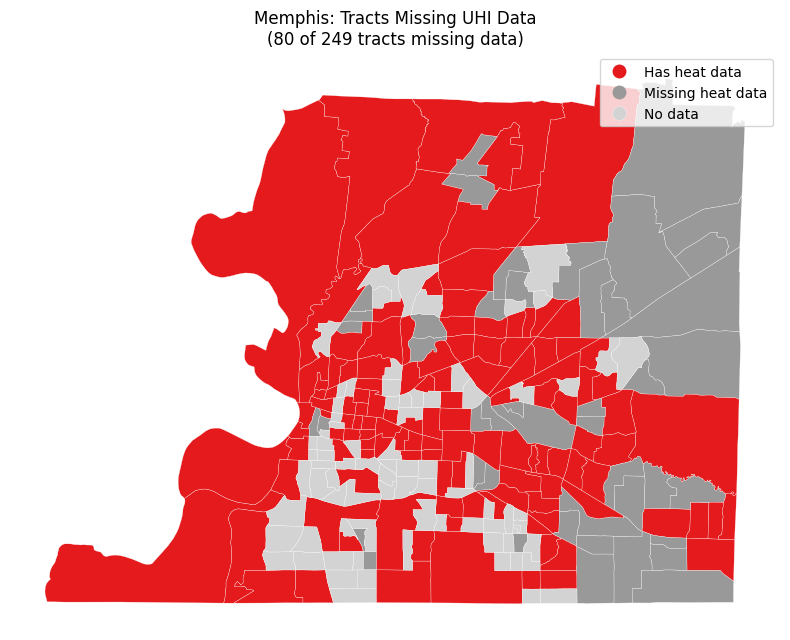

,GEOID,geometry,heat_status
0,47157009700,"POLYGON ((-89.92323 35.07884, -89.92322 35.078...",NaN
1,47157009800,"POLYGON ((-89.90615 35.14876, -89.90614 35.149...",NaN
2,47157021420,"POLYGON ((-89.82395 35.10223, -89.82389 35.104...",Has heat data
3,47157021430,"POLYGON ((-89.84557 35.09932, -89.84547 35.099...",Has heat data
4,47157021754,"POLYGON ((-89.84873 35.01807, -89.84871 35.019...",Has heat data
...,...,...,...
244,47157010120,"POLYGON ((-90.03517 35.18975, -90.03517 35.189...",Has heat data
245,47157003400,"POLYGON ((-90.01328 35.1325, -90.01314 35.1326...",Has heat data
246,47157000100,"POLYGON ((-90.06468 35.1702, -90.06467 35.1711...",Has heat data
247,47157000300,"POLYGON ((-90.03673 35.16405, -90.0364 35.1663...",Has heat data


In [ ]:
# One row per tract: does this tract have a UHI value or not?
heat_missing_by_tract = (
    final_df.groupby('neighborhood')['heat_intensity']
    .apply(lambda s: 'Missing heat data' if s.isna().all() else 'Has heat data')
    .reset_index()
    .rename(columns={'neighborhood': 'GEOID', 'heat_intensity': 'heat_status'})
)

n_missing_tracts = (heat_missing_by_tract['heat_status'] == 'Missing heat data').sum()
print(f"{n_missing_tracts} of {len(heat_missing_by_tract)} tracts have no UHI value at all")

plot_tract_choropleth(
    tracts, heat_missing_by_tract, 'heat_status',
    f'{CITY_NAME}: Tracts Missing UHI Data',
    cmap='Set1', categorical=True
)


---
## Section 11: Column Mapping — Compatibility with Analysis Notebooks 4–12

| Fulton County column | New column | Status |
|---------------------|-----------|--------|
| `Species_Diversity` | `Species_Diversity` | Exact match |
| `Species_Richness` | `Species_Richness` | Exact match |
| `LATITUDE`, `LONGITUDE` | `LATITUDE`, `LONGITUDE` | Exact match |
| `locality_id` (hotspot) | `locality_id` (hotspot) | Exact match |
| All CWM trait columns | All CWM trait columns | Exact match |
| `neighborhood` (NPU name) | `neighborhood` (GEOID) | Renamed (tract ID) |
| `heat_intensity` | `heat_intensity` | Renamed (from Hsu UHI) |
| `canopy_pct` | `canopy_pct` | Renamed (from NLCD) |
| `total_vuln` | `total_vuln` | Renamed (from SVI RPL_THEMES) |
| `NPU` | — | **MISSING** (Atlanta-specific) |
| `ac_prevalence` | — | **MISSING** (not in CDC SVI) |
| `rel_mort_rate` | — | **MISSING** (not in CDC SVI) |
| `avg_max_temp_july` | — | **MISSING** (use PRISM/Daymet or UHI proxy) |
| — | `holc_grade_dominant` | **NEW** |
| — | `holc_score_weighted` | **NEW** |
| — | `pct_holc_a/b/c/d` | **NEW** |
| — | `pct_minority` | **NEW** (from SVI) |

### Handling missing columns in analysis Notebooks 4–12

- **`ac_prevalence`** — Notebook 8 EJ models reference this variable.
  Either (a) use ACS Table B25040 (House Heating Fuel) as a proxy and add it to
  the final CSV before running Notebook 8, or (b) skip the `ac_prevalence` model
  and note the difference from Atlanta.
- **`NPU`** — All notebooks guard against `NPU` with `if 'NPU' in df.columns`.
  No changes needed.
- **`avg_max_temp_july`** — Used for correlation checks only. Leave out or substitute
  `heat_intensity` (they should be highly correlated in any case).

> **No changes are needed to Notebooks 4–12** unless you want to add HOLC grade
> as an additional predictor. See Section 13 for a standalone HOLC analysis.

In [ ]:
required_cols = ['Species_Diversity', 'Species_Richness', 'locality_id',
                  'neighborhood', 'heat_intensity', 'canopy_pct', 'total_vuln']
optional_cols = ['ac_prevalence', 'avg_max_temp_july', 'NPU',
                  'holc_grade_dominant', 'pct_minority']
print("Required columns:")
for col in required_cols:
    print(f"  {'OK' if col in final_df.columns else 'MISSING':6}  {col}")

print("Optional columns:")
for col in optional_cols:
    status = 'present' if col in final_df.columns else 'absent (OK)'
    print(f"  {status:14}  {col}")

print("Column check will run after final_df is assembled in Section 10.")

Required columns:
  OK      Species_Diversity
  OK      Species_Richness
  MISSING  locality_id
  OK      neighborhood
  OK      heat_intensity
  OK      canopy_pct
  OK      total_vuln
Optional columns:
  absent (OK)     ac_prevalence
  absent (OK)     avg_max_temp_july
  absent (OK)     NPU
  present         holc_grade_dominant
  present         pct_minority
Column check will run after final_df is assembled in Section 10.


---
## Section 12: Preliminary Analysis — Canopy × Vulnerability Quadrant

This is the **key figure** for the primary scientific question. Run it before the full
analysis Notebooks 4–12 to see immediately whether your city shows the same
canopy-vulnerability decoupling as Atlanta.

Point colour = mean Shannon bird diversity. Point shape = HOLC grade.
Point size scales with the number of checklists (more reliable tracts are larger).

**What to look for in the upper-right quadrant (high canopy + high vulnerability):**
- In Atlanta this quadrant was predominantly HOLC grade C/D (historically redlined
  Black neighborhoods on the west side) with *high* bird diversity.
- If your city shows the same pattern, ecological resilience was also decoupled from
  human heat resilience, and the historical redlining mechanism is a plausible explanation.

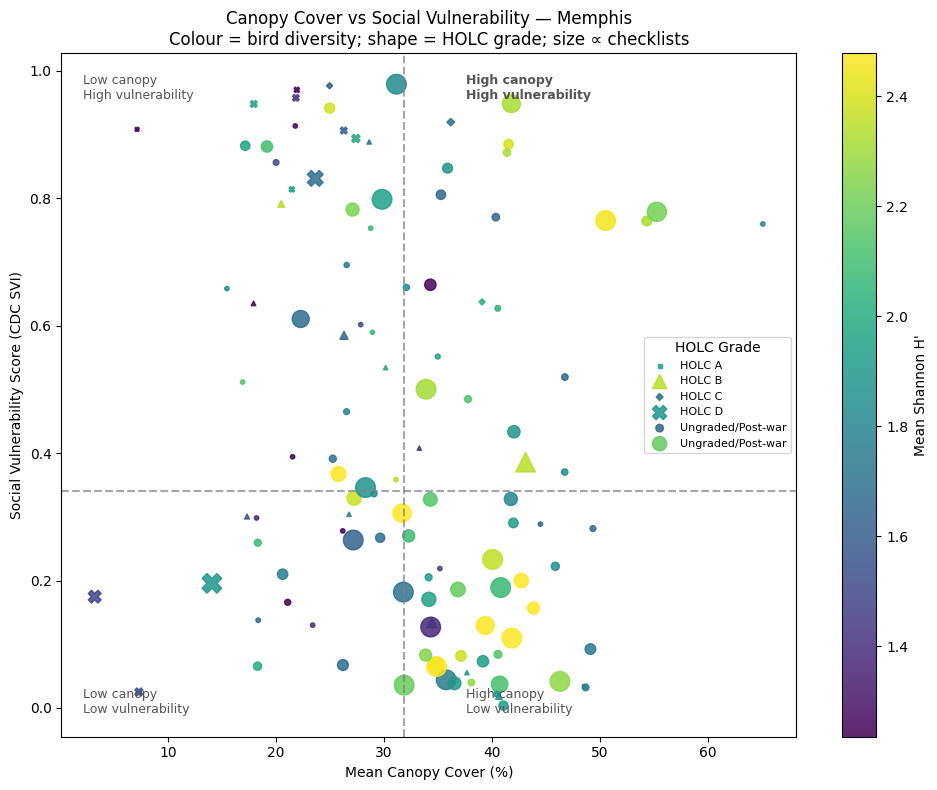


=== UPPER-RIGHT QUADRANT: High canopy + High vulnerability ===
Number of tracts : 23
Mean bird H'     : 1.974
HOLC grades in this quadrant:
holc_grade
C           2
B           2
Ungraded    1

Atlanta: upper-right tracts were predominantly HOLC C/D
(historically redlined) with high diversity but low human resilience.
Does this pattern replicate in Memphis?


In [ ]:
def plot_canopy_vulnerability_quadrant(df, city_name, city_code):
    """Four-quadrant canopy × vulnerability plot coloured by bird diversity."""
    # Aggregate to tract level (minimum 5 checklists for stability)
    tract_summary = df.groupby('neighborhood').agg(
        mean_div    = ('Species_Diversity', 'mean'),
        mean_canopy = ('canopy_pct', 'mean'),
        mean_vuln   = ('total_vuln', 'mean'),
        mean_heat   = ('heat_intensity', 'mean'),
        holc_grade  = ('holc_grade_dominant', 'first'),
        n_checklists= ('Species_Diversity', 'count')
    ).reset_index()
    tract_summary = tract_summary[tract_summary['n_checklists'] >= 5]

    canopy_median = tract_summary['mean_canopy'].median()
    vuln_median   = tract_summary['mean_vuln'].median()

    # Map HOLC grade to marker shape; NaN and 'Ungraded' both get circle
    shape_map = {'A': 's', 'B': '^', 'C': 'D', 'D': 'X', 'Ungraded': 'o'}

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = None
    vmin = tract_summary['mean_div'].quantile(0.05)
    vmax = tract_summary['mean_div'].quantile(0.95)

    for grade, marker in shape_map.items():
        subset = tract_summary[tract_summary['holc_grade'] == grade]
        if len(subset) == 0:
            continue
        sc = ax.scatter(
            subset['mean_canopy'], subset['mean_vuln'],
            c=subset['mean_div'], s=subset['n_checklists'].clip(10, 200),
            marker=marker, cmap='viridis', alpha=0.85,
            vmin=vmin, vmax=vmax,
            label=f'HOLC {grade}' if grade not in ('Ungraded',) else 'Ungraded/Post-war'
        )

    # Handle NaN holc_grade (tracts that didn't intersect HOLC at all)
    nan_mask = tract_summary['holc_grade'].isna()
    if nan_mask.any():
        nan_sub = tract_summary[nan_mask]
        sc = ax.scatter(
            nan_sub['mean_canopy'], nan_sub['mean_vuln'],
            c=nan_sub['mean_div'], s=nan_sub['n_checklists'].clip(10, 200),
            marker='o', cmap='viridis', alpha=0.85, vmin=vmin, vmax=vmax,
            label='Ungraded/Post-war'
        )

    if sc is not None:
        plt.colorbar(sc, ax=ax, label="Mean Shannon H'")

    ax.axvline(canopy_median, linestyle='--', color='grey', alpha=0.7)
    ax.axhline(vuln_median,   linestyle='--', color='grey', alpha=0.7)

    # Quadrant labels using axis-relative coordinates
    kw = dict(size=9, color='#555555', transform=ax.transAxes)
    ax.text(0.03, 0.97, 'Low canopy\nHigh vulnerability',  va='top', **kw)
    ax.text(0.55, 0.97, 'High canopy\nHigh vulnerability', va='top',
            fontweight='bold', **kw)   # KEY QUADRANT
    ax.text(0.03, 0.03, 'Low canopy\nLow vulnerability',   va='bottom', **kw)
    ax.text(0.55, 0.03, 'High canopy\nLow vulnerability',  va='bottom', **kw)

    ax.legend(title='HOLC Grade', loc='center right', fontsize=8)
    ax.set_xlabel('Mean Canopy Cover (%)')
    ax.set_ylabel('Social Vulnerability Score (CDC SVI)')
    ax.set_title(f'Canopy Cover vs Social Vulnerability \u2014 {city_name}\n'
                 f'Colour = bird diversity; shape = HOLC grade; size \u221d checklists')
    plt.tight_layout()
    plt.savefig(f'fig_quadrant_{city_code}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Report key quadrant
    upper_right = tract_summary[
        (tract_summary['mean_canopy'] >= canopy_median) &
        (tract_summary['mean_vuln']   >= vuln_median)
    ]
    print("\n=== UPPER-RIGHT QUADRANT: High canopy + High vulnerability ===")
    print(f"Number of tracts : {len(upper_right)}")
    print(f"Mean bird H'     : {upper_right['mean_div'].mean():.3f}")
    print("HOLC grades in this quadrant:")
    print(upper_right['holc_grade'].value_counts().to_string())
    print()
    print("Atlanta: upper-right tracts were predominantly HOLC C/D")
    print("(historically redlined) with high diversity but low human resilience.")
    print(f"Does this pattern replicate in {city_name}?")
    return tract_summary

# Run after final_df is assembled:
tract_summary = plot_canopy_vulnerability_quadrant(final_df, CITY_NAME, CITY_CODE)

---
## Section 13: HOLC-Specific Analysis

Tests whether the historical redlining gradient (HOLC grade A → D) predicts
present-day canopy cover, social vulnerability, UHI intensity, and bird diversity.

**Three hypotheses tested:**
1. Lower HOLC grade (C/D) → less present-day canopy (canopy-redlining coupling)
2. Lower HOLC grade → higher present-day social vulnerability
3. Bird diversity follows canopy, not HOLC grade directly (ecological mechanism is
   canopy, not a direct legacy effect)

The Spearman correlations use HOLC numeric score (A=4, B=3, C=2, D=1) as a
continuous predictor — larger values = historically "better" grade.

**Collinearity caveat:** Because HOLC score, canopy, and heat are all correlated
(lower HOLC grade → less canopy → more heat), the bivariate Spearman correlations
cannot isolate HOLC's unique contribution. If both `holc_score vs canopy` (r > 0)
and `holc_score vs heat` (r < 0) are significant, run a multiple regression to
estimate HOLC's partial correlation with bird diversity controlling for canopy
and heat (use OLS from statsmodels). A significant partial correlation of HOLC
with diversity — after controlling for canopy — would imply a direct legacy effect
beyond the canopy pathway.

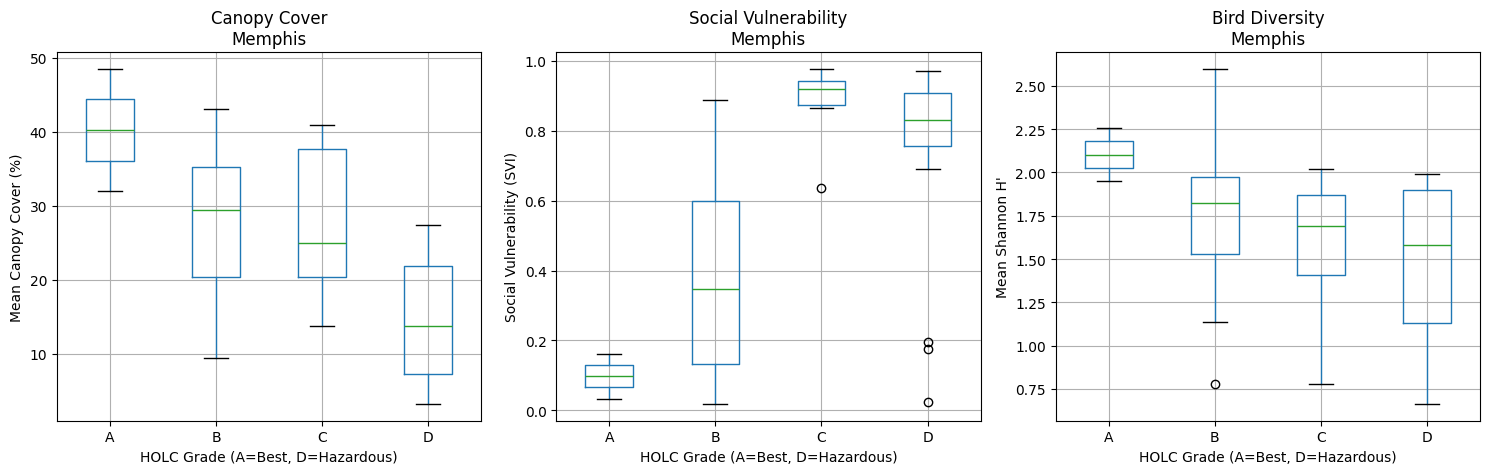


=== HOLC Grade Spearman Correlations (bivariate) — Memphis ===
(HOLC score: A=4 → D=1; larger score = historically 'better' grade)
  vs Canopy cover          : r=+0.682  p=0.000 ***  (↑ higher grade → more)
  vs Social vulnerability  : r=-0.495  p=0.001 **  (↓ lower grade → more)
  vs Heat intensity        : r=+0.599  p=0.000 ***  (↑ higher grade → more)
  vs Bird diversity        : r=+0.301  p=0.056 ns  (↑ higher grade → more)

Partial OLS (diversity ~ HOLC + canopy + heat):
  HOLC score partial beta = +0.0851, p = 0.468 ns
  Significant HOLC partial beta → direct legacy effect beyond canopy.
  ns HOLC partial beta → HOLC effect is fully mediated by canopy.

Interpretation:
  Expected: canopy r>0 (better grade = more canopy)
  Expected: vuln r<0 (worse grade = more vulnerable)
  Key question: does diversity follow canopy (mediated) or HOLC (direct)?


In [ ]:
from scipy.stats import spearmanr
import statsmodels.api as sm

def holc_analysis(df, city_name, city_code):
    """Box plots and Spearman correlations of HOLC grade vs present-day outcomes."""
    tract_df = df.groupby('neighborhood').agg(
        mean_div    = ('Species_Diversity', 'mean'),
        mean_canopy = ('canopy_pct', 'mean'),
        mean_vuln   = ('total_vuln', 'mean'),
        mean_heat   = ('heat_intensity', 'mean'),
        holc_grade  = ('holc_grade_dominant', 'first'),
        holc_score  = ('holc_score_weighted', 'mean'),
        n_checklists= ('Species_Diversity', 'count')
    ).reset_index()

    graded = tract_df[tract_df['holc_grade'].isin(['A','B','C','D'])].copy()
    graded['holc_grade'] = pd.Categorical(graded['holc_grade'],
                                           categories=['A','B','C','D'], ordered=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    outcomes = [
        ('mean_canopy', 'Mean Canopy Cover (%)',       'Canopy Cover'),
        ('mean_vuln',   'Social Vulnerability (SVI)',  'Social Vulnerability'),
        ("mean_div",    "Mean Shannon H'",              'Bird Diversity'),
    ]
    for ax, (col, ylabel, title) in zip(axes, outcomes):
        graded.boxplot(column=col, by='holc_grade', ax=ax)
        ax.set_title(f'{title}\n{city_name}')
        ax.set_xlabel('HOLC Grade (A=Best, D=Hazardous)')
        ax.set_ylabel(ylabel)
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig(f'fig_holc_outcomes_{city_code}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Bivariate Spearman correlations
    print(f"\n=== HOLC Grade Spearman Correlations (bivariate) \u2014 {city_name} ===")
    print("(HOLC score: A=4 \u2192 D=1; larger score = historically 'better' grade)")
    for col, label in [('mean_canopy', 'Canopy cover'),
                       ('mean_vuln',   'Social vulnerability'),
                       ('mean_heat',   'Heat intensity'),
                       ('mean_div',    'Bird diversity')]:
        valid = graded[['holc_score', col]].dropna()
        r, p = spearmanr(valid['holc_score'], valid[col])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        direction = '\u2191 higher grade \u2192 more' if r > 0 else '\u2193 lower grade \u2192 more'
        print(f"  vs {label:<22}: r={r:+.3f}  p={p:.3f} {sig}  ({direction})")

    # Partial correlation: does HOLC predict diversity beyond canopy + heat?
    partial_vars = ['holc_score', 'mean_canopy', 'mean_heat', 'mean_div']
    partial_df = graded[partial_vars].dropna()
    if len(partial_df) >= 10:
        X = sm.add_constant(partial_df[['holc_score','mean_canopy','mean_heat']])
        y = partial_df['mean_div']
        ols = sm.OLS(y, X).fit()
        b_holc = ols.params['holc_score']
        p_holc = ols.pvalues['holc_score']
        sig_p  = '***' if p_holc < 0.001 else '**' if p_holc < 0.01 else '*' if p_holc < 0.05 else 'ns'
        print(f"\nPartial OLS (diversity ~ HOLC + canopy + heat):")
        print(f"  HOLC score partial beta = {b_holc:+.4f}, p = {p_holc:.3f} {sig_p}")
        print(f"  Significant HOLC partial beta \u2192 direct legacy effect beyond canopy.")
        print(f"  ns HOLC partial beta \u2192 HOLC effect is fully mediated by canopy.")

    print("\nInterpretation:")
    print("  Expected: canopy r>0 (better grade = more canopy)")
    print("  Expected: vuln r<0 (worse grade = more vulnerable)")
    print("  Key question: does diversity follow canopy (mediated) or HOLC (direct)?")
    return graded

# Run after final_df is assembled:
graded_summary = holc_analysis(final_df, CITY_NAME, CITY_CODE)

---
## Try It Yourself

1. **Add a second city.** Once you have results for one city, request eBird data for a
   second city from a different climate zone (e.g., Atlanta in the South vs Detroit in the
   Midwest). Does the canopy-diversity relationship strengthen, weaken, or reverse?

2. **Extend Atlanta.** Run this notebook for DeKalb County (`US-GA-089`) using the same
   date range as Fulton. DeKalb is adjacent and has a mix of suburban and forested tracts.
   Does the west-side pattern extend across the county line?

3. **HOLC and canopy over time.** NLCD provides canopy cover for 2016 and 2021.
   Download both years and calculate the change in canopy per tract. Do HOLC D tracts
   show greater canopy loss over the five-year period?

4. **Migration decoupling.** The Atlanta analysis found more migratory species in hotter
   neighborhoods in winter (OR = 2.31). Does your city show the same pattern?
   Run Notebook 7's migration model on your city's data.

---
## Sign-off Table

Complete as each data source is obtained and verified.

| Data Source | Downloaded | Tracts matched | Sign-off | Date |
|-------------|-----------|----------------|----------|------|
| eBird EBD (approved) | | | | |
| Census tract boundaries | | | | |
| CDC SVI | | | | |
| Hsu et al. UHI data | | | | |
| NLCD 2021 Tree Canopy | | | | |
| Mapping Inequality HOLC | | | | |
| Final joined CSV | | | | |
| Notebook 4 runs clean | | | | |
| Quadrant figure (Section 12) | | | | |
| HOLC analysis (Section 13) | | | | |
| Atlanta comparison (Section 14) | | | | |

---
**Next:** Open Notebook 4 (`Notebook_4_data_cleaning_eda.ipynb`) and change the
`DATA_FILE` variable at the top to point to your new `heat_traits_{CITY_CODE}.csv`.
All analysis notebooks (4–12) will then run on your city's data.

---
# PART 4: Effort-Safe Response Variables + Single-Variable Analysis

Turns Part 3's checklist-level output into one clean tract-level table:
effort-adjusted Shannon diversity, a minimum-checklist floor, and mean CWM
mass/brightness — then a reusable stats + scatter + map template for
exploring predictor × response pairs.

**Why this comes after Part 3, not folded into it:** a raw plot of canopy
vs. species richness partly just measures which tracts got the longest
checklists, not an ecological signal. This part fixes that *in the response
variable itself*, before any single-variable exploration starts.

**Uses from Part 0:** `CHECKLIST_FILE` (= `OUTPUT_FILE`), `TRACTS_FILE`
(= `TRACTS_OUTPUT_PATH`), `MIN_CHECKLISTS_PER_TRACT`. Also reuses `tracts`
(the GeoDataFrame) directly from Part 3 -- already in memory, no re-download needed.

---
## Section 2: Load the checklist-level data

In [ ]:
df = pd.read_csv(CHECKLIST_FILE, low_memory=False)

# Standardize column names: Notebook 13 uses dot-separated / renamed columns
# that differ from the old Notebooks 3-4 naming convention this notebook was
# originally written against -- reconcile them here so nothing below needs
# to change.
df = df.rename(columns={
    'SAMPLING.EVENT.IDENTIFIER': 'SAMPLING EVENT IDENTIFIER',
    'LOCALITY ID':                'locality_id',
    'DURATION MINUTES':           'duration_min',
    'EFFORT DISTANCE KM':         'distance_km',
    'PROTOCOL NAME':              'protocol',
})

missing_effort = [c for c in ['duration_min'] if c not in df.columns]
if missing_effort:
    raise ValueError(
        f"Missing effort column(s): {missing_effort}. "
        "Re-run the patched Notebook 1 export cell (Section 8) so effort "
        "fields flow through Notebook 13's spatial join into this file."
    )

print(f"{len(df):,} checklists loaded for {CITY_NAME}")
print(f"{df['locality_id'].nunique()} localities | {df['neighborhood'].nunique()} tracts")
print(df[['Species_Diversity', 'duration_min', 'distance_km']].describe().round(2))


19,621 checklists loaded for Memphis
1440 localities | 169 tracts
       Species_Diversity  duration_min  distance_km
count           19621.00      19621.00     12636.00
mean                2.06         46.25         1.75
std                 0.71         41.50         1.73
min                 0.00          5.00         0.00
25%                 1.62         15.00         0.49
50%                 2.12         32.00         1.21
75%                 2.56         62.00         2.41
max                 4.04        240.00        10.00


---
## Section 3: Why effort matters — see it before you fix it

Before correcting anything, look at the actual relationship in your city's
data between checklist duration and raw diversity. This is the plot to put
in front of students *first* — the fix in Section 4 only makes sense once
they've seen the problem it's solving.

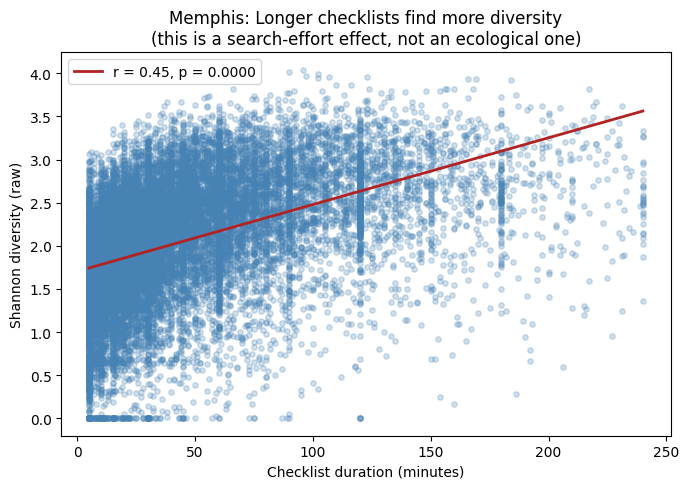

Duration explains 20.4% of the variance in raw Shannon diversity.
That variance has nothing to do with heat, canopy, or any environmental
variable -- it needs to come OUT of the response variable before any
single-variable analysis, or every scatter plot downstream partly just
re-plots this relationship.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['duration_min'], df['Species_Diversity'], alpha=0.25, s=15, color='steelblue')

# Fit a simple trend line to make the relationship impossible to miss
valid = df.dropna(subset=['duration_min', 'Species_Diversity'])
slope, intercept, r, p, se = stats.linregress(valid['duration_min'], valid['Species_Diversity'])
x_line = np.linspace(valid['duration_min'].min(), valid['duration_min'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='firebrick', linewidth=2,
        label=f"r = {r:.2f}, p = {p:.4f}")

ax.set_xlabel('Checklist duration (minutes)')
ax.set_ylabel("Shannon diversity (raw)")
ax.set_title(f'{CITY_NAME}: Longer checklists find more diversity\n'
             '(this is a search-effort effect, not an ecological one)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Duration explains {r**2*100:.1f}% of the variance in raw Shannon diversity.")
print("That variance has nothing to do with heat, canopy, or any environmental")
print("variable -- it needs to come OUT of the response variable before any")
print("single-variable analysis, or every scatter plot downstream partly just")
print("re-plots this relationship.")


---
## Section 4: Effort-adjust Shannon diversity

**Method:** regress raw diversity on effort (log-duration, plus distance
where available), then use the *residuals* — the part of each checklist's
diversity that duration and distance don't explain. A checklist that logged
more species than expected for a 15-minute walk gets a positive residual; one
that logged fewer than expected gets a negative one. Averaged up to the
tract level, this becomes "biodiversity relative to how hard people looked,"
which is the number you actually want to compare against canopy, heat, etc.

This is standard practice in eBird-based analyses (effort covariates are
built into eBird's own recommended modeling approach) — we're just doing the
simplest version of it, a residual, instead of carrying duration as a
covariate through every later model.

In [ ]:
# log-transform duration (diminishing returns: the 10th minute finds fewer
# new species than the 1st) -- standard eBird effort-modeling practice
df['log_duration'] = np.log(df['duration_min'].clip(lower=1))

# distance is NaN for stationary counts -- fill with 0 and add a flag,
# rather than dropping those checklists
df['distance_km_filled'] = df['distance_km'].fillna(0)
df['is_stationary'] = df['distance_km'].isna().astype(int)

effort_data = df.dropna(subset=['Species_Diversity', 'log_duration']).copy()

slope_d, slope_dist, slope_stat, intercept = None, None, None, None
X = effort_data[['log_duration', 'distance_km_filled', 'is_stationary']].values
X = np.column_stack([np.ones(len(X)), X])
y = effort_data['Species_Diversity'].values
coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
predicted = X @ coefs
residuals = y - predicted

effort_data['effort_adj_diversity'] = residuals

print("Effort model coefficients:")
print(f"  log(duration):     {coefs[1]:+.4f}  (more time -> higher predicted diversity)")
print(f"  distance (km):     {coefs[2]:+.4f}")
print(f"  stationary flag:   {coefs[3]:+.4f}")
print()
print(f"Effort-adjusted diversity: mean={residuals.mean():.4f} (should be ~0), "
      f"sd={residuals.std():.4f}")

df = df.merge(
    effort_data[['SAMPLING EVENT IDENTIFIER', 'effort_adj_diversity']],
    on='SAMPLING EVENT IDENTIFIER', how='left'
)


Effort model coefficients:
  log(duration):     +0.3798  (more time -> higher predicted diversity)
  distance (km):     -0.0134
  stationary flag:   -0.1251

Effort-adjusted diversity: mean=0.0000 (should be ~0), sd=0.6035


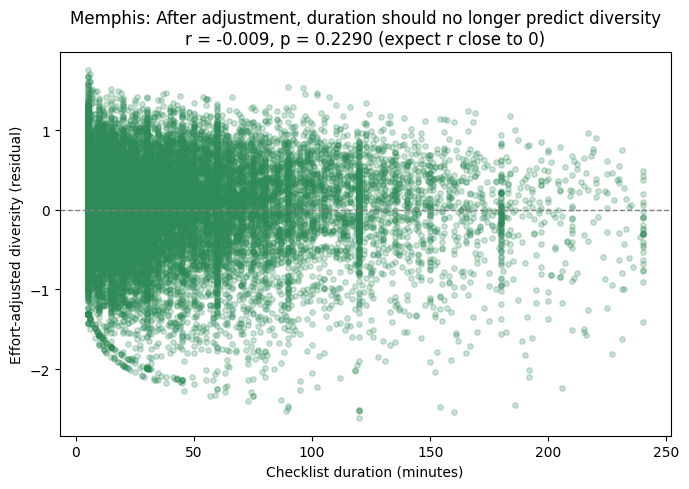

Good -- effort is no longer predicting the response variable.


In [ ]:
# Confirm the fix worked: effort-adjusted diversity should show ~no
# relationship with duration, unlike the raw version in Section 3
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['duration_min'], df['effort_adj_diversity'], alpha=0.25, s=15, color='seagreen')
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

valid2 = df.dropna(subset=['duration_min', 'effort_adj_diversity'])
r2, p2 = stats.pearsonr(valid2['duration_min'], valid2['effort_adj_diversity'])

ax.set_xlabel('Checklist duration (minutes)')
ax.set_ylabel('Effort-adjusted diversity (residual)')
ax.set_title(f'{CITY_NAME}: After adjustment, duration should no longer predict diversity\n'
             f'r = {r2:.3f}, p = {p2:.4f} (expect r close to 0)')
plt.tight_layout()
plt.show()

if abs(r2) > 0.1:
    print("WARNING: residual correlation with duration is still noticeable.")
    print("Check for outlier checklists (very long duration, very high count)")
    print("before trusting effort_adj_diversity.")
else:
    print("Good -- effort is no longer predicting the response variable.")


---
## Section 5: Minimum checklists per tract

Now zoom out from individual checklists to tracts. Some tracts will have
dozens of checklists; others will have one or two. A tract's mean based on 2
checklists is not comparable in reliability to one based on 60 — but a
simple `groupby().mean()` treats them identically.

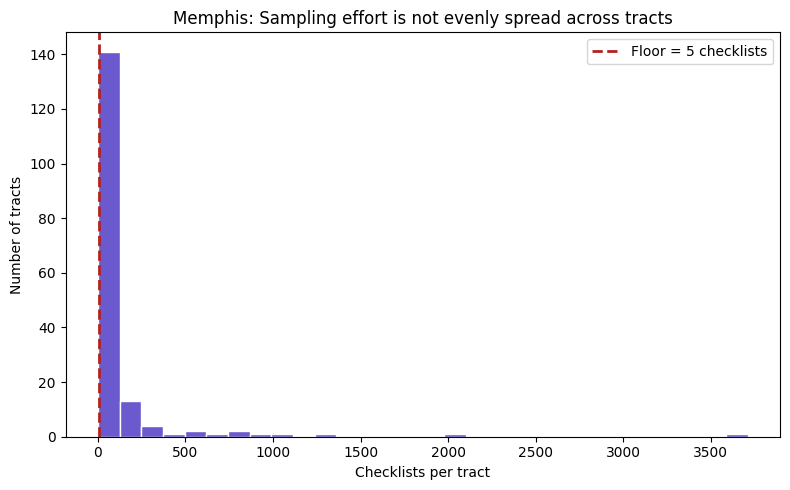

47 of 169 tracts have fewer than 5 checklists and will be excluded.
Tracts remaining: 122


In [ ]:
checklists_per_tract = (
    df.groupby('neighborhood')['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .reset_index(name='n_checklists')
    .sort_values('n_checklists')
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(checklists_per_tract['n_checklists'], bins=30, color='slateblue', edgecolor='white')
ax.axvline(MIN_CHECKLISTS_PER_TRACT, color='firebrick', linewidth=2, linestyle='--',
           label=f'Floor = {MIN_CHECKLISTS_PER_TRACT} checklists')
ax.set_xlabel('Checklists per tract')
ax.set_ylabel('Number of tracts')
ax.set_title(f'{CITY_NAME}: Sampling effort is not evenly spread across tracts')
ax.legend()
plt.tight_layout()
plt.show()

n_total_tracts = len(checklists_per_tract)
n_dropped = (checklists_per_tract['n_checklists'] < MIN_CHECKLISTS_PER_TRACT).sum()
print(f"{n_dropped} of {n_total_tracts} tracts have fewer than "
      f"{MIN_CHECKLISTS_PER_TRACT} checklists and will be excluded.")
print(f"Tracts remaining: {n_total_tracts - n_dropped}")

keep_tracts = checklists_per_tract[
    checklists_per_tract['n_checklists'] >= MIN_CHECKLISTS_PER_TRACT
]['neighborhood']


---
## Section 6: Aggregate to tract level

One row per tract, for the three response variables the class is focusing
on: **Shannon diversity (effort-adjusted)**, **body mass (CWM)**, and
**plumage brightness (CWM)** — the last one only if your city has run
Notebook 12 already.

In [ ]:
agg_dict = {
    'effort_adj_diversity': 'mean',
    'Species_Diversity':    'mean',   # raw, kept for comparison/discussion only
    'SAMPLING EVENT IDENTIFIER': 'nunique',
}
if 'Mass_wmean' in df.columns:
    agg_dict['Mass_wmean'] = 'mean'
else:
    print("Mass_wmean not found in this file -- check Part 2's CWM export for this city.")

if 'cwm_brightness_overall' in df.columns:
    agg_dict['cwm_brightness_overall'] = 'mean'
else:
    print("cwm_brightness_overall not found -- run Part 3's plumage brightness "
          "section (needs mmc2.xlsx) if you want this response variable.")

tract_df = (
    df[df['neighborhood'].isin(keep_tracts)]
    .groupby('neighborhood')
    .agg(agg_dict)
    .rename(columns={'SAMPLING EVENT IDENTIFIER': 'n_checklists',
                      'effort_adj_diversity': 'diversity_effort_adj',
                      'Species_Diversity': 'diversity_raw',
                      'Mass_wmean': 'mean_mass',
                      'cwm_brightness_overall': 'mean_brightness'})
    .reset_index()
)

print(f"Tract-level table: {len(tract_df)} tracts, all with >= {MIN_CHECKLISTS_PER_TRACT} checklists")
tract_df.head()

Tract-level table: 122 tracts, all with >= 5 checklists


,neighborhood,diversity_effort_adj,diversity_raw,n_checklists,mean_mass,mean_brightness
0,4.715700e+10,-0.185631,1.884827,220,267.917704,58.451604
1,4.715700e+10,-0.075125,1.972204,25,91.689219,57.823906
2,4.715700e+10,-0.048194,1.414970,23,282.890408,58.147526
3,4.715700e+10,-0.427589,1.116342,16,1757.546586,56.502813
4,4.715700e+10,-0.080574,1.941915,16,142.347126,58.974818


In [ ]:
# Plumage brightness is already folded into tract_df above (Section 6) --
# no separate file or merge needed now that Notebook 13 computes it directly
# alongside diversity and mass. This cell is intentionally left as a no-op
# placeholder in case a future data source needs the same "optional bonus,
# skip gracefully" pattern the earlier version of this cell used.
pass


---
## Section 7: Attach the environmental predictors

Notebook 13's `assemble_final_dataset()` already merged UHI, SVI, canopy,
VIIRS, and HOLC onto every checklist row (that's what "final_df" means in
Notebook 13) -- so there's no second file to load or merge here. Each tract's
environmental values are just duplicated across every checklist in that
tract; we pull one copy per tract and attach it to the aggregated response
variables from Section 6.

In [ ]:
env_cols = ['neighborhood', 'heat_intensity', 'canopy_pct', 'total_vuln',
            'light_radiance', 'holc_grade_dominant']
env_cols = [c for c in env_cols if c in df.columns]
missing_env = set(['heat_intensity', 'canopy_pct', 'total_vuln',
                    'light_radiance', 'holc_grade_dominant']) - set(env_cols)
if missing_env:
    print(f"Note: these environmental columns weren't found and will be skipped: {missing_env}")
    print("(Check that Notebook 13's assemble_final_dataset() call includes all five layers.)")

tract_env_lookup = df[env_cols].drop_duplicates(subset='neighborhood')

final_df = tract_df.merge(tract_env_lookup, on='neighborhood', how='left')
final_df = final_df.rename(columns={'neighborhood': 'GEOID'})

match_rate = final_df['heat_intensity'].notna().mean() if 'heat_intensity' in final_df.columns else np.nan
if not np.isnan(match_rate):
    print(f"Tracts matched to environmental data: {final_df['heat_intensity'].notna().sum()} "
          f"of {len(final_df)} ({match_rate*100:.0f}%)")
    if match_rate < 0.8:
        print()
        print("WARNING: match rate is low -- check Notebook 13's tract GEOID formatting.")


Tracts matched to environmental data: 91 of 122 (75%)



In [ ]:
out_path = SINGLE_VAR_OUTPUT_FILE  # was a hardcoded, non-city-specific path
final_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"{len(final_df)} tracts x {final_df.shape[1]} columns")
print()
print("Response variables ready for single-variable analysis:")
for col in ['diversity_effort_adj', 'mean_mass', 'mean_brightness']:
    if col in final_df.columns:
        n_valid = final_df[col].notna().sum()
        print(f"  {col:22s}: {n_valid} tracts with data")


Saved: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/single_variable_tract_data_memphis.csv
122 tracts x 11 columns

Response variables ready for single-variable analysis:
  diversity_effort_adj  : 122 tracts with data
  mean_mass             : 122 tracts with data
  mean_brightness       : 122 tracts with data


---
## Section 8: Single-variable analysis template

One function, reused for every predictor × response pair: correlation stat,
scatter with trend line, and side-by-side maps of the predictor and the
response, so a spatial pattern (or the lack of one) is visible directly,
not just inferred from a correlation coefficient. Uses Spearman by default
since these environmental/biological variables are often not normally
distributed — resistant to outlier tracts skewing the story.

In [ ]:
def single_variable_analysis(gdf, predictor_col, response_col,
                              predictor_label=None, response_label=None,
                              predictor_cmap='inferno', response_cmap='viridis'):
    """Stats + scatter + two maps for one predictor-response pair.

    gdf must have both columns plus a 'geometry' column (merge final_df onto
    your tracts GeoDataFrame from Notebook 13 before calling this).
    """
    predictor_label = predictor_label or predictor_col
    response_label  = response_label or response_col

    sub = gdf.dropna(subset=[predictor_col, response_col])
    rho, p = stats.spearmanr(sub[predictor_col], sub[response_col])

    print(f"{predictor_label} vs {response_label}")
    print(f"  Spearman rho = {rho:.3f}, p = {p:.4f}, n = {len(sub)} tracts")
    if p < 0.05:
        direction = "increases" if rho > 0 else "decreases"
        print(f"  --> {response_label} significantly {direction} with {predictor_label}")
    else:
        print(f"  --> No significant relationship at n = {len(sub)} tracts")

    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])

    # Panel 1: scatter
    ax0 = fig.add_subplot(gs[0])
    ax0.scatter(sub[predictor_col], sub[response_col], alpha=0.6, s=40, color='darkslateblue')
    z = np.polyfit(sub[predictor_col], sub[response_col], 1)
    x_line = np.linspace(sub[predictor_col].min(), sub[predictor_col].max(), 50)
    ax0.plot(x_line, np.poly1d(z)(x_line), color='firebrick', linewidth=2)
    ax0.set_xlabel(predictor_label)
    ax0.set_ylabel(response_label)
    ax0.set_title(f'rho = {rho:.2f}, p = {p:.3f}')

    # Panel 2: predictor map
    ax1 = fig.add_subplot(gs[1])
    gdf.plot(column=predictor_col, ax=ax1, cmap=predictor_cmap, edgecolor='white',
              linewidth=0.15, legend=True, missing_kwds={'color': 'lightgrey'})
    ax1.set_title(predictor_label, fontsize=11)
    ax1.axis('off')

    # Panel 3: response map
    ax2 = fig.add_subplot(gs[2])
    gdf.plot(column=response_col, ax=ax2, cmap=response_cmap, edgecolor='white',
              linewidth=0.15, legend=True, missing_kwds={'color': 'lightgrey'})
    ax2.set_title(response_label, fontsize=11)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()
    return {'rho': rho, 'p': p, 'n': len(sub)}


### 8a. Attach tract geometry and run one example

`tracts` already exists in memory from Part 3 -- no re-download or file
reload needed here (that self-healing logic mattered when this was a
separate notebook/session; it isn't, anymore). Just merge it with `final_df`.

In [ ]:
if 'tracts' not in dir():
    raise NameError(
        "`tracts` isn't defined -- re-run Part 3, Section 4 "
        "(download_census_tracts) before this cell."
    )

def normalize_geoid(series):
    """Coerce a GEOID column to clean, zero-padded 11-digit strings.

    Handles the two most common corruptions: a float round-trip through
    CSV turning '17031670500' into 170316705.0 -> '170316705.0' when
    stringified, and a dropped leading zero when the column was ever read
    as an int/float instead of a string.
    """
    s = series.astype(str).str.replace(r'\.0$', '', regex=True)
    return s.str.zfill(11)

tracts['GEOID']   = normalize_geoid(tracts['GEOID'])
final_df['GEOID'] = normalize_geoid(final_df['GEOID'])

print("tracts GEOID sample  :", tracts['GEOID'].head(3).tolist())
print("final_df GEOID sample:", final_df['GEOID'].head(3).tolist())

gdf = tracts[['GEOID', 'geometry']].merge(final_df, on='GEOID', how='inner')
print(f"{len(gdf)} tracts ready to map (of {len(final_df)} in the response table)")

if len(gdf) == 0:
    print()
    print("Still 0 matches -- compare the two GEOID samples printed above.")
    print("Same length and same leading digits? If not, this final_df wasn't")
    print("built from this same city's tracts (check CITY_CODE / OUTPUT_FILE).")

tracts GEOID sample  : ['47157009700', '47157009800', '47157021420']
final_df GEOID sample: ['47157000100', '47157000200', '47157000300']
122 tracts ready to map (of 122 in the response table)


Tree canopy cover (%) vs Shannon diversity (effort-adjusted)
  Spearman rho = 0.364, p = 0.0000, n = 122 tracts
  --> Shannon diversity (effort-adjusted) significantly increases with Tree canopy cover (%)


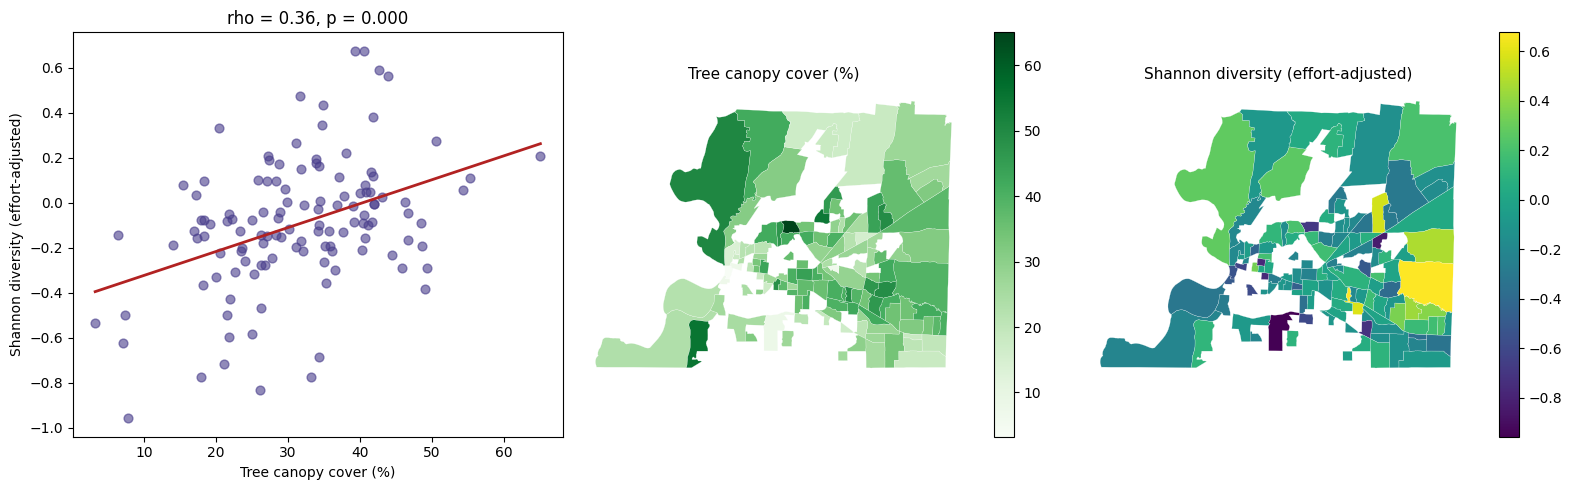

In [ ]:
# Example: canopy cover vs effort-adjusted diversity
_ = single_variable_analysis(
    gdf, predictor_col='canopy_pct', response_col='diversity_effort_adj',
    predictor_label='Tree canopy cover (%)', response_label="Shannon diversity (effort-adjusted)",
    predictor_cmap='Greens', response_cmap='viridis'
)


---
## Section 9: What to actually run today

Five predictors (UHI, SVI, canopy, VIIRS light pollution, HOLC grade) times
three responses (diversity, mass, brightness) is 15 combinations — too many
for one poster. Pick a **subset with a clear biological
rationale** rather than running all 15 and seeing what's significant (that's
p-hacking). A reasonable
starting set for a first pass:

| Predictor | Response | Why this pairing |
|---|---|---|
| Canopy cover | Diversity | Classic habitat-structure hypothesis |
| UHI | Diversity | Your core research question |
| UHI | Body mass | Bergmann's-rule-style thermal prediction |
| VIIRS light | Brightness | Plumage visibility under artificial light |
| HOLC grade | Diversity | Legacy-effect test (categorical predictor — use
  a boxplot by grade instead of a scatter) |

Everything else is a good "if time allows" extension

---
## Try It Yourself

 **HOLC as categorical:** HOLC grade isn't continuous, so Spearman/scatter
   don't quite fit. Try a boxplot of `diversity_effort_adj` grouped by
   `holc_grade_dominant` instead, with a Kruskal-Wallis test.

**Next** once everyone has run their chosen pairs, combine everyone's
`rho`/`p` results into one shared table for the group discussion — that's
the bridge from single-variable intuition to the larger multi-predictor
model.

SAVE YOUR COMPILED DATA

In [ ]:
if 'tracts' not in dir():
    raise NameError(
        "`tracts` isn't defined -- re-run Part 3, Section 4 "
        "(download_census_tracts) before this cell."
    )

def normalize_geoid(series):
    """Coerce a GEOID column to clean, zero-padded 11-digit strings.

    Handles the two most common corruptions: a float round-trip through
    CSV turning '17031670500' into 170316705.0 -> '170316705.0' when
    stringified, and a dropped leading zero when the column was ever read
    as an int/float instead of a string.
    """
    s = series.astype(str).str.replace(r'\.0$', '', regex=True)
    return s.str.zfill(11)

tracts['GEOID']   = normalize_geoid(tracts['GEOID'])
final_df['GEOID'] = normalize_geoid(final_df['GEOID'])

print("tracts GEOID sample  :", tracts['GEOID'].head(3).tolist())
print("final_df GEOID sample:", final_df['GEOID'].head(3).tolist())

gdf = tracts[['GEOID', 'geometry']].merge(final_df, on='GEOID', how='inner')
print(f"{len(gdf)} tracts ready to map (of {len(final_df)} in the response table)")

if len(gdf) == 0:
    print()
    print("Still 0 matches -- compare the two GEOID samples printed above.")
    print("Same length and same leading digits? If not, this final_df wasn't")
    print("built from this same city's tracts (check CITY_CODE / OUTPUT_FILE).")

GDF_OUTPUT_PATH = OUTPUT_DIR + f'{CITY_CODE}_full_model_data.geojson'
gdf.to_file(GDF_OUTPUT_PATH, driver='GeoJSON')
print(f"Saved: {GDF_OUTPUT_PATH}")
print("Next time, skip Parts 1-4 entirely and just run:")
print(f"  gdf = gpd.read_file('{GDF_OUTPUT_PATH}')")

tracts GEOID sample  : ['47157009700', '47157009800', '47157021420']
final_df GEOID sample: ['47157000100', '47157000200', '47157000300']
122 tracts ready to map (of 122 in the response table)
Saved: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/memphis_full_model_data.geojson
Next time, skip Parts 1-4 entirely and just run:
  gdf = gpd.read_file('/content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/memphis_full_model_data.geojson')


other shit

Heat Intensity(%) vs Body Mass
  Spearman rho = -0.132, p = 0.2115, n = 91 tracts
  --> No significant relationship at n = 91 tracts


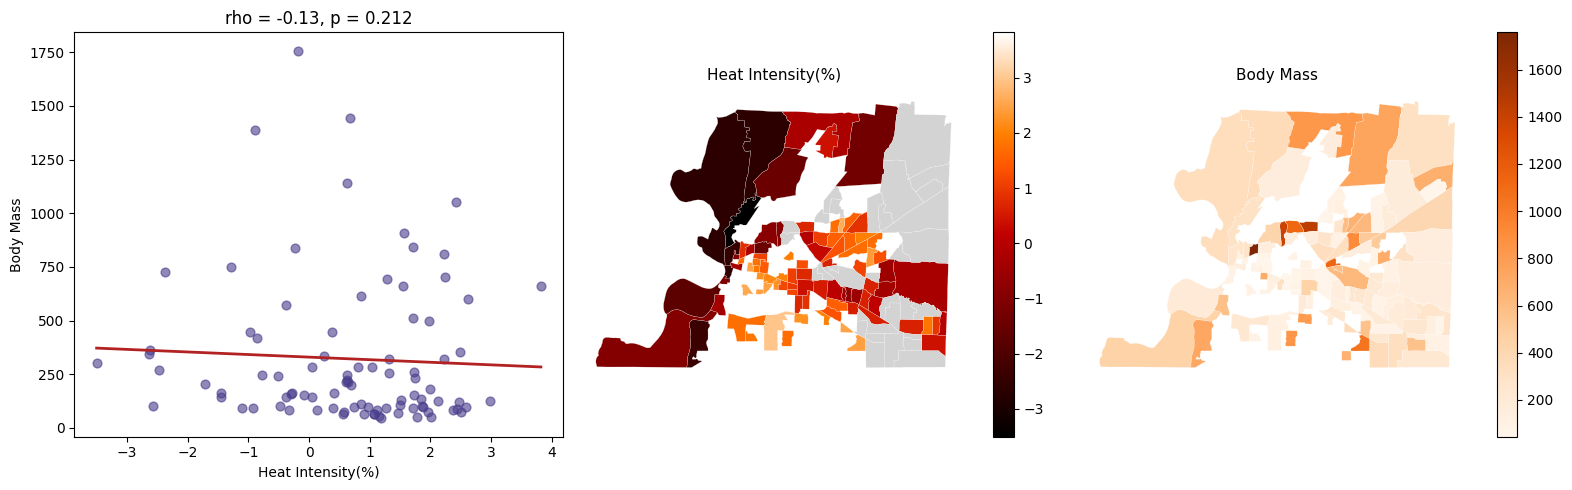

In [ ]:
#heat and diversity

# Example: canopy cover vs effort-adjusted diversity
_ = single_variable_analysis(
    gdf, predictor_col='heat_intensity', response_col='mean_mass',
    predictor_label='Heat Intensity(%)', response_label="Body Mass",
    predictor_cmap='gist_heat', response_cmap='Oranges'
)

Light Radiance(%) vs Plumage Brightness (effort-adjusted)
  Spearman rho = -0.160, p = 0.0790, n = 122 tracts
  --> No significant relationship at n = 122 tracts


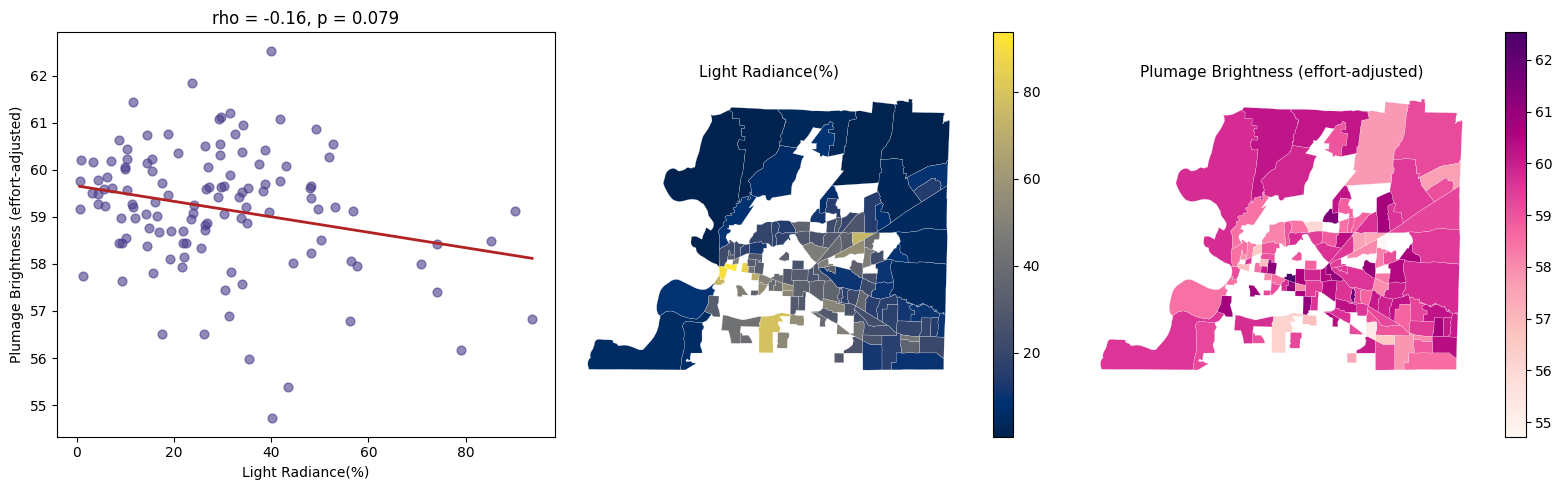

In [ ]:
#plumage and light pollution

# Example: canopy cover vs effort-adjusted diversity
_ = single_variable_analysis(
    gdf, predictor_col='light_radiance', response_col='mean_brightness',
    predictor_label='Light Radiance(%)', response_label="Plumage Brightness (effort-adjusted)",
    predictor_cmap='cividis', response_cmap='RdPu'
)

Heat Intensity(%) vs Plumage Brightness (effort-adjusted)
  Spearman rho = -0.068, p = 0.5241, n = 91 tracts
  --> No significant relationship at n = 91 tracts


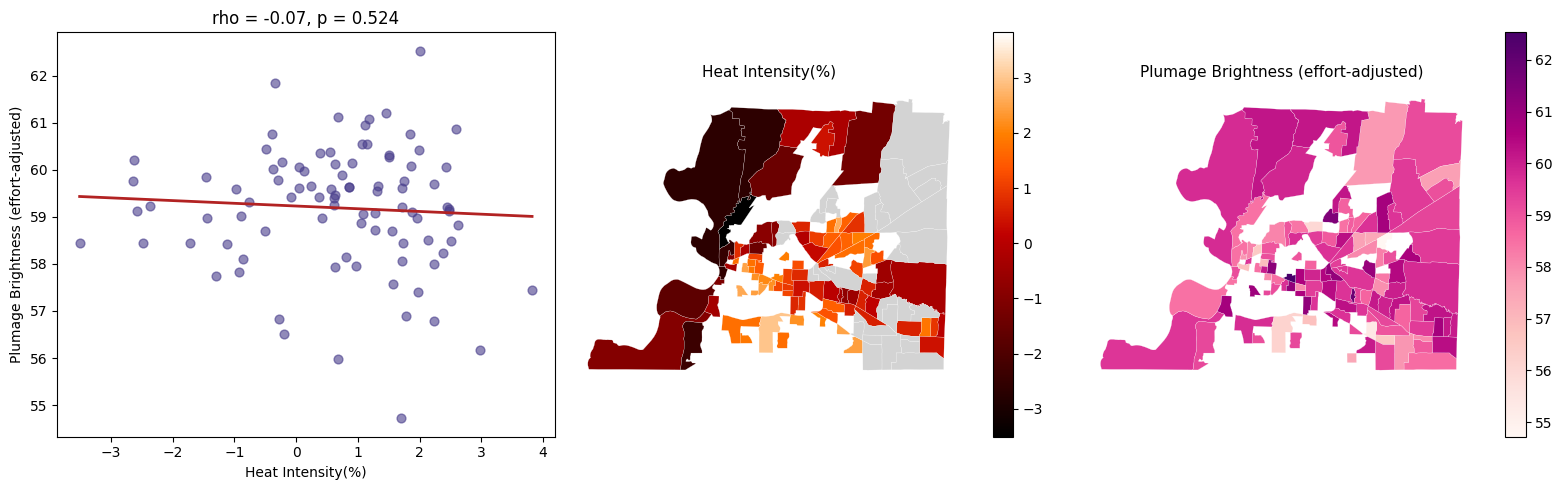

In [ ]:
#Heat intensity and Plumage Brightness

# Example: canopy cover vs effort-adjusted diversity
_ = single_variable_analysis(
    gdf, predictor_col='heat_intensity', response_col='mean_brightness',
    predictor_label='Heat Intensity(%)', response_label="Plumage Brightness (effort-adjusted)",
    predictor_cmap='gist_heat', response_cmap='RdPu'
)


Tree canopy cover (%) vs Plumage Brightness (effort-adjusted)
  Spearman rho = 0.427, p = 0.0000, n = 122 tracts
  --> Plumage Brightness (effort-adjusted) significantly increases with Tree canopy cover (%)


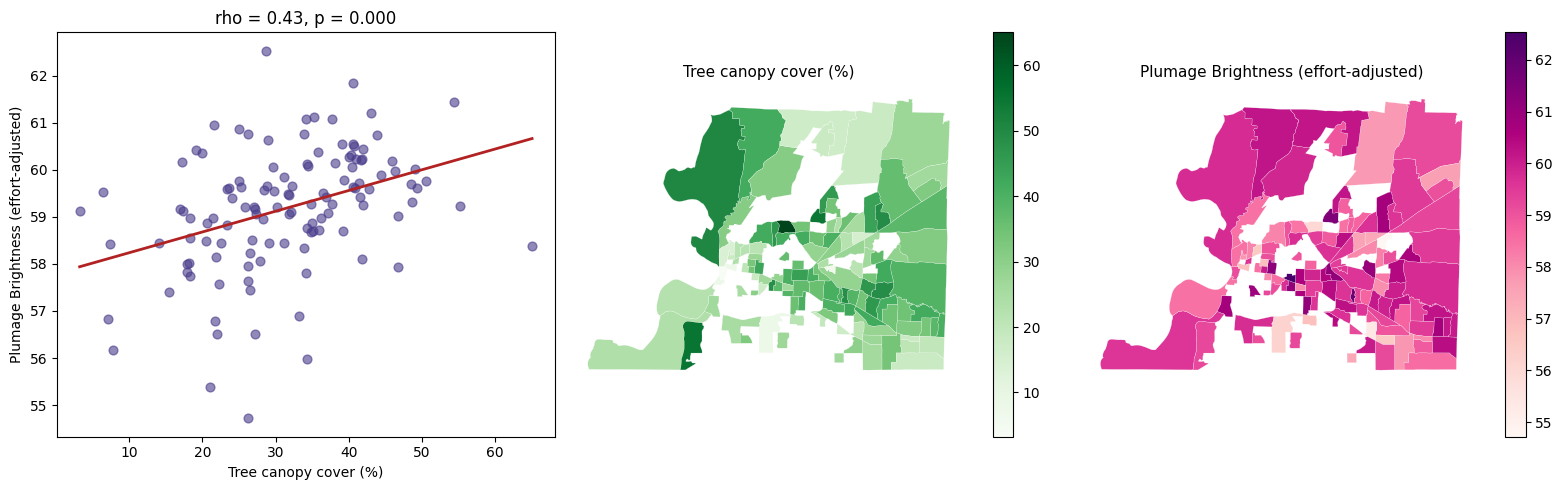

In [ ]:
# Example: canopy cover vs plumage brightness
_ = single_variable_analysis(
    gdf, predictor_col='canopy_pct', response_col='mean_brightness',
    predictor_label='Tree canopy cover (%)', response_label="Plumage Brightness (effort-adjusted)",
    predictor_cmap='Greens', response_cmap='RdPu'
)

Light Radiance(%) vs Plumage Brightness (effort-adjusted)
  Spearman rho = -0.160, p = 0.0790, n = 122 tracts
  --> No significant relationship at n = 122 tracts


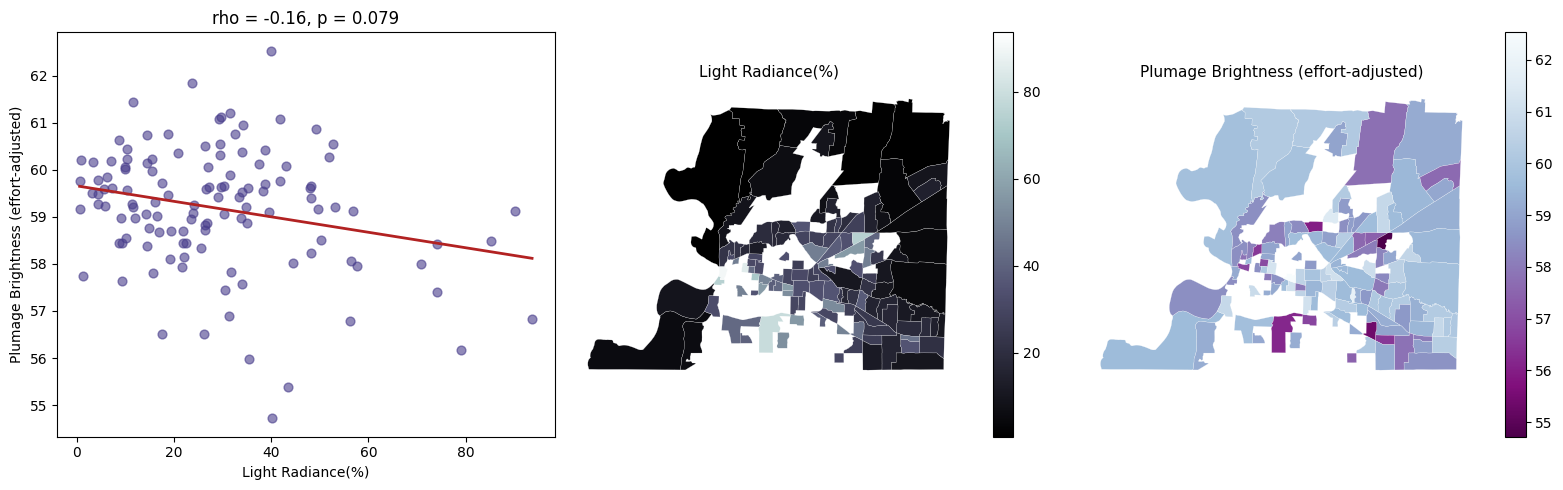

In [ ]:
#Light intensity and Plumage Brightness

_ = single_variable_analysis(
    gdf, predictor_col='light_radiance', response_col='mean_brightness',
    predictor_label='Light Radiance(%)', response_label="Plumage Brightness (effort-adjusted)",
    predictor_cmap='bone', response_cmap='BuPu_r'
)


---------------------------


Heat Intensity(%) vs Shannon diversity (effort-adjusted)
  Spearman rho = -0.111, p = 0.2949, n = 91 tracts
  --> No significant relationship at n = 91 tracts


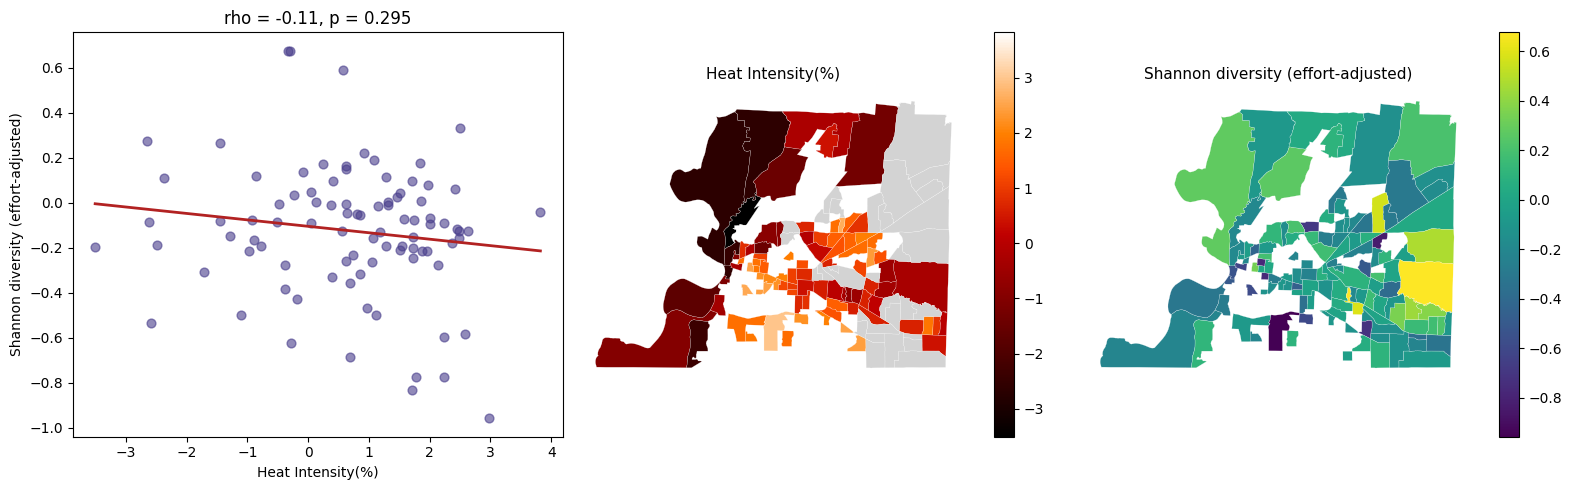

In [ ]:
#Heat intensity and Shannon Diversity

# Example: canopy cover vs effort-adjusted diversity
_ = single_variable_analysis(
    gdf, predictor_col='heat_intensity', response_col='diversity_effort_adj',
    predictor_label='Heat Intensity(%)', response_label="Shannon diversity (effort-adjusted)",
    predictor_cmap='gist_heat', response_cmap='viridis'
)


Light Radiance(%) vs Shannon diversity (effort-adjusted)
  Spearman rho = -0.344, p = 0.0001, n = 122 tracts
  --> Shannon diversity (effort-adjusted) significantly decreases with Light Radiance(%)


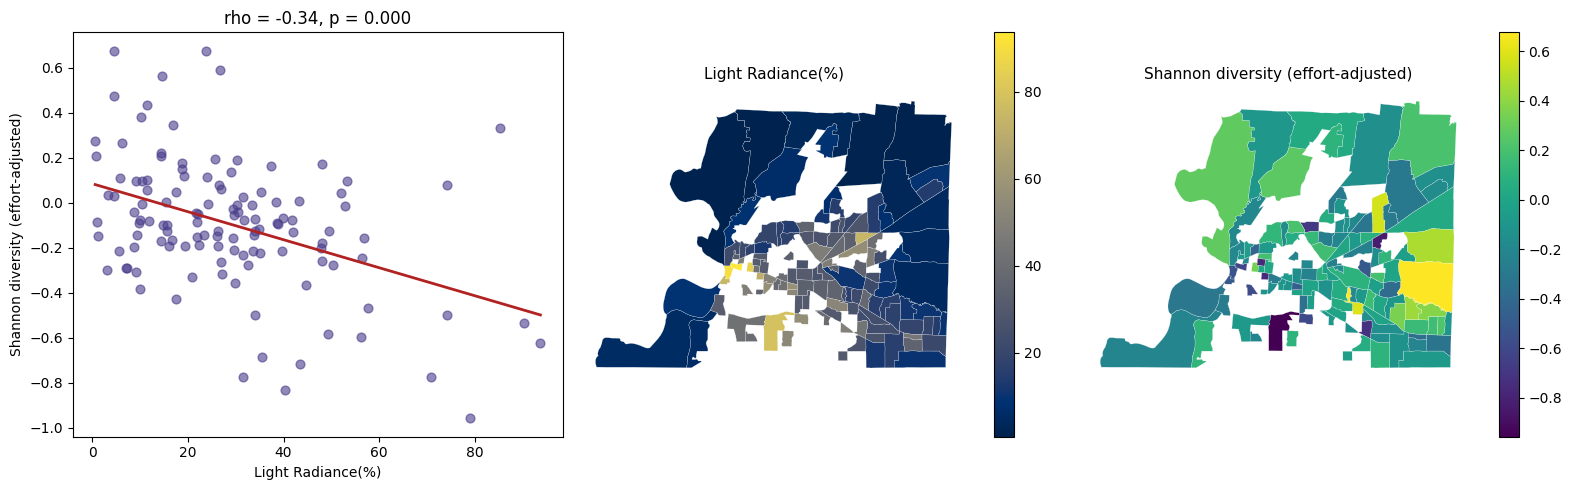

In [ ]:
#Light intensity and Shannon Diversity

_ = single_variable_analysis(
    gdf, predictor_col='light_radiance', response_col='diversity_effort_adj',
    predictor_label='Light Radiance(%)', response_label="Shannon diversity (effort-adjusted)",
    predictor_cmap='cividis', response_cmap='viridis'
)


Saved: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/memphis_full_model_data.geojson
Tree canopy cover (%) vs Shannon diversity (effort-adjusted)
  Spearman rho = 0.364, p = 0.0000, n = 122 tracts
  --> Shannon diversity (effort-adjusted) significantly increases with Tree canopy cover (%)


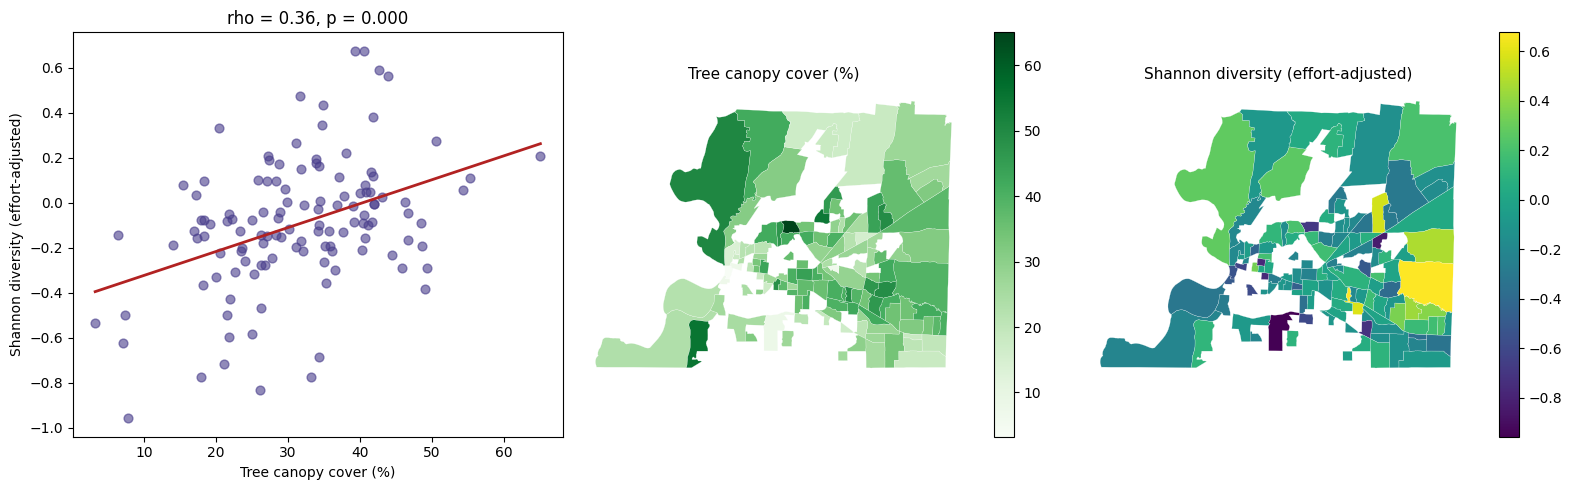

Saved: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/single_variable_analysis_memphis.png

Done. Everyone can now start from the IMPORT cell below --


<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# EXPORT -- run once after building gdf (end of Part 4) so you
# can reload everything next session without rerunning Parts 1-4.
# ============================================================

# 1) Save the full tract-level dataset: geometry + all predictors/responses
GDF_OUTPUT_PATH = OUTPUT_DIR + f'{CITY_CODE}_full_model_data.geojson'
gdf.to_file(GDF_OUTPUT_PATH, driver='GeoJSON')
print(f"Saved: {GDF_OUTPUT_PATH}")

# 2) Save a single-variable analysis figure. Change predictor_col/response_col
#    below to whichever pairing you want saved -- this re-draws and saves it
#    directly, so it doesn't depend on which plot happened to be on screen last.
SINGLE_VAR_FIG_PATH = OUTPUT_DIR + f'single_variable_analysis_{CITY_CODE}.png'
_ = single_variable_analysis(
    gdf, predictor_col='canopy_pct', response_col='diversity_effort_adj',
    predictor_label='Tree canopy cover (%)',
    response_label="Shannon diversity (effort-adjusted)",
    predictor_cmap='Greens', response_cmap='viridis'
)
plt.gcf().savefig(SINGLE_VAR_FIG_PATH, dpi=200, bbox_inches='tight')
print(f"Saved: {SINGLE_VAR_FIG_PATH}")

print("\nDone. Everyone can now start from the IMPORT cell below --")

In [ ]:
# IMPORT (this replaces Parts 1-4 entirely; run Part 0's config cell first so CITY_CODE/OUTPUT_DIR exist, then this):
# ============================================================
# IMPORT -- run this instead of Parts 1-4 to pick up where the
# export left off. Requires Part 0 (master config) to have run
# first, so CITY_CODE/OUTPUT_DIR are defined.
# ============================================================
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

GDF_OUTPUT_PATH = OUTPUT_DIR + f'{CITY_CODE}_full_model_data.geojson'
gdf = gpd.read_file(GDF_OUTPUT_PATH)

print(f"Loaded {len(gdf)} tracts from {GDF_OUTPUT_PATH}")
print("Columns available:", list(gdf.columns))

# Placeholder definitions for functions and variables expected from Part 5
# (These would ideally be in a separate 'Part 5 setup' cell if available)

def check_vif(df, predictors):
    """Placeholder for VIF calculation."""
    vif_data = pd.DataFrame()
    vif_data["predictor"] = predictors
    vif_data["VIF"] = [variance_inflation_factor(df[predictors].dropna().values, i) for i in range(len(predictors))]
    return vif_data

def fit_full_model(df, response, predictors):
    """Placeholder for full model fitting."""
    # Drop rows with NaN in any relevant column
    sub = df[[response] + predictors].dropna()
    if sub.empty:
        raise ValueError(f"No complete cases for response {response} and predictors {predictors}")

    # Standardize predictors
    z_cols = [p + '_z' for p in predictors]
    for p in predictors:
        sub[p + '_z'] = (sub[p] - sub[p].mean()) / sub[p].std()

    # Add constant for the intercept
    X = sm.add_constant(sub[z_cols])
    y = sub[response]

    model = sm.OLS(y, X).fit()
    return model, sub, z_cols

PREDICTOR_LABELS = {
    'heat_intensity': 'Heat Intensity (UHI)',
    'canopy_pct': 'Tree Canopy Cover (%)',
    'light_radiance': 'Light Pollution (VIIRS)',
    'total_vuln': 'Social Vulnerability (SVI)',
    'holc_score_weighted': 'HOLC Score'
}

RESPONSE_LABELS = {
    'diversity_effort_adj': 'Shannon Diversity (effort-adjusted)',
    'mean_brightness': 'Plumage Brightness',
    'mean_mass': 'Body Mass (CWM)'
}

# Here's code to run a multivariate model on all of the predictors (canopy, heat, and light) for each of the 2 responses you are asking about (brightness and diversity (corrected for sampling bias)) separately — reuses fit_full_model()/check_vif() from Part 5, so run this after Part 5's setup cell, not standalone.


Loaded 122 tracts from /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/memphis_full_model_data.geojson
Columns available: ['GEOID', 'diversity_effort_adj', 'diversity_raw', 'n_checklists', 'mean_mass', 'mean_brightness', 'heat_intensity', 'canopy_pct', 'total_vuln', 'light_radiance', 'holc_grade_dominant', 'geometry']


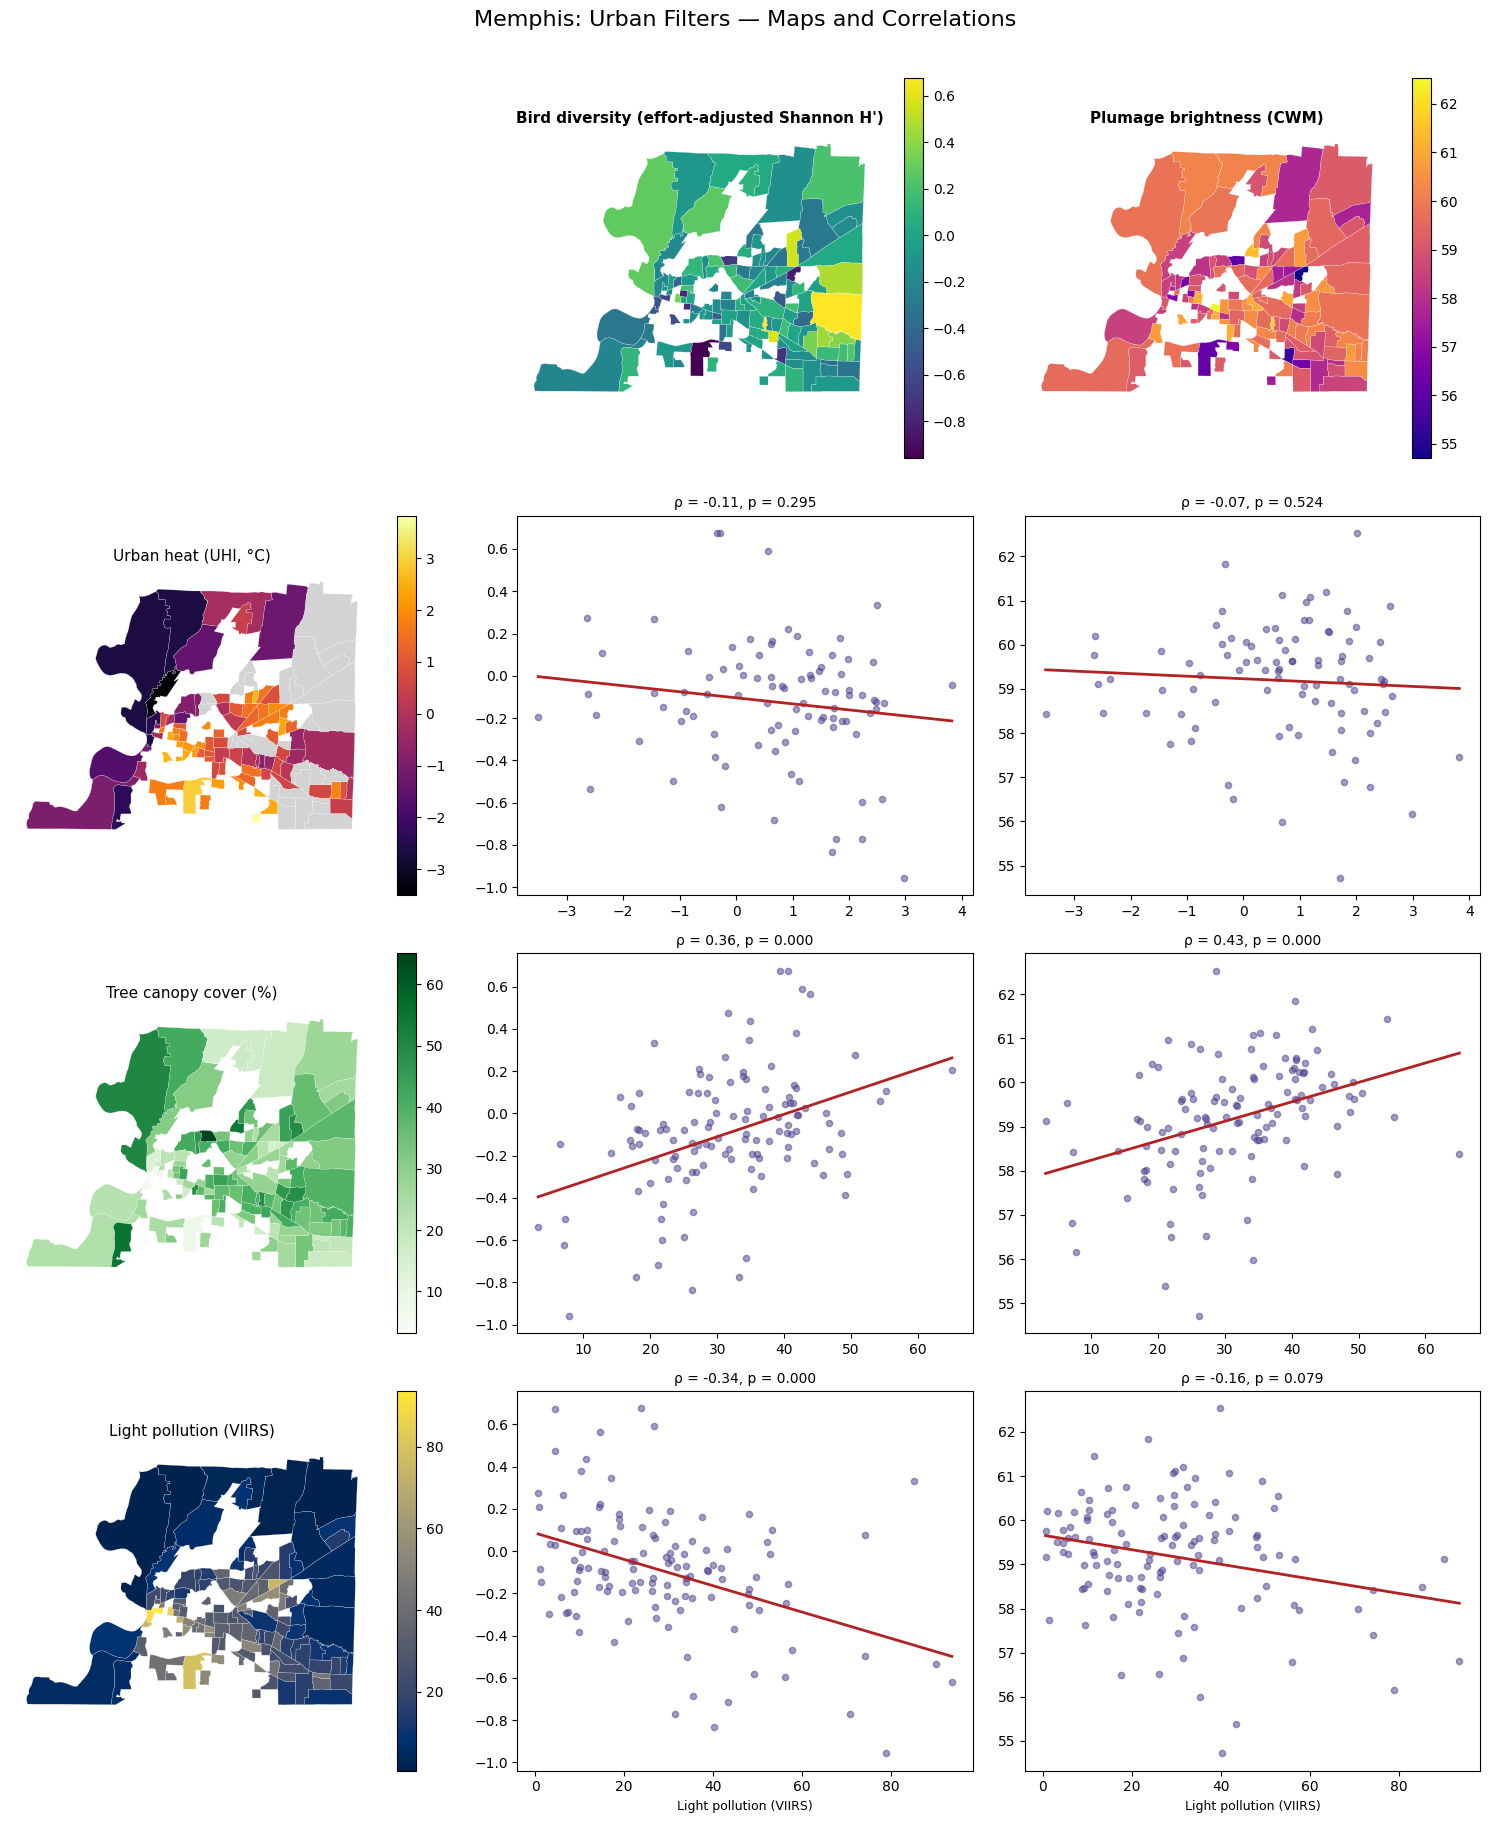

Saved: /content/drive/MyDrive/MainFolderMemphis/Memphis/OutputMemp/summary_grid_memphis.png


In [ ]:




fig, axes = plt.subplots(4, 3, figsize=(15, 18))

# --- Row 0: blank corner + the two response-variable maps ---
axes[0, 0].axis('off')

response_specs = [
    ('diversity_effort_adj', "Bird diversity (effort-adjusted Shannon H')", 'viridis'),
    ('mean_brightness',      'Plumage brightness (CWM)',                    'plasma'),
]
for col_idx, (resp_col, resp_label, resp_cmap) in enumerate(response_specs, start=1):
    ax = axes[0, col_idx]
    gdf.plot(column=resp_col, ax=ax, cmap=resp_cmap, edgecolor='white', linewidth=0.15,
              legend=True, missing_kwds={'color': 'lightgrey'})
    ax.set_title(resp_label, fontsize=11, fontweight='bold')
    ax.axis('off')

# --- Rows 1-3: predictor map, then scatter vs each response ---
predictor_specs = [
    ('heat_intensity', 'Urban heat (UHI, \u00b0C)',    'inferno'),
    ('canopy_pct',     'Tree canopy cover (%)',        'Greens'),
    ('light_radiance', 'Light pollution (VIIRS)',      'cividis'),
]

for row_idx, (pred_col, pred_label, pred_cmap) in enumerate(predictor_specs, start=1):
    # Column 0: predictor map
    ax_map = axes[row_idx, 0]
    gdf.plot(column=pred_col, ax=ax_map, cmap=pred_cmap, edgecolor='white', linewidth=0.15,
              legend=True, missing_kwds={'color': 'lightgrey'})
    ax_map.set_title(pred_label, fontsize=11)
    ax_map.axis('off')

    # Columns 1-2: scatter vs each response
    for col_idx, (resp_col, resp_label, _) in enumerate(response_specs, start=1):
        ax = axes[row_idx, col_idx]
        sub = gdf[[pred_col, resp_col]].dropna()
        ax.scatter(sub[pred_col], sub[resp_col], alpha=0.5, s=20, color='darkslateblue')
        if len(sub) > 2:
            z = np.polyfit(sub[pred_col], sub[resp_col], 1)
            x_line = np.linspace(sub[pred_col].min(), sub[pred_col].max(), 50)
            ax.plot(x_line, np.poly1d(z)(x_line), color='firebrick', linewidth=2)
            rho, p = stats.spearmanr(sub[pred_col], sub[resp_col])
            ax.set_title(f'\u03c1 = {rho:.2f}, p = {p:.3f}', fontsize=10)
        if row_idx == 3:
            ax.set_xlabel(pred_label, fontsize=9)

fig.suptitle(f'{CITY_NAME}: Urban Filters \u2014 Maps and Correlations', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + f'summary_grid_{CITY_CODE}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}summary_grid_{CITY_CODE}.png")


In [ ]:

# ============================================================
# Reduced 3-predictor models: canopy + heat + light pollution
# Response 1: diversity   Response 2: brightness
# Same discipline as Part 5 -- one model per response, all three
# predictors together, decided before looking at any result.
# Requires: fit_full_model(), check_vif(), PREDICTOR_LABELS,
# RESPONSE_LABELS from Part 5's setup cell to already be defined.
# ============================================================

PREDICTORS_3 = ['heat_intensity', 'canopy_pct', 'light_radiance']
RESPONSES_3  = ['diversity_effort_adj', 'mean_brightness']

PREDICTORS_3 = [p for p in PREDICTORS_3 if p in gdf.columns]
RESPONSES_3  = [r for r in RESPONSES_3  if r in gdf.columns]

print(f"=== {CITY_NAME}: 3-predictor models (canopy + heat + light) ===\n")

# VIF for THIS predictor set specifically -- collinearity can shift when
# you drop predictors, so don't assume Part 5's 5-predictor VIF still applies
vif_3 = check_vif(gdf, PREDICTORS_3)
vif_3['label'] = vif_3['predictor'].map(PREDICTOR_LABELS)
print("VIF:")
print(vif_3[['label', 'VIF']].to_string(index=False))
print()

results_3 = {}
rows = []  # tidy rows, one per predictor per response -- for combining across cities later

for response in RESPONSES_3:
    model, sub, z_cols = fit_full_model(gdf, response, PREDICTORS_3)
    results_3[response] = model

    print(f"{'='*70}")
    print(f"{RESPONSE_LABELS.get(response, response)}  (n = {len(sub)} tracts)")
    print('='*70)
    coef_table = model.summary2().tables[1].round(4)
    coef_table.index = ['Intercept'] + [PREDICTOR_LABELS[p] for p in PREDICTORS_3]
    print(coef_table[['Coef.', 'Std.Err.', 'P>|t|']])
    print(f"R\u00b2 = {model.rsquared:.3f}  (adj. R\u00b2 = {model.rsquared_adj:.3f})\n")

    for p in PREDICTORS_3:
        rows.append({
            'city': CITY_NAME, 'response': response, 'predictor': p,
            'coef': model.params[p + '_z'], 'se': model.bse[p + '_z'],
            'p': model.pvalues[p + '_z'], 'n': len(sub), 'r2': model.rsquared,
        })

model_results_3 = pd.DataFrame(rows)
print(model_results_3.round(4))

# Save -- this tidy format is what makes combining results across every
# student's city into one shared table (mentioned back in Part 4) easy:
# just concatenate everyone's CSV and group by predictor/response.
RESULTS_3_PATH = OUTPUT_DIR + f'model_results_3pred_{CITY_CODE}.csv'
model_results_3.to_csv(RESULTS_3_PATH, index=False)
print(f"\nSaved: {RESULTS_3_PATH}")


=== Memphis: 3-predictor models (canopy + heat + light) ===

VIF:
                  label      VIF
   Heat Intensity (UHI) 1.513815
  Tree Canopy Cover (%) 2.064178
Light Pollution (VIIRS) 2.693741

Shannon Diversity (effort-adjusted)  (n = 91 tracts)
                          Coef.  Std.Err.   P>|t|
Intercept               -0.1238    0.0276  0.0000
Heat Intensity (UHI)     0.0009    0.0314  0.9769
Tree Canopy Cover (%)    0.0850    0.0329  0.0115
Light Pollution (VIIRS) -0.0680    0.0366  0.0664
R² = 0.210  (adj. R² = 0.183)

Plumage Brightness  (n = 91 tracts)
                           Coef.  Std.Err.   P>|t|
Intercept                59.1915    0.1291  0.0000
Heat Intensity (UHI)      0.0278    0.1469  0.8504
Tree Canopy Cover (%)     0.4275    0.1539  0.0067
Light Pollution (VIIRS)  -0.1165    0.1709  0.4974
R² = 0.142  (adj. R² = 0.113)

      city              response       predictor    coef      se       p   n  \
0  Memphis  diversity_effort_adj  heat_intensity  0.0009  0.0314 